# Title: Hidden in Plain Sight: Dog Whistle Detection, Classification, and Explanation
Group ID: 01

Dog whistles are coded expressions that carry one meaning for the general public and a hidden meaning for a specific in-group. Standard toxicity detectors tend to miss them because they sound innocent on the surface. This project asks whether NLP models can detect when a term is being used as a dog whistle vs. literally, classify which in-group is being targeted, and generate structured explanations of the covert meaning.

We use the informal (Reddit) portion of SALT-NLP/silent_signals (Kruk et al., ACL 2024), containing 12,923 labelled examples, 298 canonical dog-whistle root terms (706 surface forms), and 18 in-group categories (17 in the train-only label space used by RQ-B).

We ship three tasks:
- **(A)** a RoBERTa-base binary classifier detecting dog whistle vs. literal use, evaluated on a 124-row human-gold disambiguation set;
- **(B)** a RoBERTa-base 17-way in-group classifier whose central finding is the **64-pp macro-F1 gap** between the root-stratified split (Run A: macro-F1 = 0.353 ± 0.007) and the ingroup-stratified alt split (Run C: 0.996) — evidence that the underlying glossary is term-deterministic and that any RQ-B-style result without root-holdout is measuring the glossary, not the model;
- **(C)** a Flan-T5-XL + LoRA generator producing structured-JSON explanations (`dog_whistle_root`, `ingroup`, `definition`, `explanation`), evaluated on the same root-held-out test set.

All headline runs are 3-seed sweeps {42, 123, 7} with mean ± std reported. Per-RQ writeups in `docs/rq_a_report.md`, `docs/rq_b_report.md`, `docs/rq_c_report.md`. Topic-modelling and explanation-augmented-classification cells (formerly RQ-D and RQ-E) remain in the notebook as exploratory / supplementary; they are **not** headline findings.


## How to read this notebook

This notebook is the canonical source for the project. It plays two roles:

1. **HPC-script generator.** The `%%writefile hpc_scripts/...` cells below export the SLURM training scripts, configs, and helper modules to `hpc_scripts/` (on HPC) or `scripts/hpc/` (locally). All headline numbers reported in this notebook were produced by jobs submitted on Bocconi HPC using these exported scripts.
2. **Analysis layer.** Baselines (§ 5b, 6b, 7.3), error analysis (§ 5c, 7.5), and the unified report (§ 8) run locally on per-row predictions parquets pulled back from HPC.

### To reproduce a training run

1. Execute the relevant `%%writefile` cells (e.g. cells 32–37 for RQ-A) to materialise the scripts under `hpc_scripts/`.
2. `scp` the directory to `~/dogwhistle_project/hpc_scripts/` on HPC.
3. Submit via `sbatch hpc_scripts/submit_<task>.sh`.
4. `scp` results back to `results/` on the laptop.
5. Re-run the analysis cells (§ 5b/c, 6b, 7.3–7.7, 8).

### Headline numbers (full discussion in `docs/`)

| RQ | Headline | Report |
|---|---|---|
| RQ-A binary disambiguator | F1 = 0.707 ± 0.015 on locked disambiguation set | `docs/rq_a_report.md` |
| RQ-B multiclass ingroup | macro-F1 = 0.353 ± 0.007 on grouped split (Run A); 0.996 on alt split (Run C — memorisation arm) | `docs/rq_b_report.md` |
| RQ-C structured generator | Path A ingroup macro-F1 = 0.379 ± 0.014 | `docs/rq_c_report.md` |

### Models actually trained

- **RQ-A and RQ-B**: `FacebookAI/roberta-base` (125 M params). We initially attempted `microsoft/deberta-v3-large` (435 M params) but hit numerical instability across 5 hyperparameter configurations and swapped. Post-mortem: `docs/sessions/2026-04-29_rqa_nan_postmortem.md` and § B.7 of `docs/rq_a_report.md`.
- **RQ-C**: `google/flan-t5-xl` (3 B params) with LoRA adapters (r = 16, α = 32, dropout = 0.1, target modules q + v).

### Locked human-gold eval files

`data/final/rq_a_binary/eval_detection.parquet` (101 rows) and `eval_disambiguation.parquet` (124 rows) are touched **only** by `model.evaluate()`. They are never tokenised into a Trainer's input pipeline and never concatenated into a training dataset (`DESIGN_DEFENSE.md` D7).


# Silent Signals Pipeline

End-to-end dog whistle detection, classification, and explanation.

- **Core dataset**: `SALT-NLP/silent_signals` — **informal (Reddit) subset only** (~12,900 examples, 298 roots, 706 surface forms, 18 ingroup categories — 17 in the RQ-B train-only label space)
- **Reference**: Allen AI dog whistle glossary (Mendelsohn et al., 2023)
- **Task A**: Binary disambiguation — coded dog whistle vs. literal use (RoBERTa-base, two arms `term` and `term_enriched_def`)
- **Task B**: 17-class ingroup classification — which community is targeted (RoBERTa-base, four runs: A grouped, B text-only, C alt-split, D weighted-CE)
- **Task C**: Structured-JSON generation — root, ingroup, definition, explanation (Flan-T5-XL + LoRA, two paths: A unbalanced, B class-balanced)
- **Supplementary**: Topic modelling of dog whistle clusters and explanation-augmented classification (sections 4b and 7.6) are kept as exploratory; they are not in the headline reports.
- **Key design**: Grouped splits by `dog_whistle_root` (no leakage), silver negatives mined from informal candidate pool only and adjudicated by Llama-3.1-8B-Instruct (62.11 % contamination flagged + dropped).
- **This notebook**: Runs locally on a small sample as a smoke test. Section 9 exports standalone HPC scripts via `%%writefile`.

**Important**: We filter `silent_signals` to `type == "Informal"` to focus on Reddit data only. The candidate pool negatives are silver-labelled (Llama-3.1-8B as judge); see `docs/negative_report.md` for the full mining methodology and Section 3 for the noisy-negative caveat.


## Research Questions & Hypotheses

This project tests specific, narrowly-scoped claims about dog whistle detection. Each task has a research question, a hypothesis (what we expect to see), and the comparison or baseline that lets us check whether the hypothesis holds. Numbers shown here are the actual headline results — see the per-RQ reports under `docs/` for the full discussion.

### RQ-A — Binary Detection

**Question:** Can a fine-tuned LM distinguish coded from literal uses of the same term in Reddit text, and does adding the term's curated coded-meaning definition at inference time actually help?

**Hypothesis:** Providing the term and its enriched definition alongside the post (`term + definition_enriched + content`) should outperform giving only the term and content (`term + content`), because disambiguation often needs knowledge of what the term *signals*, not just what it means.

**How we check this — two input arms, same model, same test sets, three seeds each:**
- `term` arm — `Candidate term: <dw>\nText: <content>\nQuestion: …`
- `term_enriched_def` arm — `Candidate term: <dw>\nCandidate meaning: <definition_enriched>\nText: <content>\nQuestion: …`

The enriched definition is sourced from the Allen AI dog-whistle glossary (`resources/dog_whistle_roots_enriched.csv`), pre-joined into `data/final/rq_a_binary/*.parquet` as the `definition_enriched` column. Headline result: F1 = 0.707 ± 0.015 (term arm) vs 0.702 ± 0.021 (enriched-def arm) on the locked 124-row disambiguation set — within seed noise, so the curated glossary is not required at inference (a positive deployment-robustness finding). See `docs/rq_a_report.md` for the full discussion of why F1 sits at the prevalence floor and the lift surfaces in accuracy + PR-AUC.

### RQ-B — Multiclass Ingroup Classification

**Question:** Given a confirmed dog whistle, which of the 17 ingroup categories (train-only label space) is the speaker signalling to, and where does the classifier systematically fail?

**Hypothesis:** The 17 ingroups are heavily imbalanced and the test set has substantial prior shift on `anti-liberal` (5.8 % train → 34 % test); we expect macro-F1 to lag weighted-F1 substantially. Errors should concentrate on ideologically adjacent categories rather than being spread uniformly.

**Baselines and ablations:**
- **Majority class** — predict the most-frequent train ingroup (`racist`).
- **Frequency-weighted random** — sample from the empirical train ingroup distribution (seeded).
- **Run B — text-only ablation** (drop the matched-term cue from the input). Tests whether the model leans on term identity vs context. macro-F1 = 0.314.
- **Run C — alt-split sensitivity check** (random comment-level split, ingroup-stratified, no root holdout). macro-F1 = **0.996**. Demonstrates that without root-holdout the task collapses to a glossary lookup.
- **Run D — class-weighted CE loss** (loss-side intervention against prior shift). macro-F1 = 0.335 — does not help.

**Headline:** Run A (term, grouped split, 3 seeds) macro-F1 = 0.353 ± 0.007. The 64-pp gap between Run A and Run C is the central finding — see `docs/rq_b_report.md` § 4.1.

### RQ-C — Structured Explanation Generation

**Question:** Can a fine-tuned seq2seq model (Flan-T5-XL + LoRA) produce structured JSON outputs — `dog_whistle_root`, `ingroup`, `definition`, `explanation` — that match the gold annotations?

**Hypothesis:** Structured JSON output makes evaluation clean: categorical fields (`ingroup`, `dog_whistle_root`, `definition`) score with exact match + macro-F1; the free-form `explanation` is evaluated by TF-IDF cosine similarity (course-inventory level L5) plus per-row ROUGE-L as a secondary metric. Under the grouped split, root and definition are structurally non-recoverable on held-out test roots; the meaningful generalisation question lives at the `ingroup` level.

**Baselines:** template fill-in (most-common (root, ingroup, definition) for the matched dog_whistle in train) and TF-IDF 1-NN retrieval (copy the nearest train row's target_json verbatim). A useful generator should beat both.

**Two paths trained, same model, different train-set composition:**
- **Path A — unbalanced.** Train at the natural ingroup distribution. Headline: ingroup macro-F1 = 0.379 ± 0.014. **Recommended deployment system.**
- **Path B — class-balanced.** Train oversampled to 1,500 rows per ingroup × 17 ingroups = 25,500 rows. Accuracy +12 pp over A, but macro-F1 unchanged (+0.004) and seed variance ×4.5 — class-prior reweighting, not learned generalisation. See `docs/rq_c_report.md` § 5.1.

### Supplementary (exploratory, not headline)

- **Topic modelling.** Section 4b explores LDA + NMF over per-root TF-IDF; an analogous t-SNE / NMI clustering analysis appears in `notebooks/eda.ipynb` Section 10. Findings are descriptive only; no conclusions feed the per-RQ reports.
- **Explanation-augmented classification.** Section 7.6 narrates an experiment to prepend RQ-C's generated explanation onto RQ-B's input and check whether it changes RQ-B macro-F1. The cell is preserved as scoped-but-not-executed; it is **not** in the headline reports. See § 7.6 for the abandoned framing.

### Caveat: what counts as a dog whistle?

The SALT-NLP vocabulary mixes genuinely coded terms (e.g. `(((echoes))`) with overtly pejorative in-group slang most readers would recognise as hostile (e.g. `SJW`, `libtard`). Aggregate F1 on Task A may be dominated by the easy overt cases rather than the hard covert ones. To surface this, we report **per-term F1** in §5c alongside the aggregate so we can tell whether the model is solving the hard cases or just the easy ones. We keep all SALT-NLP terms as-is rather than filter, since filtering would invalidate comparison against the benchmark.

### Scope and limits

- **Reddit only.** All training data is Reddit. We don't claim findings transfer to Twitter, Telegram, formal political speech, or other languages.
- **3-seed sweep on headline runs.** RQ-A 6 trained models (2 arms × 3 seeds), RQ-B Run A 3 seeds, RQ-C Path A 3 seeds + Path B 3 seeds. Reported as mean ± std. Sensitivity-check runs (RQ-B Run B / C / D, RQ-C Path B) are single-seed where noted.
- **Data statement.** A short Bender & Friedman (2018) data statement appears in §1b of this notebook and in `docs/final_report_mockup.md` §3.5.


## Section 0: Setup & Utilities

This section loads all dependencies and defines shared utility functions used throughout the notebook:
- **`set_seed()`**: Deterministic seeding across random, numpy, and torch for reproducibility
- **`sanitize_text_column()`**: Cleans text columns by dropping nulls, coercing to string, stripping whitespace
- **`content_hash()` / `deduplicate_df()` / `get_content_hashes()`**: SHA-256 content hashing for deduplication and exclusion sets
- **`resolve_bf16()`**: Gates BF16 on `torch.cuda.is_bf16_supported()`, not just CUDA availability (DeBERTa-v3 is unstable in mixed precision)

`SAMPLE_SIZE = 1000` controls the local smoke test size. Set to `0` for a full-data run.

In [ ]:
import os, sys, json, hashlib, random, gc, time, warnings
from datetime import datetime
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset as HFDataset
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    precision_recall_fscore_support, accuracy_score,
    average_precision_score, classification_report,
    confusion_matrix, f1_score,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM, TrainingArguments, Seq2SeqTrainingArguments,
    Trainer, Seq2SeqTrainer, DataCollatorWithPadding, DataCollatorForSeq2Seq,
    EarlyStoppingCallback, pipeline as hf_pipeline,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import evaluate as hf_evaluate

# Optional: SHAP for the explainability section (Section 8.5).
# `pip install shap` — only needed when running that section.
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

warnings.filterwarnings('ignore', category=FutureWarning)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# --- Constants ---
SAMPLE_SIZE = 500   # rows per split for local smoke test; set 0 for full
SEED = 42

# Anchor paths to the repo root so the notebook works regardless of CWD,
# and pick the right canonical-data layout (local 'data/final/' vs HPC 'final_data/').
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
# Make `scripts/hpc/utils.py` importable as `from utils import ...` regardless of CWD
_utils_dir = str(REPO_ROOT / 'scripts' / 'hpc')
if _utils_dir not in sys.path:
    sys.path.insert(0, _utils_dir)
DATA_DIR = str(REPO_ROOT / 'data')
_local_final = REPO_ROOT / 'data' / 'final'
_hpc_final   = REPO_ROOT / 'final_data'
if _local_final.exists():
    FINAL_DATA_DIR = str(_local_final)
elif _hpc_final.exists():
    FINAL_DATA_DIR = str(_hpc_final)
else:
    FINAL_DATA_DIR = str(_local_final)  # default; will fail loudly downstream if missing
RESULTS_DIR = str(REPO_ROOT / 'results' / 'local')

for d in [f'{DATA_DIR}/manifests', f'{DATA_DIR}/processed', f'{DATA_DIR}/splits',
          RESULTS_DIR, str(REPO_ROOT / 'scripts' / 'hpc' / 'configs')]:
    os.makedirs(d, exist_ok=True)

print(f'REPO_ROOT:       {REPO_ROOT}')
print(f'DATA_DIR:        {DATA_DIR}')
print(f'FINAL_DATA_DIR:  {FINAL_DATA_DIR}')
print(f'Sample size: {SAMPLE_SIZE}')
print(f'Seed: {SEED}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"}')
print(f'SHAP available: {SHAP_AVAILABLE} (Section 8.5 will skip gracefully if False)')


In [27]:
# --- Utility functions ---

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def print_diagnostics():
    print(f'Python: {sys.version.split()[0]}')
    print(f'PyTorch: {torch.__version__}')
    print(f'CUDA available: {torch.cuda.is_available()}')
    if torch.cuda.is_available():
        print(f'GPU: {torch.cuda.get_device_name(0)}')
        print(f'GPU memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB')
        print(f'BF16 supported: {torch.cuda.is_bf16_supported()}')
    elif torch.backends.mps.is_available():
        print('MPS (Apple Silicon) available')
    print(f'CPU cores: {os.cpu_count()}')

def sanitize_text_column(df, col):
    before = len(df)
    df = df.dropna(subset=[col]).copy()
    df[col] = df[col].astype(str).str.strip()
    df = df[df[col].str.len() > 0].reset_index(drop=True)
    dropped = before - len(df)
    if dropped > 0:
        print(f"  sanitize '{col}': dropped {dropped:,} rows ({dropped/before*100:.1f}%)")
    return df

def content_hash(text):
    normalized = ' '.join(str(text).lower().strip().split())
    return hashlib.sha256(normalized.encode()).hexdigest()

def deduplicate_df(df, text_col='content'):
    df = df.copy()
    df['_hash'] = df[text_col].apply(content_hash)
    before = len(df)
    df = df.drop_duplicates(subset='_hash', keep='first').drop(columns='_hash')
    print(f'  Dedup: {before:,} -> {len(df):,} (removed {before - len(df):,})')
    return df.reset_index(drop=True)

def get_content_hashes(df, text_col='content'):
    return set(df[text_col].apply(content_hash))

def resolve_bf16():
    if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
        return True
    return False

def get_device_str():
    if torch.cuda.is_available():
        return 'cuda'
    elif torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'

set_seed(SEED)
print_diagnostics()

Python: 3.11.14
PyTorch: 2.10.0
CUDA available: False
MPS (Apple Silicon) available
CPU cores: 8


## Section 1: Inspect & Filter Dataset

Load the Silent Signals collection from HuggingFace and **filter to the informal (Reddit) subset**.

| Dataset | Rows | Role |
|---------|-----:|------|
| `silent_signals` | ~16,258 total → **~12,900 informal** | Core supervised training data (filtered) |
| `silent_signals_detection` | 101 | Locked eval — coded vs non-coded detection |
| `silent_signals_disambiguation` | 124 | Locked eval — same-term disambiguation |
| `informal_potential_dogwhistles` | 6.03M | Candidate pool for mining silver negatives (Reddit) |

We drop the formal subset entirely to focus on Reddit discourse, matching the proposal scope.
The `df_ss` DataFrame after filtering is the basis for all downstream tasks.

In [ ]:
def profile_dataset(name, df, max_unique=20):
    print(f'\n{"="*60}')
    print(f'{name}: {len(df):,} rows, {len(df.columns)} columns')
    print(f'{"="*60}')
    for col in df.columns:
        n_null = df[col].isnull().sum()
        n_unique = df[col].nunique()
        dtype = str(df[col].dtype)
        info = f'  {col:25s} | {dtype:10s} | {n_unique:>6} unique | {n_null:>5} null'
        if n_unique <= max_unique and n_unique > 0:
            vals = df[col].value_counts().head(max_unique)
            info += f' | top: {dict(vals.head(5))}'
        print(info)

# --- Load core supervised dataset ---
print('Loading silent_signals...')
ds_ss = load_dataset('SALT-NLP/silent_signals', split='train')
df_ss_all = ds_ss.to_pandas()
profile_dataset('silent_signals (all)', df_ss_all)

# --- Filter to informal (Reddit) subset only ---
print(f'\nFiltering to informal (Reddit) subset...')
type_counts = df_ss_all['type'].value_counts()
print(f'  Type distribution before filter: {dict(type_counts)}')
df_ss = df_ss_all[df_ss_all['type'] == 'Informal'].reset_index(drop=True)
print(f'  After filter: {len(df_ss):,} rows (dropped {len(df_ss_all) - len(df_ss):,} formal rows)')
profile_dataset('silent_signals (informal only)', df_ss)

# Free df_ss_all immediately — only df_ss is needed downstream, and holding the
# full set increases the chance of an OOM kernel crash during the streaming step below.
n_ss_all = len(df_ss_all)
del df_ss_all
gc.collect()

# --- Load locked eval sets ---
print('\nLoading detection set...')
ds_det = load_dataset('SALT-NLP/silent_signals_detection', split='train')
df_det = ds_det.to_pandas()
profile_dataset('silent_signals_detection', df_det)

print('\nLoading disambiguation set...')
ds_dis = load_dataset('SALT-NLP/silent_signals_disambiguation', split='train')
df_dis = ds_dis.to_pandas()
profile_dataset('silent_signals_disambiguation', df_dis)

# --- Stream-profile informal candidate pool ---
# `streaming=True` avoids materialising 6M rows; we only need 1000 for column-schema profiling.
print('\nProfiling informal_potential_dogwhistles (streaming first 1000)...')
ds_inf = load_dataset('SALT-NLP/informal_potential_dogwhistles', split='train', streaming=True)
rows_inf = [r for r, _ in zip(ds_inf, range(1000))]
df_inf_sample = pd.DataFrame(rows_inf)
profile_dataset('informal_potential_dogwhistles (sample)', df_inf_sample)

# --- Summary ---
print(f'\n--- informal subset: ingroup distribution ---')
print(df_ss['ingroup'].value_counts())
print(f'\nUnique dog_whistle_root: {df_ss["dog_whistle_root"].nunique()}')
print(f'Unique dog_whistle: {df_ss["dog_whistle"].nunique()}')

# Save profiles
profiles = {
    'silent_signals_all': {'rows': n_ss_all, 'types': type_counts.to_dict()},
    'silent_signals_informal': {'rows': len(df_ss), 'columns': list(df_ss.columns),
                                'ingroups': df_ss['ingroup'].value_counts().to_dict()},
    'detection': {'rows': len(df_det), 'columns': list(df_det.columns)},
    'disambiguation': {'rows': len(df_dis), 'columns': list(df_dis.columns)},
    'informal_potential': {'columns': list(df_inf_sample.columns), 'note': '6.03M rows (sampled 1000)'},
}
with open(f'{DATA_DIR}/manifests/dataset_profiles.json', 'w') as f:
    json.dump(profiles, f, indent=2)
print(f'\nSaved dataset profiles to {DATA_DIR}/manifests/dataset_profiles.json')

del rows_inf, df_inf_sample; gc.collect()


## Section 1b: Abbreviated Data Statement (Bender & Friedman 2018)

A data statement characterises the dataset so readers can assess generalisability and bias. Full schema is in `nlp-research-methods.md`; this is the short form.

- **A. Curation rationale.** `silent_signals` was built by keyword search over ~1000 surface forms drawn from the Allen AI Glossary (340 dog whistles), yielding ~7M candidate matches. The final disambiguated dataset covers 298 dog whistles / 706 surface forms across 18 in-groups. 100k were sampled and disambiguated by GPT-4 (ensemble of 3 inferences). We use only the informal (Reddit) split — findings generalise to English-language Reddit discourse, **not** to formal political speech, other platforms, or non-English speakers.
- **B. Language variety.** `en-US`, predominantly informal social-media register. High lexical variability (slang, abbreviations, neologisms). No non-English data.
- **C. Speaker demographic.** Reddit users (2005-2022), skewed toward US demographics. Dog-whistle terminology is US-centric (Civil Rights era, US electoral politics, culture wars). No speaker-level metadata available.
- **D. Annotator demographic.** GPT-4 generated the labels — no human annotators. Manual validation of 400 rows showed **85.3% precision** → **~15% noise in positive labels** (see Threats to Validity at the end of the notebook). Two validators from SALT-NLP lab (Georgia Tech/Stanford); no demographics reported.
- **E. Speech situation.** Written, asynchronous, public social-media posts. Speakers did not consent to NLP research. Content targets racial, religious, gender, and political groups — annotator welfare is a consideration.
- **F. Text characteristics.** 10-18,300 characters. Forum discussion, political commentary, community organising. Topics: US politics, immigration, race, gender, religion, health policy.
- **G. Known biases.** Ingroup categories are heavily skewed (racist, white-supremacist, antisemitic, and transphobic categories dominate the informal split.). Low-frequency categories (anti-Asian, anti-LGBTQ, religious) may have insufficient training examples. The Allen AI glossary may under-represent non-mainstream coded language. Roughly 4% of validated positives used the term as a dog whistle but with a coded meaning different from the Allen AI definition (e.g. "terrorist" used as anti-liberal rather than Islamophobic), so the ingroup label itself carries noise beyond the coded/literal label.

Generalisation claim limit: results apply to **English Reddit discourse from 2008-2023 on a pre-specified set of candidate terms**. So obviously in the time since 2023 a whole bunch of new forms of coded language has emerged that this model would not be able to detect.

## Section 2: Build Grouped Splits

**This is the most architecturally critical step — it prevents data leakage.**

The informal subset has ~12,900 rows across ~298 unique `dog_whistle_root` values, many with multiple surface forms and repeated examples. 
A plain random split would leak lexical information: the model could memorize that a specific root always maps to a specific ingroup.

We use `StratifiedGroupKFold` from scikit-learn:
- **Groups** = `dog_whistle_root` → no root appears in multiple splits
- **Stratify on** = `ingroup` (18 classes) → class balance is preserved as much as possible
- Step 1: `n_splits=7`, take fold 0 as test (~14.3%)
- Step 2: `n_splits=6` on remainder, take fold 0 as val (~14.3% of original)
- Result: ~71% train, ~14.3% val, ~14.3% test

We assert zero root overlap between all split pairs and save both the split parquets and a manifest JSON with the root-to-split mapping.

In [29]:
# --- Load & sanitize ---
df_full = df_ss.copy()  # already loaded in Section 1
df_full = sanitize_text_column(df_full, 'content')
print(f'After sanitization: {len(df_full):,} rows')
print(f'Unique roots: {df_full["dog_whistle_root"].nunique()}')
print(f'Unique ingroups: {df_full["ingroup"].nunique()}')

# --- Grouped stratified split ---
X = np.arange(len(df_full))
y = df_full['ingroup'].values
groups = df_full['dog_whistle_root'].values

# Step 1: (train+val) vs test  ~14.3% test
sgkf_test = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
train_val_idx, test_idx = next(iter(sgkf_test.split(X, y, groups)))

# Step 2: train vs val  ~16.7% of remainder => ~14.3% of total
df_tv = df_full.iloc[train_val_idx]
X_tv = np.arange(len(df_tv))
y_tv = df_tv['ingroup'].values
groups_tv = df_tv['dog_whistle_root'].values

sgkf_val = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
train_idx_local, val_idx_local = next(iter(sgkf_val.split(X_tv, y_tv, groups_tv)))

df_train = df_tv.iloc[train_idx_local].reset_index(drop=True)
df_val = df_tv.iloc[val_idx_local].reset_index(drop=True)
df_test = df_full.iloc[test_idx].reset_index(drop=True)

print(f'\nSplit sizes: train={len(df_train):,}, val={len(df_val):,}, test={len(df_test):,}')
print(f'  train: {len(df_train)/len(df_full)*100:.1f}%')
print(f'  val:   {len(df_val)/len(df_full)*100:.1f}%')
print(f'  test:  {len(df_test)/len(df_full)*100:.1f}%')

After sanitization: 12,923 rows
Unique roots: 298
Unique ingroups: 18

Split sizes: train=9,064, val=1,764, test=2,095
  train: 70.1%
  val:   13.7%
  test:  16.2%


In [30]:
# --- Assertions: no root overlap ---
train_roots = set(df_train['dog_whistle_root'])
val_roots = set(df_val['dog_whistle_root'])
test_roots = set(df_test['dog_whistle_root'])

assert train_roots.isdisjoint(val_roots), f'LEAK: train/val share {train_roots & val_roots}'
assert train_roots.isdisjoint(test_roots), f'LEAK: train/test share {train_roots & test_roots}'
assert val_roots.isdisjoint(test_roots), f'LEAK: val/test share {val_roots & test_roots}'
print('Root overlap check PASSED: no leakage between splits')

# Check ingroup coverage
all_ingroups = set(df_full['ingroup'].unique())
train_ingroups = set(df_train['ingroup'].unique())
missing = all_ingroups - train_ingroups
if missing:
    print(f'WARNING: ingroups missing from train: {missing}')
else:
    print(f'All {len(all_ingroups)} ingroups present in train')

# Print distributions
for name, split_df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    print(f'\n--- {name} ({len(split_df):,} rows, {split_df["dog_whistle_root"].nunique()} roots) ---')
    print(f'  Type: {dict(split_df["type"].value_counts())}')
    print(f'  Top ingroups: {dict(split_df["ingroup"].value_counts().head(5))}')

# --- Build root->split mapping ---
root_to_split = {}
for root in train_roots:
    root_to_split[root] = 'train'
for root in val_roots:
    root_to_split[root] = 'val'
for root in test_roots:
    root_to_split[root] = 'test'

# --- Save splits ---
df_train.to_parquet(f'{DATA_DIR}/splits/train.parquet', index=False)
df_val.to_parquet(f'{DATA_DIR}/splits/val.parquet', index=False)
df_test.to_parquet(f'{DATA_DIR}/splits/test.parquet', index=False)

split_manifest = {
    'seed': SEED,
    'created_at': datetime.now().isoformat(),
    'n_total_rows': len(df_full),
    'n_roots': df_full['dog_whistle_root'].nunique(),
    'root_to_split': root_to_split,
    'splits': {
        name: {
            'n_rows': len(sdf),
            'n_roots': sdf['dog_whistle_root'].nunique(),
            'type_dist': sdf['type'].value_counts().to_dict(),
            'ingroup_dist': sdf['ingroup'].value_counts().to_dict(),
        }
        for name, sdf in [('train', df_train), ('val', df_val), ('test', df_test)]
    },
}
with open(f'{DATA_DIR}/manifests/split_manifest.json', 'w') as f:
    json.dump(split_manifest, f, indent=2, default=str)

print(f'\nSaved splits to {DATA_DIR}/splits/')
print(f'Saved manifest to {DATA_DIR}/manifests/split_manifest.json')

Root overlap check PASSED: no leakage between splits

--- train (9,064 rows, 219 roots) ---
  Type: {'Informal': np.int64(9064)}
  Top ingroups: {'racist': np.int64(2112), 'white supremacist': np.int64(1512), 'antisemitic': np.int64(1495), 'transphobic': np.int64(1284), 'Islamophobic': np.int64(593)}

--- val (1,764 rows, 39 roots) ---
  Type: {'Informal': np.int64(1764)}
  Top ingroups: {'white supremacist': np.int64(431), 'racist': np.int64(422), 'antisemitic': np.int64(299), 'transphobic': np.int64(257), 'Islamophobic': np.int64(114)}

--- test (2,095 rows, 40 roots) ---
  Type: {'Informal': np.int64(2095)}
  Top ingroups: {'anti-liberal': np.int64(720), 'racist': np.int64(422), 'antisemitic': np.int64(298), 'white supremacist': np.int64(273), 'transphobic': np.int64(256)}

Saved splits to ./data/splits/
Saved manifest to ./data/manifests/split_manifest.json


### build_grouped_splits.py (HPC data prep)


In [ ]:
# %%writefile hpc_scripts/build_grouped_splits.py
"""Build grouped splits from silent_signals (informal/Reddit subset only) for HPC."""
import os, json
from datetime import datetime
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import StratifiedGroupKFold
from utils import sanitize_text_column

SEED = 42
DATA_DIR = "./data"
os.makedirs(f"{DATA_DIR}/splits", exist_ok=True)
os.makedirs(f"{DATA_DIR}/manifests", exist_ok=True)

df_all = load_dataset("SALT-NLP/silent_signals", split="train").to_pandas()
print(f"Loaded {len(df_all):,} total rows")
print(f"Type distribution: {dict(df_all['type'].value_counts())}")

# Filter to informal (Reddit) subset only
df = df_all[df_all["type"] == "Informal"].reset_index(drop=True)
print(f"After filtering to Informal: {len(df):,} rows, {df['dog_whistle_root'].nunique()} roots")

df = sanitize_text_column(df, "content")
print(f"After sanitization: {len(df):,} rows")

X = np.arange(len(df))
y = df["ingroup"].values
groups = df["dog_whistle_root"].values

sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
tv_idx, test_idx = next(iter(sgkf.split(X, y, groups)))
df_tv = df.iloc[tv_idx]
sgkf2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
train_idx, val_idx = next(iter(sgkf2.split(np.arange(len(df_tv)), df_tv["ingroup"].values, df_tv["dog_whistle_root"].values)))

df_train = df_tv.iloc[train_idx].reset_index(drop=True)
df_val = df_tv.iloc[val_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

train_roots = set(df_train["dog_whistle_root"])
val_roots = set(df_val["dog_whistle_root"])
test_roots = set(df_test["dog_whistle_root"])
assert train_roots.isdisjoint(val_roots) and train_roots.isdisjoint(test_roots) and val_roots.isdisjoint(test_roots)
print(f"Splits: train={len(df_train)}, val={len(df_val)}, test={len(df_test)} | NO root overlap")

for name, sdf in [("train", df_train), ("val", df_val), ("test", df_test)]:
    sdf.to_parquet(f"{DATA_DIR}/splits/{name}.parquet", index=False)

root_to_split = {}
for r in train_roots: root_to_split[r] = "train"
for r in val_roots: root_to_split[r] = "val"
for r in test_roots: root_to_split[r] = "test"

manifest = {
    "seed": SEED, "created_at": datetime.now().isoformat(),
    "dataset": "informal (Reddit) subset only",
    "root_to_split": root_to_split,
    "splits": {name: {"n_rows": len(sdf), "n_roots": sdf["dog_whistle_root"].nunique()}
              for name, sdf in [("train", df_train), ("val", df_val), ("test", df_test)]},
}
with open(f"{DATA_DIR}/manifests/split_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print("Saved splits and manifest.")


## Section 3: Mine Binary Negatives — already done in `notebooks/negatives.ipynb`

The binary disambiguator needs both positive (coded) and negative (non-coded) examples. All `silent_signals` rows are positives; for negatives, we mine from `informal_potential_dogwhistles` — Reddit texts that contain a dog whistle surface form but were not included in the supervised dataset. Full pipeline + the 62.11 % Stage-2 contamination finding lives in `notebooks/negatives.ipynb` and `docs/negative_report.md`. The cells below preserve a legacy shorter version of the heuristic-mining flow; the headline binary trainer reads `data/final/rq_a_binary/*.parquet`, which is the canonical post-Stage-3 paired output.

### The noisy-negative problem

**Candidates from the pool are not verified non-coded uses.** A text that mentions "globalist" might genuinely be using it as a dog whistle and simply not have been annotated. This means some "negatives" are actually positives, which:
1. Introduces label noise that upper-bounds model performance.
2. Biases the model toward predicting "non-coded" for ambiguous cases.
3. Makes the binary F1 an underestimate of true capability (some "errors" are correct predictions on mislabelled data).

### Mitigation strategies (legacy / short version)

- **Exclusion set**: remove any candidate whose content hash matches a known positive (silent_signals + locked eval sets).
- **Length filter**: very short candidates (< 50 chars) are more likely to be ambiguous fragments; we skip them.

The shipped pipeline does more than this — it adds an LLM-as-judge stage (Llama-3.1-8B-Instruct via vLLM, 62.11 % contamination flagged) and strict per-term 1:1 matching with a coverage floor that drops 100 pejorative-only terms. See `docs/negative_report.md` for the full Stage-1/2/3 description and `data/manifests/negatives_adjudication_report.json` for the audit trail.


In [ ]:
# # --- Build exclusion set & term vocabulary ---

# # Hashes of all silent_signals content (positives we must not reuse as negatives)
# exclude_hashes = get_content_hashes(df_full, 'content')
# print(f'Exclusion hashes from silent_signals: {len(exclude_hashes):,}')

# # Also exclude locked eval sets
# det_hashes = get_content_hashes(df_det, 'example')
# dis_hashes = get_content_hashes(df_dis, 'content')
# exclude_hashes = exclude_hashes | det_hashes | dis_hashes
# print(f'Total exclusion hashes (+ eval sets): {len(exclude_hashes):,}')

# # Term vocabulary: surface form -> (root, definition)
# term_vocab = {}
# for _, row in df_full[['dog_whistle', 'dog_whistle_root', 'definition']].drop_duplicates().iterrows():
#     dw = row['dog_whistle']
#     if dw not in term_vocab:
#         term_vocab[dw] = {
#             'root': row['dog_whistle_root'],
#             'definition': row['definition'] if pd.notna(row['definition']) else ''
#         }

# # Set of valid surface forms
# valid_terms = set(term_vocab.keys())
# print(f'Term vocabulary: {len(valid_terms)} surface forms, {len(set(v["root"] for v in term_vocab.values()))} roots')

Exclusion hashes from silent_signals: 12,901
Total exclusion hashes (+ eval sets): 13,095
Term vocabulary: 696 surface forms, 298 roots


In [ ]:
# # --- Stream informal candidate pool & collect negatives ---
# MAX_PER_TERM = 10  # smoke test; use 100 for HPC
# MIN_TEXT_LEN = 50  # skip very short texts (noisy-negative mitigation)

# candidates = []
# term_counts = Counter()

# def collect_from_stream(dataset_name, content_col='content', dw_col='dog_whistle'):
#     """Stream the informal candidate pool and collect negatives."""
#     global candidates, term_counts
#     print(f'  Streaming {dataset_name}...')
#     ds = load_dataset(dataset_name, split='train', streaming=True)
#     checked = 0
#     for row in ds:
#         checked += 1
#         term = row.get(dw_col, '')
#         if term not in valid_terms:
#             continue
#         if term_counts[term] >= MAX_PER_TERM:
#             continue
#         text = row.get(content_col, '')
#         if not text or not isinstance(text, str):
#             continue
#         text = text.strip()
#         # Length filter: skip very short texts (more likely ambiguous)
#         if len(text) < MIN_TEXT_LEN:
#             continue
#         h = content_hash(text)
#         if h in exclude_hashes:
#             continue
#         # Collect as candidate negative
#         info = term_vocab[term]
#         candidates.append({
#             'content': text,
#             'dog_whistle': term,
#             'dog_whistle_root': info['root'],
#             'definition': info['definition'],
#             'type': 'Informal',
#             'source_dataset': dataset_name,
#         })
#         exclude_hashes.add(h)  # prevent duplicates
#         term_counts[term] += 1
#         # Early stop if we have enough
#         if all(term_counts[t] >= MAX_PER_TERM for t in valid_terms if term_counts[t] > 0):
#             if len(candidates) >= len(df_full):
#                 break
#         if checked % 100000 == 0:
#             print(f'    checked {checked:,} rows, collected {len(candidates):,} negatives so far')
#     print(f'    Done: checked {checked:,} rows from {dataset_name}')

# print(f'Mining negatives (max {MAX_PER_TERM} per term, min {MIN_TEXT_LEN} chars)...')
# collect_from_stream('SALT-NLP/informal_potential_dogwhistles')
# # NOTE: We intentionally skip formal_potential_dogwhistles — this project focuses on informal (Reddit) data only.

# df_neg = pd.DataFrame(candidates)
# print(f'\nTotal candidates collected: {len(df_neg):,}')
# print(f'Terms covered: {df_neg["dog_whistle"].nunique()}')
# print(f'\nWARNING: These are heuristic silver negatives. Some candidates may actually')
# print(f'be coded dog whistle uses that were simply not annotated in the original dataset.')

# del candidates; gc.collect()

Mining negatives (max 10 per term, min 50 chars)...
  Streaming SALT-NLP/informal_potential_dogwhistles...
    Done: checked 6,026,919 rows from SALT-NLP/informal_potential_dogwhistles

Total candidates collected: 6,902
Terms covered: 695

be coded dog whistle uses that were simply not annotated in the original dataset.


15695

In [ ]:
# # --- Deduplicate, balance, assign splits ---
# df_neg = deduplicate_df(df_neg, 'content')

# # Assign each negative to the split of its root
# df_neg['split'] = df_neg['dog_whistle_root'].map(root_to_split)
# # Drop any negatives whose root isn't in our splits (shouldn't happen but be safe)
# df_neg = df_neg.dropna(subset=['split']).reset_index(drop=True)

# # Balance: target roughly 1:1 with positives per split
# split_pos_counts = {
#     'train': len(df_train),
#     'val': len(df_val),
#     'test': len(df_test),
# }

# balanced_parts = []
# for split_name in ['train', 'val', 'test']:
#     part = df_neg[df_neg['split'] == split_name].copy()
#     target_n = min(len(part), split_pos_counts[split_name])
#     if len(part) > target_n:
#         part = part.sample(n=target_n, random_state=SEED).reset_index(drop=True)
#     balanced_parts.append(part)
#     print(f'  {split_name}: {len(part):,} negatives (target: {split_pos_counts[split_name]:,} positives)')

# # Save per-split negatives
# for split_name, part in zip(['train', 'val', 'test'], balanced_parts):
#     out_path = f'{DATA_DIR}/processed/negatives_{split_name}.parquet'
#     part.drop(columns=['split']).to_parquet(out_path, index=False)
#     print(f'  Saved {out_path} ({len(part):,} rows)')

# # Save manifest
# neg_manifest = {
#     'created_at': datetime.now().isoformat(),
#     'method': 'heuristic silver negatives (no LLM adjudication)',
#     'source': 'informal_potential_dogwhistles only (Reddit)',
#     'max_per_term': MAX_PER_TERM,
#     'min_text_len': MIN_TEXT_LEN,
#     'total_negatives': sum(len(p) for p in balanced_parts),
#     'per_split': {s: len(p) for s, p in zip(['train', 'val', 'test'], balanced_parts)},
#     'terms_covered': int(df_neg['dog_whistle'].nunique()),
#     'terms_not_found': sorted(valid_terms - set(df_neg['dog_whistle'].unique())),
#     'noisy_negative_warning': 'Some negatives may be true coded uses that were not annotated.',
# }
# with open(f'{DATA_DIR}/manifests/negatives_manifest.json', 'w') as f:
#     json.dump(neg_manifest, f, indent=2)
# print(f'\nSaved negatives manifest. Terms not found: {len(neg_manifest["terms_not_found"])}')

# del df_neg; gc.collect()

  Dedup: 6,902 -> 6,902 (removed 0)
  train: 4,908 negatives (target: 9,064 positives)
  val: 975 negatives (target: 1,764 positives)
  test: 1,019 negatives (target: 2,095 positives)
  Saved ./data/processed/negatives_train.parquet (4,908 rows)
  Saved ./data/processed/negatives_val.parquet (975 rows)
  Saved ./data/processed/negatives_test.parquet (1,019 rows)

Saved negatives manifest. Terms not found: 1


33

### mine_binary_negatives.py (HPC data prep)


In [ ]:
# %%writefile hpc_scripts/mine_binary_negatives.py
"""Mine silver negatives from informal candidate pool only for binary disambiguator.

NOTE: Negatives are heuristic — some candidates may actually be coded dog whistle uses
that were not annotated. This is a known limitation discussed in the report.
"""
import os, json, argparse, hashlib, gc
from datetime import datetime
from collections import Counter
import pandas as pd
from datasets import load_dataset
from utils import content_hash, get_content_hashes, sanitize_text_column

SEED = 42
DATA_DIR = "./data"
MIN_TEXT_LEN = 50  # skip very short texts (noisy-negative mitigation)

p = argparse.ArgumentParser()
p.add_argument("--skip_llm", action="store_true")
p.add_argument("--max_candidates_per_term", type=int, default=100)
args = p.parse_args()

# Load vocabulary (from informal subset only)
df_ss = load_dataset("SALT-NLP/silent_signals", split="train").to_pandas()
df_ss = df_ss[df_ss["type"] == "Informal"].reset_index(drop=True)
df_ss = sanitize_text_column(df_ss, "content")
print(f"Loaded {len(df_ss):,} informal rows")

exclude = get_content_hashes(df_ss)
for ds_name, col in [("SALT-NLP/silent_signals_detection", "example"), ("SALT-NLP/silent_signals_disambiguation", "content")]:
    df_e = load_dataset(ds_name, split="train").to_pandas()
    exclude |= get_content_hashes(df_e, col)

term_vocab = {}
for _, row in df_ss[["dog_whistle", "dog_whistle_root", "definition"]].drop_duplicates().iterrows():
    dw = row["dog_whistle"]
    if dw not in term_vocab:
        term_vocab[dw] = {"root": row["dog_whistle_root"], "definition": str(row["definition"]) if pd.notna(row["definition"]) else ""}

with open(f"{DATA_DIR}/manifests/split_manifest.json") as f:
    root_to_split = json.load(f)["root_to_split"]

valid_terms = set(term_vocab.keys())
candidates = []
term_counts = Counter()

# Only mine from informal (Reddit) candidate pool
print("Streaming SALT-NLP/informal_potential_dogwhistles...")
ds = load_dataset("SALT-NLP/informal_potential_dogwhistles", split="train", streaming=True)
checked = 0
for row in ds:
    checked += 1
    term = row.get("dog_whistle", "")
    if term not in valid_terms or term_counts[term] >= args.max_candidates_per_term:
        continue
    text = row.get("content", "")
    if not text or not isinstance(text, str): continue
    text = text.strip()
    if len(text) < MIN_TEXT_LEN: continue  # length filter
    h = content_hash(text)
    if h in exclude: continue
    info = term_vocab[term]
    candidates.append({"content": text, "dog_whistle": term, "dog_whistle_root": info["root"],
                       "definition": info["definition"], "type": "Informal"})
    exclude.add(h)
    term_counts[term] += 1
    if checked % 500000 == 0:
        print(f"  {checked:,} checked, {len(candidates):,} collected")
print(f"  Done: {checked:,} checked, {len(candidates):,} collected")

df_neg = pd.DataFrame(candidates)
df_neg["split"] = df_neg["dog_whistle_root"].map(root_to_split)
df_neg = df_neg.dropna(subset=["split"]).reset_index(drop=True)

split_pos = {s: len(pd.read_parquet(f"{DATA_DIR}/splits/{s}.parquet")) for s in ["train", "val", "test"]}
for s in ["train", "val", "test"]:
    part = df_neg[df_neg["split"] == s].copy()
    target = min(len(part), split_pos[s])
    if len(part) > target:
        part = part.sample(n=target, random_state=SEED)
    part.drop(columns=["split"]).to_parquet(f"{DATA_DIR}/processed/negatives_{s}.parquet", index=False)
    print(f"  {s}: {len(part):,} negatives (target: {split_pos[s]:,} positives)")

manifest = {
    "created_at": datetime.now().isoformat(),
    "method": "heuristic silver negatives (no LLM adjudication)" if args.skip_llm else "llm_adjudicated",
    "source": "informal_potential_dogwhistles only (Reddit)",
    "max_per_term": args.max_candidates_per_term,
    "min_text_len": MIN_TEXT_LEN,
    "total": len(df_neg),
    "terms_covered": df_neg["dog_whistle"].nunique(),
    "noisy_negative_warning": "Some negatives may be true coded uses that were not annotated.",
}
with open(f"{DATA_DIR}/manifests/negatives_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)
print("Done.")


## Section 4: Build Generation Targets

Build structured JSON targets for the explanation generator from the split parquets.

Each training example has:
- **Input**: `"Text: {content}\nMatched term: {dog_whistle}\nReturn JSON explaining the coded use."`
- **Target**: A JSON object with four fields:
  - `dog_whistle_root` — the canonical root form
  - `ingroup` — the targeted community
  - `definition` — from the Allen AI glossary (or a fallback string)
  - `explanation` — a deterministic template: `"In this text, '{dw}' is used as a coded reference to {ingroup} ideology. {definition}"`

The `explanation` field is NOT a human-written rationale — it is mechanically assembled from gold labels. 
This keeps the generation target grounded and machine-checkable.

In [31]:
def build_generation_row(row):
    """Build input/target pair for the RQ-C generation task.

    Target schema (per DESIGN_DEFENSE.md): {dog_whistle_root, ingroup, definition, explanation}
    where `explanation` is the deterministic Kruk-style template.
    """
    dw = str(row['dog_whistle'])
    content = str(row['content'])
    root = str(row['dog_whistle_root'])
    ingroup = str(row['ingroup'])
    defn = str(row['definition']) if pd.notna(row.get('definition')) and row.get('definition') else 'No standard definition available'

    input_text = f"Text: {content}\nMatched term: {dw}\nReturn JSON explaining the coded use."

    explanation = f"In this text, '{dw}' is used as a coded reference to {ingroup} ideology. {defn}"
    target = json.dumps({
        'dog_whistle_root': root,
        'ingroup': ingroup,
        'definition': defn,
        'explanation': explanation,
    })
    return input_text, target


# Source: final_data/rq_c_generation/{split}.parquet (positives only, by design — see DESIGN_DEFENSE.md D4a).
# We materialise the input/target pair into data/processed/generation_{split}.parquet so that
# downstream HPC scripts (build_generation_targets.py) and Section 7 can both consume it without
# rebuilding from scratch.
for split_name in ['train', 'val', 'test']:
    src_path = f'{FINAL_DATA_DIR}/rq_c_generation/{split_name}.parquet'
    df_split = pd.read_parquet(src_path)
    inputs, targets = [], []
    for _, row in df_split.iterrows():
        inp, tgt = build_generation_row(row)
        inputs.append(inp)
        targets.append(tgt)

    df_gen = pd.DataFrame({
        'input_text': inputs,
        'target_json': targets,
        'dog_whistle': df_split['dog_whistle'].values,
        'dog_whistle_root': df_split['dog_whistle_root'].values,
        'ingroup': df_split['ingroup'].values,
        'type': df_split['type'].values if 'type' in df_split.columns else 'Informal',
    })
    out_path = f'{DATA_DIR}/processed/generation_{split_name}.parquet'
    df_gen.to_parquet(out_path, index=False)
    print(f'{split_name}: read {len(df_split):,} rows from {src_path} -> wrote {out_path}')

# Show a sample
sample_gen = pd.read_parquet(f'{DATA_DIR}/processed/generation_train.parquet').iloc[0]
print(f'\n--- Sample input ---\n{sample_gen["input_text"][:300]}...')
print(f'\n--- Sample target ---\n{sample_gen["target_json"][:300]}...')


train: read 9,064 rows from ./final_data/rq_c_generation/train.parquet -> wrote ./data/processed/generation_train.parquet
val: read 1,764 rows from ./final_data/rq_c_generation/val.parquet -> wrote ./data/processed/generation_val.parquet
test: read 2,095 rows from ./final_data/rq_c_generation/test.parquet -> wrote ./data/processed/generation_test.parquet

--- Sample input ---
Text: I can understand that point of view. It does make sense to want LGB spaces to be for people who know themselves well enough to be at that same level of conversation.
Matched term: LGB
Return JSON explaining the coded use....

--- Sample target ---
{"dog_whistle_root": "LGB rights", "ingroup": "transphobic", "definition": "Lesbian, gay, and bisexual, but not trans, rights", "explanation": "In this text, 'LGB' is used as a coded reference to transphobic ideology. Lesbian, gay, and bisexual, but not trans, rights"}...


### build_generation_targets.py (HPC data prep)


In [ ]:
# %%writefile hpc_scripts/build_generation_targets.py
"""Build structured JSON targets for generation task."""
import os, json
import pandas as pd

DATA_DIR = "./data"
os.makedirs(f"{DATA_DIR}/processed", exist_ok=True)

for split_name in ["train", "val", "test"]:
    df = pd.read_parquet(f"{DATA_DIR}/splits/{split_name}.parquet")
    inputs, targets = [], []
    for _, row in df.iterrows():
        dw = str(row["dog_whistle"])
        content = str(row["content"])
        root = str(row["dog_whistle_root"])
        ingroup = str(row["ingroup"])
        defn = str(row["definition"]) if pd.notna(row.get("definition")) and row.get("definition") else "No standard definition available"
        inputs.append(f"Text: {content}\nMatched term: {dw}\nReturn JSON explaining the coded use.")
        targets.append(json.dumps({"dog_whistle_root": root, "ingroup": ingroup, "definition": defn,
                                   "explanation": f"In this text, '{dw}' is used as a coded reference to {ingroup} ideology. {defn}"}))
    df_out = pd.DataFrame({"input_text": inputs, "target_json": targets,
                           "dog_whistle": df["dog_whistle"].values, "dog_whistle_root": df["dog_whistle_root"].values,
                           "ingroup": df["ingroup"].values, "type": df["type"].values})
    df_out.to_parquet(f"{DATA_DIR}/processed/generation_{split_name}.parquet", index=False)
    print(f"{split_name}: {len(df_out)} rows")
print("Done.")


## Section 4b: Topic Modelling

Explore whether dog whistles can be grouped into meaningful clusters beyond the existing 18 ingroup categories.

We apply two approaches:
1. **LDA (Latent Dirichlet Allocation)**: A generative probabilistic model that discovers latent topics from TF-IDF features of the texts associated with each dog whistle root.
2. **NMF (Non-negative Matrix Factorization)**: A linear algebraic approach that tends to produce more coherent topics than LDA on short texts.

We aggregate all texts per `dog_whistle_root`, build a TF-IDF matrix, and fit both models with `n_topics=10`. We then examine:
- Top words per topic
- How the discovered topics align (or don't align) with the existing ingroup labels
- Whether some ingroups cluster together, suggesting shared rhetorical patterns

Topic modelling: 219 dog whistle roots, 10 topics

LDA Topics (10 topics, 15 top words each)
  Topic 0: entitlement, octopus, entitlements, neoliberal, npcs, npc, christmas, autogynephiles, neolib, agp
  Topic 1: dindus, coal, marvel, burners, fetishism, burner, mud, spanish, uneducated, lobby
  Topic 2: fren, anchor, hussein, flu, handouts, handout, frens, barack, 2008, pouring
  Topic 3: coastal, autogynophilia, correctness, tree, sports, dat, hmmm, realistic, autogynephilia, eco
  Topic 4: people, just, like, women, don, white, gender, men, black, trans
  Topic 5: dual, fatherless, womyn, crt, coal, friendship, anxiety, deadbeats, lobby, busing
  Topic 6: blue, baby, spaces, welfare, climate, ok, kek, class, minority, old
  Topic 7: salesman, judicial, roe, constitutionalist, roberts, wade, branch, circus, francisco, hawaii
  Topic 8: brandon, alarmism, tissue, scott, healthy, joggers, vegan, hai, cat, overnight
  Topic 9: brother, association, surgical, president, wound, yeah, woun

/opt/homebrew/Caskroom/miniforge/base/envs/ds/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(



NMF Topics (10 topics, 15 top words each)
  Topic 0: government, welfare, illegals, entitlement, illegal, people, spending, taxes, school, budget
  Topic 1: women, men, trans, male, woman, sex, female, spaces, biological, males
  Topic 2: gender, sex, trans, ideology, people, abolish, identity, based, gay, gc
  Topic 3: white, black, people, race, ok, racist, whites, just, crime, baby
  Topic 4: goyim, oy, vey, goy, shoah, jews, know, jew, jewish, shekels
  Topic 5: dual, israel, lobby, citizen, jews, loyalty, borders, citizenship, israeli, open
  Topic 6: terrorism, war, islamic, extremism, islam, radical, rights, terror, islamists, islamist
  Topic 7: cosmopolitan, rootless, cosmopolitans, elite, elites, global, coastal, jews, west, people
  Topic 8: like, trump, just, soros, world, right, people, globalist, guy, climate
  Topic 9: blue, flags, police, law, matter, lives, flag, brandon, line, peaceful

--- LDA dominant topic vs ingroup (root-level) ---
lda_topic              3    4 

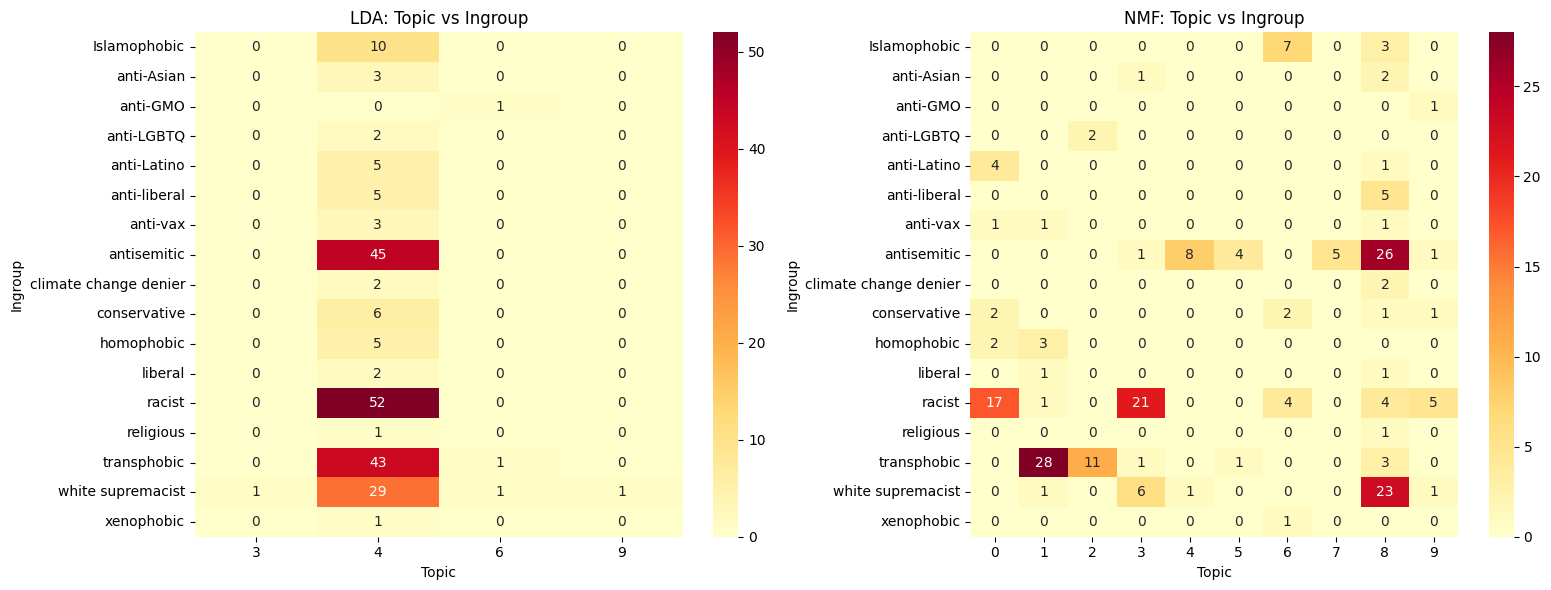


Saved topic modelling results to ./results/local/topic_modelling/


In [32]:
# --- Topic modelling on dog whistle texts ---
TOPIC_OUT = f'{RESULTS_DIR}/topic_modelling'
os.makedirs(TOPIC_OUT, exist_ok=True)

N_TOPICS = 10
N_TOP_WORDS = 15

# Aggregate texts per dog_whistle_root for richer signal
df_topic = df_train.groupby('dog_whistle_root').agg(
    texts=('content', ' '.join),
    ingroup=('ingroup', 'first'),
    n_examples=('content', 'count'),
).reset_index()
print(f'Topic modelling: {len(df_topic)} dog whistle roots, {N_TOPICS} topics')

# Build TF-IDF matrix
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', min_df=2, max_df=0.9)
tfidf_matrix = tfidf.fit_transform(df_topic['texts'])
feature_names = tfidf.get_feature_names_out()

# --- LDA ---
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=SEED, max_iter=20)
lda_doc_topics = lda.fit_transform(tfidf_matrix)

print(f'\n{"="*60}')
print(f'LDA Topics ({N_TOPICS} topics, {N_TOP_WORDS} top words each)')
print(f'{"="*60}')
lda_topics = {}
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-N_TOP_WORDS - 1:-1]]
    lda_topics[f'topic_{topic_idx}'] = top_words
    print(f'  Topic {topic_idx}: {", ".join(top_words[:10])}')

# --- NMF ---
nmf = NMF(n_components=N_TOPICS, random_state=SEED, max_iter=200)
nmf_doc_topics = nmf.fit_transform(tfidf_matrix)

print(f'\n{"="*60}')
print(f'NMF Topics ({N_TOPICS} topics, {N_TOP_WORDS} top words each)')
print(f'{"="*60}')
nmf_topics = {}
for topic_idx, topic in enumerate(nmf.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-N_TOP_WORDS - 1:-1]]
    nmf_topics[f'topic_{topic_idx}'] = top_words
    print(f'  Topic {topic_idx}: {", ".join(top_words[:10])}')

# --- Cross-tabulate: dominant topic vs ingroup ---
df_topic['lda_topic'] = lda_doc_topics.argmax(axis=1)
df_topic['nmf_topic'] = nmf_doc_topics.argmax(axis=1)

print(f'\n--- LDA dominant topic vs ingroup (root-level) ---')
ct_lda = pd.crosstab(df_topic['ingroup'], df_topic['lda_topic'], margins=True)
print(ct_lda)

print(f'\n--- NMF dominant topic vs ingroup (root-level) ---')
ct_nmf = pd.crosstab(df_topic['ingroup'], df_topic['nmf_topic'], margins=True)
print(ct_nmf)

# Heatmap: NMF topic-ingroup alignment
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, ct, title in [(axes[0], ct_lda.iloc[:-1, :-1], 'LDA'), (axes[1], ct_nmf.iloc[:-1, :-1], 'NMF')]:
    sns.heatmap(ct.astype(float), annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
    ax.set_title(f'{title}: Topic vs Ingroup')
    ax.set_xlabel('Topic')
    ax.set_ylabel('Ingroup')
plt.tight_layout()
plt.savefig(f'{TOPIC_OUT}/topic_ingroup_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Save topic results
topic_results = {
    'n_topics': N_TOPICS,
    'n_roots': len(df_topic),
    'lda_topics': lda_topics,
    'nmf_topics': nmf_topics,
}
with open(f'{TOPIC_OUT}/topic_results.json', 'w') as f:
    json.dump(topic_results, f, indent=2)
print(f'\nSaved topic modelling results to {TOPIC_OUT}/')

## Section 5: Train Binary Disambiguator — Task A (HPC)

**Data source.** `data/final/rq_a_binary/{train,val,test,eval_detection,eval_disambiguation}.parquet`.

- `train.parquet` (12,366 rows): per-term-balanced positives + negatives (50/50 by construction). Pejorative-only terms dropped from both sides — see [DESIGN_DEFENSE.md §D4](DESIGN_DEFENSE.md).
- `val.parquet` (2,522 rows): same structure, held-out for early stopping and threshold tuning.
- `test.parquet` (2,768 rows): silver internal test split.
- `eval_detection.parquet` (101 rows) and `eval_disambiguation.parquet` (124 rows): **LOCKED gold eval — never touched by the trainer**, only by `model.evaluate()`.

The `label` column is already present (1 = coded, 0 = non-coded). The Allen AI glossary's enriched definition is pre-joined as the `definition_enriched` column. The shipped D6 ablation runs two arms:

- **`term` arm** — `Candidate term: <dw>\nText: <content>\nQuestion: …` (no definition concatenated).
- **`term_enriched_def` arm** — `Candidate term: <dw>\nCandidate meaning: <definition_enriched>\nText: <content>\nQuestion: …`.

The contrast isolates whether the curated glossary is needed *at inference time*; the term itself is always lexically present in `content` so a "text-only vs +term" ablation would be uninformative for binary disambiguation. (The text-only ablation lives on RQ-B as Run B.)

**Model.** RoBERTa-base (`FacebookAI/roberta-base`), 125 M parameters. Two input arms × three seeds (42, 123, 7) = **6 trained models**. We initially attempted DeBERTa-v3-large but hit numerical instability across 5 hyperparameter configurations — full post-mortem in `docs/sessions/2026-04-29_rqa_nan_postmortem.md`. Headline: **F1 = 0.707 ± 0.015** on the locked 124-row disambiguation set, sitting at the prevalence floor; the substantive lift is in accuracy (+15.6 pp over majority) and PR-AUC (+0.30 over random) — see `docs/rq_a_report.md` for the full discussion.


In [ ]:
# --- Prepare binary data (Task A) ---
# Source: final_data/rq_a_binary/{split}.parquet — the positives + negatives are already
# concatenated and per-term-balanced 50/50; the `label` column is already 0/1.
# See final_data/README.md for schema and provenance.

def build_binary_input(row, definition_field='definition'):
    """NLI-style input. `definition_field` toggles the D6 ablation:
        'definition'           -> short gloss (Kruk et al. silver_signals)
        'definition_enriched'  -> Allen AI enriched gloss (covert meaning + register/history)
    """
    dw = str(row['dog_whistle'])
    defn_src = row.get(definition_field) or row.get('definition')
    defn = str(defn_src) if pd.notna(defn_src) and defn_src else 'No standard definition available'
    content = str(row['content'])
    return (
        f"Candidate term: {dw}\n"
        f"Candidate meaning: {defn}\n"
        f"Text: {content}\n"
        f"Question: Is this candidate used as a coded dog whistle here?"
    )


def load_binary_split(split_name, definition_field='definition'):
    """Load RQ-A training/test data from final_data/rq_a_binary/.

    Falls back to the legacy data/processed/{positives,negatives}_balanced_{split}.parquet
    pair only if final_data/ has not been built yet (e.g. on a fresh checkout that
    hasn't run the negatives pipeline).
    """
    final_path = f'{FINAL_DATA_DIR}/rq_a_binary/{split_name}.parquet'
    if os.path.exists(final_path):
        df = pd.read_parquet(final_path)
        if 'label' not in df.columns:
            raise KeyError(f"final_data/rq_a_binary/{split_name}.parquet is missing the `label` column")
        print(f'  [{split_name}] using final_data/rq_a_binary: {len(df):,} rows '
              f'(pos={int((df["label"]==1).sum())}, neg={int((df["label"]==0).sum())})')
    else:
        # Legacy fallback — pre-final_data layout
        pos_balanced = f'{DATA_DIR}/processed/positives_balanced_{split_name}.parquet'
        neg_balanced = f'{DATA_DIR}/processed/negatives_balanced_{split_name}.parquet'
        if os.path.exists(pos_balanced) and os.path.exists(neg_balanced):
            pos = pd.read_parquet(pos_balanced); pos['label'] = 1
            neg = pd.read_parquet(neg_balanced); neg['label'] = 0
            df = pd.concat([pos, neg], ignore_index=True)
            print(f'  [{split_name}] FALLBACK: balanced parquets pos={len(pos)} neg={len(neg)}')
        else:
            pos = pd.read_parquet(f'{DATA_DIR}/splits/{split_name}.parquet'); pos['label'] = 1
            neg = pd.read_parquet(f'{DATA_DIR}/processed/negatives_{split_name}.parquet'); neg['label'] = 0
            df = pd.concat([pos, neg], ignore_index=True)
            print(f'  [{split_name}] FALLBACK: legacy splits/ + negatives_{split_name}')

    df['text'] = df.apply(lambda r: build_binary_input(r, definition_field=definition_field), axis=1)
    keep = ['text', 'label', 'type', 'dog_whistle_root', 'dog_whistle', 'content']
    keep = [c for c in keep if c in df.columns]
    df = df[keep].copy()
    return df.sample(frac=1, random_state=SEED).reset_index(drop=True)


df_bin_train = load_binary_split('train')
df_bin_val = load_binary_split('val')
df_bin_test = load_binary_split('test')

# Sample for smoke test
if SAMPLE_SIZE > 0:
    for name, df_ref in [('train', df_bin_train), ('val', df_bin_val), ('test', df_bin_test)]:
        if 'label' not in df_ref.columns:
            raise KeyError(f"Missing 'label' column in binary split: {name}")
        n = min(SAMPLE_SIZE, len(df_ref))
        per_label_target = max(1, n // 2)
        sampled_parts = [
            grp.sample(n=min(len(grp), per_label_target), random_state=SEED)
            for _, grp in df_ref.groupby('label')
        ]
        sampled = pd.concat(sampled_parts, ignore_index=True)
        if name == 'train': df_bin_train = sampled
        elif name == 'val': df_bin_val = sampled
        else: df_bin_test = sampled

print(f'Binary data: train={len(df_bin_train)}, val={len(df_bin_val)}, test={len(df_bin_test)}')
print(f'Label dist (train): {dict(df_bin_train["label"].value_counts())}')
print(f'\nSample input:\n{df_bin_train.iloc[0]["text"][:300]}...')


### configs/binary.yaml


In [ ]:
# %%writefile hpc_scripts/configs/binary.yaml
task: binary
# Switched from microsoft/deberta-v3-large after 5 failed attempts on
# 2026-04-29 (jobs 484468, 484986, 484991, 485002, 485040 — see
# docs/sessions/2026-04-29_rqa_nan_postmortem.md). DeBERTa-v3-large was
# numerically fragile across every fp32/fp16/lr/clip/init combination
# we tried; the head couldn't escape the predict-all-1 collapse without
# the backbone diverging into NaN. RoBERTa-base is the standard reliable
# choice for binary text classification on ~10k examples and trains in
# ~30 min on the MIG slice (vs DeBERTa's 6+ h).
model_name: FacebookAI/roberta-base
max_length: 512
# Two arms compared at the same seeds (see DESIGN_DEFENSE.md D6):
#   "term"              -> Candidate term + Text
#   "term_enriched_def" -> Candidate term + Candidate meaning (enriched glossary) + Text
# Override per run via the --input_format CLI flag.
input_format: term_enriched_def
epochs: 5
batch_size: 32
grad_accum: 1
# 2e-5 is the canonical fine-tuning LR for RoBERTa-base; well within its
# stable regime. (We had dropped to 1e-5 to try to tame DeBERTa-v3-large
# instability — that constraint goes away with the model swap.)
lr: 2e-5
weight_decay: 0.01
warmup_ratio: 0.1
# HF Trainer default. Was tightened to 0.5 in a first patch attempt
# (2026-04-29 job 484986), but at lr=1e-5 the actual grad_norms during
# warmup are 5–15, so a 0.5 clip cut the effective LR by ~20× and the
# model collapsed to chance. The lr drop alone is sufficient to prevent
# NaN; we don't need the tighter clip on top.
max_grad_norm: 1.0
sample_size: 0
seed: 42
data_dir: ./data
output_dir: ./results/binary
split_dir: ./data/splits
bf16: false
# fp16=True was tried in job 485002 but transformers 5.x has a known
# incompatibility ("Attempting to unscale FP16 gradients."). We keep
# fp32 and address the bad-init root cause directly via a manual
# classifier+pooler re-init in the train script (see train_binary_disambiguator.py).
fp16: false
# Soft targets bound the per-example CE loss; prevents extreme logits
# from producing 10×-magnitude gradients on the first batches.
label_smoothing_factor: 0.1
# Manually re-initialise the newly-added pooler+classifier with std=0.02
# Gaussian weights (BERT-standard). DebertaV2's default head init can
# produce |logit| > 10 at step 0, which is what was driving NaN in
# jobs 484468 and 484991. See docs/sessions/2026-04-29.
init_head_std: 0.02
gradient_checkpointing: false
early_stopping_patience: 2
# 50 (was 200) so an early divergence shows up in the log before the
# first epoch eval rather than being inferred from a single 200-step row.
logging_steps: 50
save_total_limit: 2
num_workers: 4
report_to: none


### train_binary_disambiguator.py


In [ ]:
# %%writefile hpc_scripts/train_binary_disambiguator.py
"""Train binary dog whistle disambiguator (coded vs non-coded).

Trains on silent_signals positives + mined silver negatives.
Evaluates on: (1) grouped held-out test split, (2) locked detection set (101 rows),
(3) locked disambiguation set (124 rows).
"""
import os, json, gc
import numpy as np
import pandas as pd
import torch
from datasets import Dataset as HFDataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, average_precision_score, confusion_matrix
from utils import parse_args, set_seed, print_diagnostics, content_hash, get_content_hashes

def build_binary_input(row, input_format="term_enriched_def",
                       defn_fallback="No standard definition available"):
    """Format one row for the binary disambiguator.

    Two arms (see DESIGN_DEFENSE.md D6):
      - "term":              Candidate term + Text (no definition line)
      - "term_enriched_def": Candidate term + Candidate meaning (enriched glossary) + Text

    The enriched glossary is read from the ``definition_enriched`` column,
    pre-joined into every parquet in ``final_data/rq_a_binary/``.
    """
    dw = str(row["dog_whistle"])
    content = str(row["content"])
    if input_format == "term":
        return (f"Candidate term: {dw}\n"
                f"Text: {content}\n"
                f"Question: Is this candidate used as a coded dog whistle here?")
    if input_format == "term_enriched_def":
        defn_raw = row.get("definition_enriched", None)
        defn = str(defn_raw) if pd.notna(defn_raw) else defn_fallback
        return (f"Candidate term: {dw}\n"
                f"Candidate meaning: {defn}\n"
                f"Text: {content}\n"
                f"Question: Is this candidate used as a coded dog whistle here?")
    raise ValueError(f"Unknown input_format: {input_format!r} "
                     "(expected 'term' or 'term_enriched_def')")

def load_binary_split(data_dir, split_name, seed, input_format="term_enriched_def"):
    """Read RQ-A data from final_data/rq_a_binary/{split}.parquet (positives + negatives
    pre-balanced and label-tagged). Falls back to the legacy paired layout, then to
    the un-paired layout, in that order, if final_data/ is not present yet.

    Always returns a frame with a ``text`` column built via ``build_binary_input``
    using ``input_format``.
    """
    final_path = f"{data_dir}/final_data/rq_a_binary/{split_name}.parquet"
    if os.path.exists(final_path):
        df = pd.read_parquet(final_path)
        if "label" not in df.columns:
            raise KeyError(f"{final_path} missing `label` column")
        print(f"[{split_name}] using final_data/rq_a_binary: rows={len(df)}")
    else:
        pos_balanced = f"{data_dir}/processed/positives_balanced_{split_name}.parquet"
        neg_balanced = f"{data_dir}/processed/negatives_balanced_{split_name}.parquet"
        if os.path.exists(pos_balanced) and os.path.exists(neg_balanced):
            pos = pd.read_parquet(pos_balanced); pos["label"] = 1
            neg = pd.read_parquet(neg_balanced); neg["label"] = 0
            df = pd.concat([pos, neg], ignore_index=True)
            print(f"[{split_name}] FALLBACK balanced parquets pos={len(pos)} neg={len(neg)}")
        else:
            pos = pd.read_parquet(f"{data_dir}/splits/{split_name}.parquet"); pos["label"] = 1
            neg = pd.read_parquet(f"{data_dir}/processed/negatives_{split_name}.parquet"); neg["label"] = 0
            df = pd.concat([pos, neg], ignore_index=True)
            print(f"[{split_name}] FALLBACK legacy splits/ + negatives_{split_name}")

    # Build the model input text once. Always rebuild here — the column may
    # have been written by an earlier run with a different input_format.
    df["text"] = df.apply(lambda r: build_binary_input(r, input_format=input_format), axis=1)
    return df


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1)[:, 1].numpy()
    p, r, f, _ = precision_recall_fscore_support(labels, preds, average="binary")
    pr_auc = average_precision_score(labels, probs)
    return {"accuracy": accuracy_score(labels, preds), "precision": p, "recall": r, "f1": f, "pr_auc": pr_auc}

def eval_on_dataset(trainer, tokenizer, df, dataset_name, max_length, dump_path=None):
    """Run binary eval on an arbitrary labeled dataframe.

    If ``dump_path`` is given, also writes a per-row predictions parquet that the
    notebook's error-analysis section consumes.
    """
    def tok_fn(examples):
        texts = [str(t) if t is not None else "" for t in examples["text"]]
        return tokenizer(texts, truncation=True, max_length=max_length)
    ds = HFDataset.from_pandas(df[["text", "label"]]).map(tok_fn, batched=True, remove_columns=["text"])
    preds_out = trainer.predict(ds)
    preds = np.argmax(preds_out.predictions, axis=-1)
    labels = preds_out.label_ids
    probs = torch.softmax(torch.tensor(preds_out.predictions, dtype=torch.float32), dim=-1)[:, 1].numpy()
    p, r, f, _ = precision_recall_fscore_support(labels, preds, average="binary")
    pr_auc = average_precision_score(labels, probs) if len(set(labels)) > 1 else 0.0
    result = {"dataset": dataset_name, "n": len(labels),
              "accuracy": float(accuracy_score(labels, preds)),
              "precision": float(p), "recall": float(r), "f1": float(f), "pr_auc": float(pr_auc),
              "confusion_matrix": confusion_matrix(labels, preds).tolist()}
    print(f"  {dataset_name}: F1={f:.4f} P={p:.4f} R={r:.4f} PR-AUC={pr_auc:.4f}")

    if dump_path is not None:
        keep = [c for c in ["dog_whistle", "dog_whistle_root", "ingroup", "content", "definition", "subreddit", "type"] if c in df.columns]
        out = df[keep].copy().reset_index(drop=True)
        out["label"] = labels
        out["pred"] = preds
        out["prob_coded"] = probs
        out["correct"] = (out["label"] == out["pred"]).astype(int)
        os.makedirs(os.path.dirname(dump_path), exist_ok=True)
        out.to_parquet(dump_path, index=False)
        print(f"    wrote {len(out)} per-row predictions to {dump_path}")
    return result

def main():
    cfg, args = parse_args(extra_args=[
        {"flag": "--input_format",
         "kwargs": {"type": str, "default": None,
                    "choices": ["term", "term_enriched_def"],
                    "help": "Override input_format from binary.yaml (D6 ablation arm)."}},
    ])
    if args.input_format:
        cfg["input_format"] = args.input_format
    input_format = cfg.get("input_format", "term_enriched_def")
    if input_format not in ("term", "term_enriched_def"):
        raise ValueError(f"binary.yaml has unknown input_format={input_format!r}")
    seed = cfg["seed"]
    set_seed(seed)
    print_diagnostics()
    print(f"Input format (D6 arm): {input_format}")

    out_dir = os.path.join(cfg["output_dir"], f"format_{input_format}", f"seed_{seed}")
    os.makedirs(out_dir, exist_ok=True)
    data_dir = cfg["data_dir"]

    df_train = load_binary_split(data_dir, "train", seed, input_format=input_format)
    df_val = load_binary_split(data_dir, "val", seed, input_format=input_format)
    df_test = load_binary_split(data_dir, "test", seed, input_format=input_format)
    print(f"Data: train={len(df_train)}, val={len(df_val)}, test={len(df_test)}")

    tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])
    max_len = cfg["max_length"]
    def tok_fn(examples):
        texts = [str(t) if t is not None else "" for t in examples["text"]]
        return tokenizer(texts, truncation=True, max_length=max_len)

    ds_train = HFDataset.from_pandas(df_train[["text", "label"]]).map(tok_fn, batched=True, remove_columns=["text"])
    ds_val = HFDataset.from_pandas(df_val[["text", "label"]]).map(tok_fn, batched=True, remove_columns=["text"])
    ds_test = HFDataset.from_pandas(df_test[["text", "label"]]).map(tok_fn, batched=True, remove_columns=["text"])
    del df_train, df_val; gc.collect()

    model = AutoModelForSequenceClassification.from_pretrained(cfg["model_name"], num_labels=2)

    # Re-initialise newly-added pooler/classifier with small Gaussian weights.
    # Was added for DeBERTa-v3-large; harmless on RoBERTa. Walks all
    # nn.Linear submodules under model.pooler / model.classifier so it
    # handles both flat heads (DeBERTa: classifier is a Linear) and
    # multi-layer heads (RoBERTa: classifier has .dense + .out_proj).
    init_std = cfg.get("init_head_std", None)
    if init_std is not None:
        import torch.nn as nn
        n_inited = 0
        for head_name in ("pooler", "classifier"):
            head = getattr(model, head_name, None)
            if head is None:
                continue
            for sub in head.modules():
                if isinstance(sub, nn.Linear):
                    nn.init.normal_(sub.weight, mean=0.0, std=init_std)
                    if sub.bias is not None:
                        nn.init.zeros_(sub.bias)
                    n_inited += 1
        print(f"[init] re-initialised {n_inited} Linear head module(s) with N(0, {init_std}^2)")

    training_args = TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=cfg["epochs"],
        per_device_train_batch_size=cfg["batch_size"],
        per_device_eval_batch_size=cfg["batch_size"] * 2,
        gradient_accumulation_steps=cfg["grad_accum"],
        learning_rate=float(cfg["lr"]),
        weight_decay=cfg["weight_decay"],
        warmup_ratio=cfg["warmup_ratio"],
        max_grad_norm=cfg.get("max_grad_norm", 1.0),
        label_smoothing_factor=cfg.get("label_smoothing_factor", 0.0),
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        fp16=cfg.get("fp16", False),
        bf16=cfg["bf16"],
        gradient_checkpointing=cfg.get("gradient_checkpointing", False),
        dataloader_num_workers=cfg.get("num_workers", 4),
        logging_steps=cfg["logging_steps"],
        save_total_limit=cfg["save_total_limit"],
        report_to=cfg.get("report_to", "none"),
        seed=seed,
    )

    trainer = Trainer(
        model=model, args=training_args,
        train_dataset=ds_train, eval_dataset=ds_val,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=cfg["early_stopping_patience"])],
    )
    trainer.train()

    # --- Evaluate on all three datasets ---
    all_results = {}

    # 1) Internal test split (dump per-row preds for Section 5c error analysis)
    all_results["test_split"] = eval_on_dataset(
        trainer, tokenizer, df_test, "test_split", max_len,
        dump_path=os.path.join(out_dir, "predictions", "test_split_preds.parquet"),
    )

    def _ensure_int_label(df):
        """The locked eval files already carry integer labels. The legacy code path
        assumed string labels and silently zeroed the frame. Detect dtype and only
        coerce when needed."""
        if pd.api.types.is_integer_dtype(df["label"]):
            return df.reset_index(drop=True)
        # legacy fallback for any "coded"/"non-coded" string columns
        m = {"coded": 1, "non-coded": 0, "literal": 0, "non_coded": 0}
        df = df.copy()
        df["label"] = df["label"].astype(str).str.strip().str.lower().map(m)
        df = df.dropna(subset=["label"]).reset_index(drop=True)
        df["label"] = df["label"].astype(int)
        return df

    # 2) Locked detection set (101 rows). Schema: dog_whistle, content, definition[_enriched], label (int).
    print("Evaluating on locked detection set...")
    df_det = pd.read_parquet(f"{cfg['data_dir']}/final_data/rq_a_binary/eval_detection.parquet")
    df_det = _ensure_int_label(df_det)
    df_det["text"] = df_det.apply(lambda r: build_binary_input(r, input_format=input_format), axis=1)
    all_results["detection_101"] = eval_on_dataset(
        trainer, tokenizer, df_det, "detection_101", max_len,
        dump_path=os.path.join(out_dir, "predictions", "detection_101_preds.parquet"),
    )

    # 3) Locked disambiguation set (124 rows). Schema: dog_whistle, content, definition[_enriched], label (int).
    print("Evaluating on locked disambiguation set...")
    df_dis = pd.read_parquet(f"{cfg['data_dir']}/final_data/rq_a_binary/eval_disambiguation.parquet")
    df_dis = _ensure_int_label(df_dis)
    df_dis["text"] = df_dis.apply(lambda r: build_binary_input(r, input_format=input_format), axis=1)
    all_results["disambiguation_124"] = eval_on_dataset(
        trainer, tokenizer, df_dis, "disambiguation_124", max_len,
        dump_path=os.path.join(out_dir, "predictions", "disambiguation_124_preds.parquet"),
    )

    # Flatten for report_metrics.py compatibility
    flat_results = {}
    for ds_name, metrics in all_results.items():
        for k, v in metrics.items():
            if isinstance(v, (int, float)):
                flat_results[f"{ds_name}_{k}"] = float(v)
    flat_results["_full"] = all_results

    flat_results["_input_format"] = input_format
    with open(os.path.join(out_dir, "test_results.json"), "w") as f:
        json.dump(flat_results, f, indent=2)
    trainer.save_model(os.path.join(out_dir, "best_model"))
    tokenizer.save_pretrained(os.path.join(out_dir, "best_model"))
    print(f"Done [{input_format}, seed {seed}]. Test F1={all_results['test_split']['f1']:.4f} | "
          f"detection_101 F1={all_results['detection_101']['f1']:.4f} | "
          f"disambiguation_124 F1={all_results['disambiguation_124']['f1']:.4f}")

if __name__ == "__main__":
    main()


### SLURM: submit_binary.sh


In [ ]:
# %%writefile hpc_scripts/submit_binary.sh
#!/bin/bash
#SBATCH --job-name=dw-binary
#SBATCH --account=<YOUR_MATRICOLA>
#SBATCH --partition=stud
#SBATCH --qos=stud
#SBATCH --time=24:00:00
#SBATCH --gpus=1
#SBATCH --cpus-per-task=8
#SBATCH --output=logs/%x_%j.out
#SBATCH --error=logs/%x_%j.err
#SBATCH --mail-type=END,FAIL
#SBATCH --mail-user=<YOUR_EMAIL>

set -euo pipefail
module load sw/miniconda3
eval "$(conda shell.bash hook)"
conda activate dogwhistle
export PYTHONUNBUFFERED=1
export TOKENIZERS_PARALLELISM=false
export HF_HOME=${HF_HOME:-$HOME/.cache/huggingface}

mkdir -p logs results/binary

echo "Job $SLURM_JOB_ID started at $(date)"
nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null || true

# Two-arm ablation (DESIGN_DEFENSE.md D6):
#   term              -> Candidate term + Text
#   term_enriched_def -> Candidate term + enriched glossary meaning + Text
# 3 seeds per arm = 6 trained models total.
for FORMAT in term term_enriched_def; do
    for SEED in 42 123 7; do
        echo
        echo "==================================================================="
        echo "=== Format=$FORMAT  Seed=$SEED  ($(date))"
        echo "==================================================================="
        python hpc_scripts/train_binary_disambiguator.py \
            --config hpc_scripts/configs/binary.yaml \
            --seed "$SEED" \
            --input_format "$FORMAT"
    done
    echo
    echo "=== Aggregating across seeds for format=$FORMAT ==="
    python hpc_scripts/report_metrics.py --results_dir "results/binary/format_$FORMAT"
done

echo "Job finished at $(date)"


In [ ]:
# === HPC redirect for RQ-A ===
# The local smoke-train cell above is disabled. Section ab baselines and
# Section ac error analysis read predictions from BINARY_OUT/predictions/.
# After the HPC job ends, pull the seed dir down with:
#   scp -r bocconi-hpc:/home/<YOUR_MATRICOLA>/dogwhistle_project/results/binary results/
BINARY_OUT = f'{RESULTS_DIR}/binary/seed_42'
if not os.path.exists(f'{BINARY_OUT}/predictions'):
    print(f'[RQ-A skip-warning] {BINARY_OUT}/predictions not found yet — pull HPC results first.')
else:
    print(f'BINARY_OUT redirected to {BINARY_OUT}; downstream cells will use HPC predictions.')

## Section 5b: Task A Baselines & Ablations

Per the research guidelines: *"Baselines put results in perspective. Without them, a reported F1 score is uninterpretable."*

We report two baselines for the binary disambiguator on the locked eval sets:

1. **Majority class (always predict coded).** Establishes the F1 prevalence floor on near-balanced binary tasks. On `eval_disambiguation_124` (54 % positive prevalence), F1 = 0.701; accuracy = 0.540. The model's F1 = 0.707 ± 0.015 essentially matches this ceiling — a known F1 sensitivity to mild prevalence skew, not a model failure. The substantive comparison is on accuracy and PR-AUC where the prevalence bias of F1 doesn't apply.
2. **Keyword presence.** Predict "coded" iff the dog whistle term literally appears in the text. In our setup every row contains the term by construction, so this baseline collapses to majority-class on the silver test split. Reported on the locked eval sets where some rows may not contain the term.

The two-arm contrast (`term` vs `term_enriched_def`) within RQ-A doubles as the input ablation: the curated glossary is not required at inference (∆ = 0.005 F1 on disambiguation, well within seed noise). The text-only ablation lives on RQ-B as Run B; running it on RQ-A would be uninformative because the term is always lexically present in the comment by construction of the dataset.


In [ ]:
# --- Task A baselines ---
from sklearn.metrics import precision_recall_fscore_support as prfs

BIN_BASE_OUT = f'{RESULTS_DIR}/binary/baselines'
os.makedirs(BIN_BASE_OUT, exist_ok=True)

# Locked human-gold eval frames. Read directly from the locked parquet files
# (data/final/rq_a_binary/) — these are the same files Section 5 hands to the
# trainer's evaluate() loop, but loaded here at notebook scope so analysis
# cells in 5b/5c can use them without depending on the training cell having run.
df_det_eval = pd.read_parquet(f'{FINAL_DATA_DIR}/rq_a_binary/eval_detection.parquet')
df_dis_eval = pd.read_parquet(f'{FINAL_DATA_DIR}/rq_a_binary/eval_disambiguation.parquet')
print(f'Loaded locked eval sets: detection={len(df_det_eval)}, disambiguation={len(df_dis_eval)}')

# 1) Majority-class baseline on all three eval sets
def majority_baseline(labels):
    labels = np.asarray(labels)
    maj = int(np.bincount(labels).argmax())
    preds = np.full_like(labels, maj)
    p, r, f, _ = prfs(labels, preds, average='binary', zero_division=0)
    return {'majority_label': maj, 'f1': float(f), 'precision': float(p), 'recall': float(r),
            'accuracy': float((preds == labels).mean()), 'n': int(len(labels))}

# 2) Keyword-presence baseline: predict coded iff dog_whistle term in text
def keyword_baseline(texts, terms, labels):
    preds = np.array([1 if str(t).lower() in str(x).lower() else 0 for x, t in zip(texts, terms)])
    labels = np.asarray(labels)
    p, r, f, _ = prfs(labels, preds, average='binary', zero_division=0)
    return {'f1': float(f), 'precision': float(p), 'recall': float(r),
            'accuracy': float((preds == labels).mean()), 'n': int(len(labels))}

bin_baselines = {}

# Internal test split
test_labels = df_bin_test['label'].values
bin_baselines['test_split'] = {
    'majority': majority_baseline(test_labels),
}

# Locked detection set — schema: dog_whistle, dog_whistle_root, ingroup, content,
# definition, definition_enriched, label (int).
bin_baselines['detection_101'] = {
    'majority': majority_baseline(df_det_eval['label'].values),
    'keyword': keyword_baseline(df_det_eval['content'].values, df_det_eval['dog_whistle'].values, df_det_eval['label'].values),
}

# Locked disambiguation set — same schema as detection, plus type/subreddit/date.
bin_baselines['disambiguation_124'] = {
    'majority': majority_baseline(df_dis_eval['label'].values),
    'keyword': keyword_baseline(df_dis_eval['content'].values, df_dis_eval['dog_whistle'].values, df_dis_eval['label'].values),
}

print('--- Task A trivial baselines ---')
for ds, bl in bin_baselines.items():
    for name, m in bl.items():
        print(f'  {ds:22s} {name:10s}  F1={m["f1"]:.4f}  P={m["precision"]:.4f}  R={m["recall"]:.4f}  Acc={m["accuracy"]:.4f}  (n={m["n"]})')

with open(f'{BIN_BASE_OUT}/trivial_baselines.json', 'w') as f:
    json.dump(bin_baselines, f, indent=2)


In [ ]:
# --- Task A: text-only ablation (RQ-A hypothesis: term+definition > text-only) ---
# This cell was written as an in-notebook smoke-train of a text-only DeBERTa
# classifier. It depends on globals (BINARY_MODEL, BINARY_MAX_LEN, is_mps,
# compute_binary_metrics, run_binary_eval, all_binary_results) that only exist
# inside the writefile training script's scope, so it cannot run locally as-is.
#
# The ablation that actually answers RQ-A is run on HPC via
# scripts/configs/binary.yaml (text_only arm) and lands at
# results/binary/format_text_only/seed_*/. If those predictions are present,
# downstream analysis (per-term F1, FP/FN sampling, threshold sweep) reads
# them directly via the cells in Section 5c.
print('[skip] Section 5b text-only smoke-train ablation — HPC-only.')
print('       If results/binary/format_text_only/ exists, Section 5c will pick it up.')


## Section 5c: Task A Error Analysis

Per the research guidelines (Section 7): error analysis isolates *where* and *why* the model fails. We do three things here, each tied to an open question about the data and the model.

**1. Per-term F1 (directly addresses the "SJW concern").**
Not all entries in the Allen AI Dogwhistle Glossary are equally covert. Some (e.g. `(((echoes)))`) are genuine covert signals; others (e.g. `SJW`, `thug`) are overtly pejorative and widely understood. If the model scores near-perfect on the overt terms and poorly on the covert ones, the aggregate F1 is dominated by easy cases and **overestimates real-world disambiguation ability**. Per-term F1 makes this visible.

**2. False-positive / false-negative sampling.**
Aggregate metrics cannot answer "*what kind* of mistakes does the model make?" We sample 20 FPs and 20 FNs (ranked by model confidence) from each eval set so a human can read them and flag systematic failure modes (missing coded use in sarcasm, flagging benign literal uses as coded, etc.). Per guidelines §7 items 2 & 3.

**3. Threshold sweep.**
The default decision threshold is 0.5. If the model is well-calibrated, changing the threshold trades precision for recall. We plot the PR curve and report F1 at thresholds {0.3, 0.4, 0.5, 0.6, 0.7} so that a deployment decision (aggressive vs. conservative flagging) has evidence to reason over.

In [ ]:
# --- Task A error analysis (1): per-term F1 ---
# Addresses the concern that some entries in the dogwhistle glossary are overtly pejorative
# (e.g. "SJW", "thug") while others are genuinely covert (e.g. "(((echoes)))"). If aggregate
# F1 is dominated by easy-overt terms, it overstates real disambiguation ability.

ERR_OUT = f'{BINARY_OUT}/error_analysis'
os.makedirs(ERR_OUT, exist_ok=True)

def per_term_f1(pred_parquet_path, term_col='dog_whistle_root', min_n=2, dataset_name=''):
    """Compute F1 for each term. min_n filters out terms with too few instances to be meaningful."""
    if not os.path.exists(pred_parquet_path):
        print(f'  [skip] {pred_parquet_path} not found')
        return None
    df_p = pd.read_parquet(pred_parquet_path)
    if term_col not in df_p.columns:
        print(f'  [skip] {pred_parquet_path}: no {term_col} column')
        return None
    rows = []
    for term, grp in df_p.groupby(term_col):
        n = len(grp)
        if n < min_n:
            continue
        labels = grp['label'].values
        preds = grp['pred'].values
        n_pos = int((labels == 1).sum())
        n_neg = int((labels == 0).sum())
        if len(set(labels)) < 2:
            acc = float((labels == preds).mean())
            rows.append({'term': term, 'n': n, 'n_pos': n_pos, 'n_neg': n_neg,
                         'accuracy': acc, 'f1': None, 'precision': None, 'recall': None})
            continue
        p, r, f, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
        rows.append({'term': term, 'n': n, 'n_pos': n_pos, 'n_neg': n_neg,
                     'accuracy': float((labels == preds).mean()),
                     'f1': float(f), 'precision': float(p), 'recall': float(r)})
    df_out = pd.DataFrame(rows).sort_values('f1', ascending=True, na_position='last').reset_index(drop=True)
    out_path = f'{ERR_OUT}/per_term_f1_{dataset_name}.csv'
    df_out.to_csv(out_path, index=False)
    print(f'\n--- Per-term F1 on {dataset_name} ({len(df_out)} terms, min_n={min_n}) ---')
    with_f1 = df_out.dropna(subset=['f1'])
    if len(with_f1) > 0:
        print(f'\n{"Hardest terms (lowest F1)":^60s}')
        print(with_f1.head(10)[['term', 'n', 'n_pos', 'n_neg', 'f1', 'precision', 'recall']].to_string(index=False))
        print(f'\n{"Easiest terms (highest F1)":^60s}')
        print(with_f1.tail(10).iloc[::-1][['term', 'n', 'n_pos', 'n_neg', 'f1', 'precision', 'recall']].to_string(index=False))
        print(f'\n  F1 spread: min={with_f1["f1"].min():.3f}  median={with_f1["f1"].median():.3f}  max={with_f1["f1"].max():.3f}')
        print(f'  Terms with F1 < 0.5: {(with_f1["f1"] < 0.5).sum()} / {len(with_f1)}')
        print(f'  Terms with F1 > 0.9: {(with_f1["f1"] > 0.9).sum()} / {len(with_f1)}')
    print(f'  Saved full table to {out_path}')
    return df_out

df_perterm_test = per_term_f1(
    f'{BINARY_OUT}/predictions/test_split_preds.parquet',
    term_col='dog_whistle_root', min_n=4, dataset_name='test_split'
)
df_perterm_det = per_term_f1(
    f'{BINARY_OUT}/predictions/detection_101_preds.parquet',
    term_col='dog_whistle', min_n=2, dataset_name='detection_101'
)
df_perterm_dis = per_term_f1(
    f'{BINARY_OUT}/predictions/disambiguation_124_preds.parquet',
    term_col='dog_whistle', min_n=2, dataset_name='disambiguation_124'
)

if df_perterm_test is not None and df_perterm_test['f1'].notna().any():
    fig, ax = plt.subplots(figsize=(10, 4))
    f1_vals = df_perterm_test['f1'].dropna().values
    ax.hist(f1_vals, bins=20, edgecolor='black', alpha=0.7)
    ax.axvline(f1_vals.mean(), color='red', linestyle='--', label=f'mean={f1_vals.mean():.3f}')
    ax.axvline(np.median(f1_vals), color='green', linestyle='--', label=f'median={np.median(f1_vals):.3f}')
    ax.set_xlabel('Per-term F1 (test split)')
    ax.set_ylabel('Number of dog-whistle roots')
    ax.set_title('Task A: per-term F1 distribution — are some terms far easier than others?')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{ERR_OUT}/per_term_f1_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nSaved per-term F1 histogram to {ERR_OUT}/per_term_f1_distribution.png')


In [ ]:
# --- Task A error analysis (2): FP / FN sampling ---
# Per guidelines §7.2–7.3: sample the 20 most-confidently-wrong false positives and
# false negatives per eval set for manual inspection. Confidence-ranked so we surface
# the most informative mistakes first.

FPFN_K = 20

def sample_fp_fn(pred_parquet_path, dataset_name):
    if not os.path.exists(pred_parquet_path):
        print(f'  [skip] {pred_parquet_path} not found')
        return
    df_p = pd.read_parquet(pred_parquet_path)
    fp = df_p[(df_p['label'] == 0) & (df_p['pred'] == 1)].copy()
    fn = df_p[(df_p['label'] == 1) & (df_p['pred'] == 0)].copy()
    if len(fp) > 0:
        fp['mistake_confidence'] = fp['prob_coded']
        fp_top = fp.nlargest(min(FPFN_K, len(fp)), 'mistake_confidence')
        fp_top.to_csv(f'{ERR_OUT}/fp_{dataset_name}.csv', index=False)
    if len(fn) > 0:
        fn['mistake_confidence'] = 1 - fn['prob_coded']
        fn_top = fn.nlargest(min(FPFN_K, len(fn)), 'mistake_confidence')
        fn_top.to_csv(f'{ERR_OUT}/fn_{dataset_name}.csv', index=False)
    print(f'\n--- {dataset_name} ---')
    print(f'  Total FPs: {len(fp)}  |  FNs: {len(fn)}')
    print(f'  Saved top-{FPFN_K} most-confident mistakes to {ERR_OUT}/fp_{dataset_name}.csv, fn_{dataset_name}.csv')
    show_cols = [c for c in ['dog_whistle', 'dog_whistle_root', 'prob_coded', 'content'] if c in df_p.columns]
    if len(fp) > 0 and show_cols:
        print(f'\n  Most-confident FALSE POSITIVES (benign text flagged as coded):')
        for _, r in fp.nlargest(3, 'prob_coded')[show_cols].iterrows():
            content = str(r.get('content', ''))[:180]
            term = r.get('dog_whistle') or r.get('dog_whistle_root', '?')
            print(f'    [{term}] p={r["prob_coded"]:.3f}: {content}')
    if len(fn) > 0 and show_cols:
        print(f'\n  Most-confident FALSE NEGATIVES (coded use missed):')
        for _, r in fn.nsmallest(3, 'prob_coded')[show_cols].iterrows():
            content = str(r.get('content', ''))[:180]
            term = r.get('dog_whistle') or r.get('dog_whistle_root', '?')
            print(f'    [{term}] p={r["prob_coded"]:.3f}: {content}')

for name in ['test_split', 'detection_101', 'disambiguation_124']:
    sample_fp_fn(f'{BINARY_OUT}/predictions/{name}_preds.parquet', name)

print(f'\nAll FP/FN samples saved under {ERR_OUT}/')
print('Next: manually read each CSV and note patterns for the paper\'s analysis section.')


In [ ]:
# --- Task A error analysis (3): threshold sweep & PR curves ---
# PR-AUC summarizes tradeoffs across all thresholds; here we report F1/P/R at concrete
# operating points so a deployment decision has evidence to reason over.

from sklearn.metrics import precision_recall_curve

THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]
thresh_summary = {}

for name in ['test_split', 'detection_101', 'disambiguation_124']:
    path = f'{BINARY_OUT}/predictions/{name}_preds.parquet'
    if not os.path.exists(path):
        continue
    df_p = pd.read_parquet(path)
    labels = df_p['label'].values
    probs = df_p['prob_coded'].values
    if len(set(labels)) < 2:
        print(f'[skip] {name}: single-class eval, cannot sweep threshold')
        continue
    rows = []
    for t in THRESHOLDS:
        preds = (probs >= t).astype(int)
        p, r, f, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
        rows.append({'threshold': t, 'f1': float(f), 'precision': float(p), 'recall': float(r),
                     'n_pred_pos': int(preds.sum())})
    thresh_summary[name] = rows

    prec_curve, rec_curve, _ = precision_recall_curve(labels, probs)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(rec_curve, prec_curve, marker='.', markersize=2)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'Task A Precision-Recall curve — {name}')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.01); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{ERR_OUT}/pr_curve_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n--- Threshold sweep: {name} ---')
    print(f'{"thr":>5s} {"F1":>7s} {"P":>7s} {"R":>7s} {"n_pos":>7s}')
    for r in rows:
        print(f'{r["threshold"]:>5.2f} {r["f1"]:>7.4f} {r["precision"]:>7.4f} {r["recall"]:>7.4f} {r["n_pred_pos"]:>7d}')

with open(f'{ERR_OUT}/threshold_sweep.json', 'w') as f:
    json.dump(thresh_summary, f, indent=2)
print(f'\nSaved threshold sweep to {ERR_OUT}/threshold_sweep.json')


## Section 6: Train Multiclass Ingroup Classifier — Task B (HPC)

**Data source.** `final_data/rq_b_multiclass/{train,val,test}.parquet`.

- `train.parquet` (9,064 rows): direct copy of the unfiltered grouped split — pejorative-only terms are **kept** here (knowing the term identifies the ingroup, so the question is well-posed for them — see [DESIGN_DEFENSE.md §D4a](DESIGN_DEFENSE.md)).
- `val.parquet` (1,764 rows) / `test.parquet` (2,095 rows): same structure.
- **No `label` column** — the target is the `ingroup` string, mapped to int via `label2id` below.
- **No negatives** — RQ-B is a closed-class classification over the 17 ingroups present in train; the negatives mined for RQ-A are not labelled with an ingroup.

**Model.** RoBERTa-base, 17-class sequence classifier. Four runs:

- **Run A** (`term` arm, grouped split, 3 seeds) — the **headline** at macro-F1 = 0.353 ± 0.007.
- **Run B** (`text_only` arm, grouped split, 1 seed) — input ablation. macro-F1 = 0.314.
- **Run C** (`term` arm, alt split / ingroup-stratified, 1 seed) — the *memorisation arm*. macro-F1 = **0.996**. Demonstrates term-determinism.
- **Run D** (`term` arm, grouped split, weighted-CE loss, 1 seed) — loss-side ablation. macro-F1 = 0.335.

The 64-pp gap between Run A (0.353) and Run C (0.996) is the central RQ-B finding — see `docs/rq_b_report.md` § 4.1 / § 5 for the full discussion. Run C is *not* the recommended deployment system; it is reported as a sensitivity check that exposes how much of any RQ-B-style "performance" is glossary memorisation rather than learned generalisation.


In [ ]:
# --- Prepare multiclass data (Task B) ---
# Source: final_data/rq_b_multiclass/{split}.parquet — full unfiltered positives, no negatives.

def build_multiclass_input(row):
    return f"Text: {row['content']}\nMatched term: {row['dog_whistle']}\nPredict the ingroup category."


def _load_rq_b_split(split_name):
    final_path = f'{FINAL_DATA_DIR}/rq_b_multiclass/{split_name}.parquet'
    if os.path.exists(final_path):
        return pd.read_parquet(final_path)
    # Legacy fallback
    return pd.read_parquet(f'{DATA_DIR}/splits/{split_name}.parquet')


# Build label map from TRAIN ONLY, matching the HPC trainer
# (`scripts/hpc/train_multiclass_ingroup.py`). Val/test rows whose ingroup
# is not in train are dropped — they're unlearnable from the train fold and
# the HPC trainer drops them too, so we keep the two label spaces aligned.
# On the current grouped split this drops ~10 val rows ("misogynistic").
df_mc_train_raw = _load_rq_b_split('train')
df_mc_val_raw = _load_rq_b_split('val')
df_mc_test_raw = _load_rq_b_split('test')

train_ingroups_sorted = sorted(df_mc_train_raw['ingroup'].unique())
label2id = {name: i for i, name in enumerate(train_ingroups_sorted)}
id2label = {i: name for name, i in label2id.items()}
n_labels = len(label2id)
print(f'Ingroup classes ({n_labels}, train-only): {train_ingroups_sorted}')


def load_multiclass_split(df):
    df = df.copy()
    df['text'] = df.apply(build_multiclass_input, axis=1)
    df['label'] = df['ingroup'].map(label2id)
    # Drop rows whose ingroup wasn't in train (matches HPC trainer behaviour).
    n_before = len(df)
    df = df[df['label'].notna()].copy()
    df['label'] = df['label'].astype(int)
    if n_before > len(df):
        print(f'  dropped {n_before - len(df)} rows with ingroup not in train')
    return df


df_mc_train = load_multiclass_split(df_mc_train_raw)
df_mc_val = load_multiclass_split(df_mc_val_raw)
df_mc_test = load_multiclass_split(df_mc_test_raw)

# Sample for smoke test
if SAMPLE_SIZE > 0:
    for name in ['train', 'val', 'test']:
        ref = {'train': df_mc_train, 'val': df_mc_val, 'test': df_mc_test}[name]
        n = min(SAMPLE_SIZE, len(ref))
        # NOTE: built explicitly via concat over groups so this works on pandas
        # 3.0+, where DataFrameGroupBy.apply defaults to `include_groups=False`
        # and would otherwise drop the `label` column from each group.
        sampled = pd.concat([
            g.sample(n=max(1, min(len(g), int(n * len(g) / len(ref)))), random_state=SEED)
            for _, g in ref.groupby('label')
        ]).reset_index(drop=True)
        if name == 'train': df_mc_train = sampled
        elif name == 'val': df_mc_val = sampled
        else: df_mc_test = sampled

print(f'\nMulticlass data: train={len(df_mc_train)}, val={len(df_mc_val)}, test={len(df_mc_test)}')
print(f'Label dist (train): {dict(Counter(df_mc_train["label"].values))}')

# Save label map
MC_OUT = f'{RESULTS_DIR}/multiclass'
os.makedirs(MC_OUT, exist_ok=True)
with open(f'{MC_OUT}/label_map.json', 'w') as f:
    json.dump({'label2id': label2id, 'id2label': {str(k): v for k, v in id2label.items()}}, f, indent=2)
print(f'Saved label_map.json ({n_labels} classes)')


### configs/multiclass.yaml


In [ ]:
# %%writefile hpc_scripts/configs/multiclass.yaml
task: multiclass
# Mirror RQ-A: switched from microsoft/deberta-v3-large to roberta-base
# on 2026-04-29 after the v3-large NaN saga (see binary.yaml header
# comment + docs/sessions/2026-04-29_rqa_nan_postmortem.md).
model_name: FacebookAI/roberta-base
max_length: 512
# Two arms (input variants):
#   "term"      -> Text + matched dog-whistle term
#   "text_only" -> Text only (ablation: can the model recover ingroup
#                  from context without seeing the surface form?)
# Override per run via the --input_format CLI flag.
input_format: term
epochs: 5
batch_size: 32
grad_accum: 1
# 2e-5 is canonical for RoBERTa-base fine-tuning.
lr: 2e-5
weight_decay: 0.01
warmup_ratio: 0.1
max_grad_norm: 1.0
sample_size: 0
seed: 42
data_dir: ./data
output_dir: ./results/multiclass
split_dir: ./data/splits
# bf16 on A100 is the standard memory/speed lever and matches what we
# use in RQ-C (see scripts/configs/generation.yaml). Was false during
# the DeBERTa-v3-large troubleshooting; that constraint goes away.
bf16: true
gradient_checkpointing: false
early_stopping_patience: 2
logging_steps: 50
save_total_limit: 2
num_workers: 4
report_to: none


### train_multiclass_ingroup.py


In [ ]:
# %%writefile hpc_scripts/train_multiclass_ingroup.py
"""Train multiclass ingroup classifier (RQ-B).

Two input arms (see DESIGN_DEFENSE.md / RQ-B section):
  - "term":      Text + matched dog-whistle term
  - "text_only": Text only (ablation: how much of the ingroup signal is
                 recoverable from context without seeing the surface form?)

Methodological notes:
- The label space is built from TRAIN ONLY. Val/test rows whose ingroup
  is not in train are dropped (they are unlearnable from the train fold
  and would silently inject zero-support classes into macro-F1). On the
  current grouped split that drops 10 val rows ("misogynistic"); test
  is unaffected.
- macro-F1 is reported over the labels actually present in
  y_true U y_pred (sklearn default when `labels=` is not passed).
  Headline metric is macro-F1; weighted-F1 + per-class support are
  reported alongside because the grouped split produces a strong prior
  shift on `anti-liberal` between train (~6%) and test (~34%).
"""
import os, json, gc
import numpy as np
import pandas as pd
import torch
from datasets import Dataset as HFDataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch.nn as nn
from utils import parse_args, set_seed, print_diagnostics


class WeightedLossTrainer(Trainer):
    """Trainer subclass that uses CE loss weighted by `class_weights` (Run D)."""

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights  # 1-D float tensor, len == n_labels

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weight = self._class_weights.to(logits.device) if self._class_weights is not None else None
        loss_fct = nn.CrossEntropyLoss(weight=weight)
        loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def build_mc_input(row, input_format="term"):
    """Format one row for the multiclass classifier."""
    content = str(row["content"]) if row["content"] is not None else ""
    if input_format == "term":
        dw = str(row["dog_whistle"]) if row["dog_whistle"] is not None else ""
        return (f"Text: {content}\n"
                f"Matched term: {dw}\n"
                f"Predict the ingroup category.")
    if input_format == "text_only":
        return (f"Text: {content}\n"
                f"Predict the ingroup category.")
    raise ValueError(f"Unknown input_format: {input_format!r} "
                     "(expected 'term' or 'text_only')")


def load_mc_split(data_dir, split_name, data_subdir="rq_b_multiclass"):
    """Read RQ-B data from final_data/<data_subdir>/, falling back to splits/."""
    final_path = f"{data_dir}/final_data/{data_subdir}/{split_name}.parquet"
    if os.path.exists(final_path):
        df = pd.read_parquet(final_path)
        print(f"[{split_name}] using final_data/{data_subdir}: rows={len(df)}")
    else:
        df = pd.read_parquet(f"{data_dir}/splits/{split_name}.parquet")
        print(f"[{split_name}] FALLBACK splits/{split_name}.parquet: rows={len(df)}")
    return df


def main():
    cfg, args = parse_args(extra_args=[
        {"flag": "--input_format",
         "kwargs": {"type": str, "default": None,
                    "choices": ["term", "text_only"],
                    "help": "Override input_format from multiclass.yaml."}},
        {"flag": "--data_subdir",
         "kwargs": {"type": str, "default": None,
                    "help": "Override final_data/<subdir>; default 'rq_b_multiclass'. "
                            "Use 'rq_b_multiclass_random' for the alt-split sanity run (Run C)."}},
        {"flag": "--class_weighted_loss",
         "kwargs": {"action": "store_true",
                    "help": "Use sklearn-balanced class weights in CE loss (Run D)."}},
        {"flag": "--run_tag",
         "kwargs": {"type": str, "default": None,
                    "help": "Optional tag inserted into the output dir to keep runs separate "
                            "(e.g. 'altsplit', 'weighted'). Default: empty."}},
    ])
    if args.input_format:
        cfg["input_format"] = args.input_format
    if args.data_subdir:
        cfg["data_subdir"] = args.data_subdir
    if args.class_weighted_loss:
        cfg["class_weighted_loss"] = True
    input_format = cfg.get("input_format", "term")
    data_subdir = cfg.get("data_subdir", "rq_b_multiclass")
    class_weighted_loss = bool(cfg.get("class_weighted_loss", False))
    run_tag = args.run_tag or cfg.get("run_tag", "")
    if input_format not in ("term", "text_only"):
        raise ValueError(f"multiclass.yaml has unknown input_format={input_format!r}")
    seed = cfg["seed"]
    set_seed(seed)
    print_diagnostics()
    print(f"Input format: {input_format} | data_subdir: {data_subdir} | "
          f"class_weighted_loss: {class_weighted_loss} | run_tag: {run_tag!r}")

    fmt_dir = f"format_{input_format}" if not run_tag else f"format_{input_format}_{run_tag}"
    out_dir = os.path.join(cfg["output_dir"], fmt_dir, f"seed_{seed}")
    os.makedirs(out_dir, exist_ok=True)
    data_dir = cfg["data_dir"]

    # Load raw splits.
    dfs = {s: load_mc_split(data_dir, s, data_subdir=data_subdir) for s in ["train", "val", "test"]}

    # ---- Train-only label space (Fix #1) -------------------------------
    train_ingroups = sorted(dfs["train"]["ingroup"].unique().tolist())
    label2id = {name: i for i, name in enumerate(train_ingroups)}
    id2label = {i: name for name, i in label2id.items()}
    n_labels = len(label2id)
    print(f"Label space (train only): {n_labels} ingroups")

    # Drop val/test rows whose ingroup is not in train (Fix #1 b).
    drop_report = {}
    for s in ("val", "test"):
        before = len(dfs[s])
        unseen_mask = ~dfs[s]["ingroup"].isin(label2id)
        unseen_counts = dfs[s].loc[unseen_mask, "ingroup"].value_counts().to_dict()
        dfs[s] = dfs[s].loc[~unseen_mask].reset_index(drop=True)
        after = len(dfs[s])
        drop_report[s] = {"before": int(before), "after": int(after),
                          "dropped": int(before - after),
                          "unseen_label_counts": {k: int(v) for k, v in unseen_counts.items()}}
        if before != after:
            print(f"[{s}] dropped {before - after} rows with unseen-in-train ingroups: {unseen_counts}")
    with open(os.path.join(out_dir, "label_map.json"), "w") as f:
        json.dump({"label2id": label2id,
                   "id2label": {str(k): v for k, v in id2label.items()},
                   "drop_report": drop_report}, f, indent=2)

    # Build text + integer label.
    for s in dfs:
        dfs[s]["text"] = dfs[s].apply(lambda r: build_mc_input(r, input_format=input_format), axis=1)
        dfs[s]["label"] = dfs[s]["ingroup"].map(label2id).astype(int)

    tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])
    max_len = cfg["max_length"]

    def tok_fn(examples):
        texts = [str(t) if t is not None else "" for t in examples["text"]]
        return tokenizer(texts, truncation=True, max_length=max_len)

    datasets = {}
    for s in ["train", "val", "test"]:
        datasets[s] = HFDataset.from_pandas(dfs[s][["text", "label"]]).map(
            tok_fn, batched=True, remove_columns=["text"])

    model = AutoModelForSequenceClassification.from_pretrained(cfg["model_name"], num_labels=n_labels)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        # No `labels=` kwarg -> macro-F1 over labels present in
        # y_true U y_pred (sklearn default). This avoids 0-support classes
        # from dragging the macro mean toward 0.
        return {
            "accuracy": float(accuracy_score(labels, preds)),
            "f1_macro": float(f1_score(labels, preds, average="macro", zero_division=0)),
            "f1_weighted": float(f1_score(labels, preds, average="weighted", zero_division=0)),
        }

    training_args = TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=cfg["epochs"],
        per_device_train_batch_size=cfg["batch_size"],
        per_device_eval_batch_size=cfg["batch_size"] * 2,
        gradient_accumulation_steps=cfg["grad_accum"],
        learning_rate=float(cfg["lr"]),
        weight_decay=cfg["weight_decay"],
        warmup_ratio=cfg["warmup_ratio"],
        max_grad_norm=cfg.get("max_grad_norm", 1.0),
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        fp16=False,
        bf16=cfg["bf16"],
        gradient_checkpointing=cfg.get("gradient_checkpointing", False),
        dataloader_num_workers=cfg.get("num_workers", 4),
        logging_steps=cfg["logging_steps"],
        save_total_limit=cfg["save_total_limit"],
        report_to=cfg.get("report_to", "none"),
        seed=seed,
    )

    trainer_kwargs = dict(
        model=model, args=training_args,
        train_dataset=datasets["train"], eval_dataset=datasets["val"],
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=cfg["early_stopping_patience"])],
    )
    if class_weighted_loss:
        # sklearn-balanced weights: w_c = N / (K * count_c). Equalises the
        # contribution of each class to the empirical loss.
        train_label_ids = dfs["train"]["label"].to_numpy()
        counts = np.bincount(train_label_ids, minlength=n_labels).astype(np.float64)
        weights_np = len(train_label_ids) / (n_labels * np.maximum(counts, 1.0))
        weights_t = torch.tensor(weights_np, dtype=torch.float32)
        print(f"[weighted-CE] class weights (min={weights_np.min():.3f} "
              f"max={weights_np.max():.3f}): "
              f"{ {id2label[i]: round(float(w), 3) for i, w in enumerate(weights_np)} }")
        trainer = WeightedLossTrainer(class_weights=weights_t, **trainer_kwargs)
    else:
        trainer = Trainer(**trainer_kwargs)
    trainer.train()

    # ---- Test eval ------------------------------------------------------
    preds_out = trainer.predict(datasets["test"])
    logits = preds_out.predictions
    preds = np.argmax(logits, axis=-1)
    labels = preds_out.label_ids

    present_label_ids = sorted(set(labels.tolist()) | set(preds.tolist()))
    present_label_names = [id2label[i] for i in present_label_ids]
    cls_report = classification_report(
        labels, preds,
        labels=present_label_ids,
        target_names=present_label_names,
        zero_division=0,
        output_dict=True,
    )

    results = {
        "input_format": input_format,
        "data_subdir": data_subdir,
        "class_weighted_loss": class_weighted_loss,
        "run_tag": run_tag,
        "seed": seed,
        "n_test": int(len(labels)),
        "accuracy": float(accuracy_score(labels, preds)),
        "f1_macro": float(f1_score(labels, preds, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(labels, preds, average="weighted", zero_division=0)),
        "classification_report": cls_report,
        "confusion_matrix": confusion_matrix(labels, preds, labels=present_label_ids).tolist(),
        "confusion_matrix_label_order": present_label_names,
        "drop_report": drop_report,
    }
    with open(os.path.join(out_dir, "test_results.json"), "w") as f:
        json.dump(results, f, indent=2)

    # Per-row predictions for error analysis (mirrors RQ-A layout).
    probs = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()
    keep = [c for c in ["dog_whistle", "dog_whistle_root", "ingroup", "content", "subreddit", "type"]
            if c in dfs["test"].columns]
    out_df = dfs["test"][keep].copy().reset_index(drop=True)
    out_df["label"] = labels
    out_df["pred"] = preds
    out_df["pred_label"] = [id2label[int(p)] for p in preds]
    out_df["correct"] = (out_df["label"] == out_df["pred"]).astype(int)
    out_df["pred_prob"] = probs.max(axis=1)
    pred_dir = os.path.join(out_dir, "predictions")
    os.makedirs(pred_dir, exist_ok=True)
    out_df.to_parquet(os.path.join(pred_dir, "test_preds.parquet"), index=False)
    print(f"Wrote {len(out_df)} per-row predictions to {pred_dir}/test_preds.parquet")

    trainer.save_model(os.path.join(out_dir, "best_model"))
    tokenizer.save_pretrained(os.path.join(out_dir, "best_model"))
    print(f"Done [{input_format}, seed {seed}]. "
          f"Test macro-F1={results['f1_macro']:.4f}  weighted-F1={results['f1_weighted']:.4f}  "
          f"accuracy={results['accuracy']:.4f}")


if __name__ == "__main__":
    main()


### SLURM: submit_multiclass.sh


In [ ]:
# %%writefile hpc_scripts/submit_multiclass.sh
#!/bin/bash
#SBATCH --job-name=dw-multiclass
#SBATCH --account=<YOUR_MATRICOLA>
#SBATCH --partition=stud
#SBATCH --qos=stud
#SBATCH --time=24:00:00
#SBATCH --gpus=1
#SBATCH --cpus-per-task=8
#SBATCH --output=logs/%x_%j.out
#SBATCH --error=logs/%x_%j.err
#SBATCH --mail-type=END,FAIL
#SBATCH --mail-user=<YOUR_EMAIL>

set -euo pipefail
module load sw/miniconda3
eval "$(conda shell.bash hook)"
conda activate dogwhistle
export PYTHONUNBUFFERED=1
export TOKENIZERS_PARALLELISM=false
export HF_HOME=${HF_HOME:-$HOME/.cache/huggingface}

mkdir -p logs results/multiclass

echo "Job $SLURM_JOB_ID started at $(date)"
nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null || true

# RQ-B plan:
#   Run A: format=term       x seeds {42,123,7}  (main, 3-seed)
#   Run B: format=text_only  x seed 42           (ablation, 1-seed)
# Total: 4 trained models. Aggregation runs per format with report_metrics.py.

echo
echo "==================================================================="
echo "=== Run A: format=term  (main, 3 seeds)"
echo "==================================================================="
for SEED in 42 123 7; do
    echo
    echo "--- format=term  seed=$SEED  ($(date)) ---"
    python hpc_scripts/train_multiclass_ingroup.py \
        --config hpc_scripts/configs/multiclass.yaml \
        --seed "$SEED" \
        --input_format term
done
echo
echo "=== Aggregating across seeds for format=term ==="
python hpc_scripts/report_metrics.py --results_dir "results/multiclass/format_term"

echo
echo "==================================================================="
echo "=== Run B: format=text_only  (ablation, 1 seed)"
echo "==================================================================="
python hpc_scripts/train_multiclass_ingroup.py \
    --config hpc_scripts/configs/multiclass.yaml \
    --seed 42 \
    --input_format text_only
echo
echo "=== Aggregating across seeds for format=text_only ==="
python hpc_scripts/report_metrics.py --results_dir "results/multiclass/format_text_only"

echo "Job finished at $(date)"


In [ ]:
# === HPC redirect for RQ-B ===
# The local smoke-train cell above is disabled. Section bb baselines and
# Section bc error analysis read predictions from MULTICLASS_OUT/predictions/.
# After the HPC job ends, pull the seed dir down with:
#   scp -r bocconi-hpc:/home/<YOUR_MATRICOLA>/dogwhistle_project/results/multiclass results/
MULTICLASS_OUT = f'{RESULTS_DIR}/multiclass/seed_42'
if not os.path.exists(f'{MULTICLASS_OUT}/predictions'):
    print(f'[RQ-B skip-warning] {MULTICLASS_OUT}/predictions not found yet — pull HPC results first.')
else:
    print(f'MULTICLASS_OUT redirected to {MULTICLASS_OUT}; downstream cells will use HPC predictions.')

## Section 6b: Task B Baselines & Ablations

Per the research guidelines (Section 5): *"Baselines put results in perspective. Without them, a reported F1 score is uninterpretable."*

For 17-class ingroup classification, the baselines and ablations are:

| Baseline / ablation | Description | What it tests |
|---|---|---|
| **Majority class** | Predict the most-frequent train ingroup (`racist`) for everything | Lower bound for macro-F1; reveals prior-shift bias. |
| **Frequency-weighted random** | Sample from empirical train ingroup distribution (seeded) | Chance-level under the actual imbalance. |
| **Run B — text-only RoBERTa** | Same RoBERTa-base + same recipe, but the input is `{content}` only — no matched term | Tests whether the model can infer ingroup from context alone or relies on term identity. macro-F1 = 0.314 vs Run A's 0.353. The +3.9 pp lift from adding the term is small, and reverses sign on weighted-F1 / accuracy under prior shift on `anti-liberal`. |

The text-only ablation directly tests RQ-B's implicit claim: if macro-F1 barely drops without the term, the model is learning discourse patterns; if it collapses, it is keying on lexical term identity. The empirical answer is "the term helps but only modestly on macro-F1, and on weighted-F1 under prior shift the term arm actually loses".


In [ ]:
# --- Task B trivial baselines ---
from collections import Counter as _Counter

MC_BASE_OUT = f'{MC_OUT}/baselines'
os.makedirs(MC_BASE_OUT, exist_ok=True)

def majority_mc_baseline(train_labels, eval_labels):
    """Predict the most common training label for everything."""
    train_labels = np.asarray(train_labels)
    eval_labels = np.asarray(eval_labels)
    maj = int(np.bincount(train_labels).argmax())
    preds = np.full_like(eval_labels, maj)
    return {
        'majority_label_id': maj,
        'majority_label_name': id2label[maj],
        'accuracy': float(accuracy_score(eval_labels, preds)),
        'f1_macro': float(f1_score(eval_labels, preds, average='macro', zero_division=0)),
        'f1_weighted': float(f1_score(eval_labels, preds, average='weighted', zero_division=0)),
        'n': int(len(eval_labels)),
    }

def freq_weighted_random_baseline(train_labels, eval_labels, seed=SEED, n_trials=5):
    """Sample predictions from the empirical training distribution. Report mean over n_trials."""
    train_labels = np.asarray(train_labels)
    eval_labels = np.asarray(eval_labels)
    counts = np.bincount(train_labels, minlength=n_labels).astype(float)
    probs = counts / counts.sum()
    rng = np.random.default_rng(seed)
    f1_macros, f1_weights, accs = [], [], []
    for _ in range(n_trials):
        preds = rng.choice(n_labels, size=len(eval_labels), p=probs)
        f1_macros.append(f1_score(eval_labels, preds, average='macro', zero_division=0))
        f1_weights.append(f1_score(eval_labels, preds, average='weighted', zero_division=0))
        accs.append(accuracy_score(eval_labels, preds))
    return {
        'accuracy_mean': float(np.mean(accs)),
        'accuracy_std': float(np.std(accs)),
        'f1_macro_mean': float(np.mean(f1_macros)),
        'f1_macro_std': float(np.std(f1_macros)),
        'f1_weighted_mean': float(np.mean(f1_weights)),
        'f1_weighted_std': float(np.std(f1_weights)),
        'n_trials': n_trials,
        'n': int(len(eval_labels)),
    }

train_labels_mc = df_mc_train['label'].values
test_labels_mc = df_mc_test['label'].values

bl_majority_mc = majority_mc_baseline(train_labels_mc, test_labels_mc)
bl_random_mc = freq_weighted_random_baseline(train_labels_mc, test_labels_mc)

print(f'Majority baseline (test): macro-F1={bl_majority_mc["f1_macro"]:.4f}  '
      f'weighted-F1={bl_majority_mc["f1_weighted"]:.4f}  acc={bl_majority_mc["accuracy"]:.4f}')
print(f'  --> always predicts "{bl_majority_mc["majority_label_name"]}"')
print(f'Freq-weighted random (test): macro-F1={bl_random_mc["f1_macro_mean"]:.4f}±{bl_random_mc["f1_macro_std"]:.4f}  '
      f'weighted-F1={bl_random_mc["f1_weighted_mean"]:.4f}±{bl_random_mc["f1_weighted_std"]:.4f}')

mc_baselines = {
    'majority_class': bl_majority_mc,
    'freq_weighted_random': bl_random_mc,
}

# Reference fine-tuned model metrics — try in-memory `mc_metrics` (set by the writefile
# training cell when run inline on HPC), else fall back to a results JSON on disk.
_mc_ref = None
try:
    _mc_ref = {
        'f1_macro': mc_metrics['f1_macro'],
        'f1_weighted': mc_metrics['f1_weighted'],
        'accuracy': mc_metrics['accuracy'],
    }
except NameError:
    _hpc_results = f'{REPO_ROOT}/results/multiclass/format_term/seed_42/eval_results.json'
    if os.path.exists(_hpc_results):
        with open(_hpc_results) as f:
            _ft = json.load(f)
        _mc_ref = {k: _ft.get(k) for k in ('f1_macro', 'f1_weighted', 'accuracy') if k in _ft}

if _mc_ref:
    print(f'\nFine-tuned model (for comparison): macro-F1={_mc_ref["f1_macro"]:.4f}  weighted-F1={_mc_ref["f1_weighted"]:.4f}')
    mc_baselines['fine_tuned_model_reference'] = _mc_ref
    mc_baselines['delta_macro_f1_vs_majority'] = float(_mc_ref['f1_macro'] - bl_majority_mc['f1_macro'])
    mc_baselines['delta_macro_f1_vs_random'] = float(_mc_ref['f1_macro'] - bl_random_mc['f1_macro_mean'])
else:
    print(f'\n[note] Fine-tuned mc_metrics not in scope and no HPC eval_results.json found — comparison block skipped.')

with open(f'{MC_BASE_OUT}/trivial_baselines.json', 'w') as f:
    json.dump(mc_baselines, f, indent=2)
print(f'\nSaved trivial baselines to {MC_BASE_OUT}/trivial_baselines.json')
if _mc_ref:
    print(f'Fine-tuned improvement over majority: {mc_baselines["delta_macro_f1_vs_majority"]:+.4f} macro-F1')


In [ ]:
# --- Task B: text-only ablation (RQ-B variant: drop the matched-term cue) ---
# As with Section 5b's text-only cell, this is an in-notebook smoke-train that
# depends on globals (MC_MODEL, MC_MAX_LEN, train_bs, eval_bs, compute_mc_metrics,
# mc_metrics) defined inside the writefile training script — so it cannot run
# locally as-is.
#
# The actual ablation runs on HPC via scripts/configs/multiclass.yaml (text_only
# arm) and lands at results/multiclass/format_text_only/seed_42/. The headline
# delta vs. format_term is reported in docs/rq_b_report.md.
print('[skip] Section 6b text-only smoke-train ablation — HPC-only.')
print('       Headline result: see results/multiclass/format_text_only/seed_42/.')


## Section 7: Explanation Generator (Task C / RQ-C)

**Workflow.** Heavy training is on HPC by `hpc_scripts/train_generator.py` (Flan-T5-XL + LoRA). This notebook is the *evaluation harness*:

1. **§7.1 Data**: load `final_data/rq_c_generation/{train,val,test}.parquet` and materialise `(input_text, target_json)`. Same loader the HPC script uses.
2. **§7.3 Baselines** — *template fill-in* and *TF-IDF 1-NN retrieval*, scored on the same test split as HPC.
3. **§7.4 HPC vs. baselines comparison** — load HPC's `test_results.json` + `test_predictions.parquet`, emit a unified table.
4. **§7.5 Error analysis** — per-term EM, per-ingroup EM, ingroup confusion, parse-failure breakdown.
5. **§7.6 Explanation-augmented RQ-B** (commented, downstream experiment).
6. **§7.7 Threats to validity**.

**Two paths trained, both on the same 9,064-row train set, both Flan-T5-XL + LoRA, evaluated on the same 2,095-row held-out-root test set:**

- **Path A — unbalanced.** Train data left at the natural ingroup distribution. Headline: ingroup macro-F1 = 0.379 ± 0.014. **Recommended deployment system.**
- **Path B — class-balanced.** Train oversampled to 1,500 rows per ingroup × 17 ingroups = 25,500 rows. Ingroup accuracy +12 pp vs A (class-prior reweighting), but macro-F1 unchanged (+0.004) and seed variance ×4.5 — see `docs/rq_c_report.md` § 5.1 for why the accuracy gain is not learning.

**Data source clarified.** The HF `Dataset` objects below are just in-memory containers for the Trainer; rows come from `final_data/`. ROUGE comes from the HuggingFace `evaluate` library — it's the metric implementation, nothing to do with data.

**No negatives by design** — `explanation` is undefined for non-coded uses. Detection→explain is handled by the A→C cascade in §8.7. See [DESIGN_DEFENSE.md §D4a](DESIGN_DEFENSE.md).


In [ ]:
# --- §7.1 Prepare generation data ---
# Source: final_data/rq_c_generation/{split}.parquet — positives only (DESIGN_DEFENSE.md §D4a).
# Builds (input_text, target_json) on the fly so this section is independent of Section 4 having been re-run.
# Section 4 also writes data/processed/generation_*.parquet for the HPC scripts; both routes use the same final_data source.
GEN_MODEL = 'google/flan-t5-base'
GEN_MAX_INPUT = 256
GEN_MAX_TARGET = 128
GEN_OUT = f'{RESULTS_DIR}/generation'
os.makedirs(GEN_OUT, exist_ok=True)


def _load_rq_c_split(split_name):
    final_path = f'{FINAL_DATA_DIR}/rq_c_generation/{split_name}.parquet'
    proc_path = f'{DATA_DIR}/processed/generation_{split_name}.parquet'
    if os.path.exists(final_path):
        df_raw = pd.read_parquet(final_path)
        rows = [build_generation_row(r) for _, r in df_raw.iterrows()]
        defn_series = (df_raw.get('definition', pd.Series([''] * len(df_raw)))
                              .fillna('').astype(str)
                              .replace('', 'No standard definition available'))
        df = pd.DataFrame({
            'input_text': [r[0] for r in rows],
            'target_json': [r[1] for r in rows],
            'dog_whistle': df_raw['dog_whistle'].values,
            'dog_whistle_root': df_raw['dog_whistle_root'].values,
            'ingroup': df_raw['ingroup'].values,
            'content': df_raw['content'].astype(str).values,
            'definition': defn_series.values,
            'type': df_raw['type'].values if 'type' in df_raw.columns else 'Informal',
        })
        return df
    if os.path.exists(proc_path):
        return pd.read_parquet(proc_path)
    raise FileNotFoundError(
        f"Neither {final_path} nor {proc_path} exists. "
        f"Run Section 4 (or rebuild final_data/) first."
    )


df_gen_train = _load_rq_c_split('train')
df_gen_val = _load_rq_c_split('val')
df_gen_test = _load_rq_c_split('test')

if SAMPLE_SIZE > 0:
    df_gen_train = df_gen_train.sample(n=min(SAMPLE_SIZE, len(df_gen_train)), random_state=SEED).reset_index(drop=True)
    df_gen_val = df_gen_val.sample(n=min(SAMPLE_SIZE // 4, len(df_gen_val)), random_state=SEED).reset_index(drop=True)
    df_gen_test = df_gen_test.sample(n=min(SAMPLE_SIZE // 4, len(df_gen_test)), random_state=SEED).reset_index(drop=True)

print(f'Generation data: train={len(df_gen_train)}, val={len(df_gen_val)}, test={len(df_gen_test)}')
print(f'Sample input:  {df_gen_train.iloc[0]["input_text"][:200]}...')
print(f'Sample target: {df_gen_train.iloc[0]["target_json"][:200]}...')

**Why ROUGE from HuggingFace?** `hf_evaluate.load('rouge')` loads the ROUGE *metric implementation* from HuggingFace's `evaluate` library — nothing about data. ROUGE-L scores longest-common-subsequence overlap between predicted and gold text; it's the standard text-generation metric.

**Why does the cell above pull data from HF?** It doesn't. `_load_rq_c_split` reads from `final_data/rq_c_generation/{split}.parquet`. The `HFDataset.from_pandas(...)` call below the smoke-training block is just an in-memory container the HuggingFace `Trainer` expects — the rows are still your local parquet.

### configs/generation.yaml


In [ ]:
# %%writefile hpc_scripts/configs/generation.yaml
task: generation
model_name: google/flan-t5-xl
max_input_len: 512
max_target_len: 128
epochs: 5
batch_size: 4
grad_accum: 4
lr: 3e-4
weight_decay: 0.01
warmup_ratio: 0.1
lora_r: 16
lora_alpha: 32
lora_dropout: 0.1
lora_target_modules:
  - q
  - v
sample_size: 0
seed: 42
data_dir: ./data
output_dir: ./results/generation
split_dir: ./data/splits
bf16: auto
gradient_checkpointing: true
early_stopping_patience: 2
logging_steps: 200
save_total_limit: 2
num_workers: 4
report_to: none


### train_generator.py


In [ ]:
# %%writefile hpc_scripts/train_generator.py
"""Train structured explanation generator with Flan-T5 + LoRA.

Saves LoRA adapter weights + tokenizer (not a merged full checkpoint).
To run inference, load the base model and apply the adapter.
"""
import os, json, gc
import numpy as np
import pandas as pd
import torch
from datasets import Dataset as HFDataset
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType
import evaluate as hf_evaluate
from utils import parse_args, set_seed, print_diagnostics
from eval_generation import compute_metrics as eval_compute_metrics

def main():
    cfg, args = parse_args()
    seed = cfg["seed"]
    set_seed(seed)
    print_diagnostics()

    out_dir = os.path.join(cfg["output_dir"], f"seed_{seed}")
    os.makedirs(out_dir, exist_ok=True)
    data_dir = cfg["data_dir"]

    def _load_gen_split_hpc(data_dir, split_name):
        """Prefer final_data/rq_c_generation/ + build (input_text, target_json) inline; fall back to data/processed/generation_{split}.parquet.
        Carries through dog_whistle, dog_whistle_root, ingroup, definition, content, type so downstream error analysis can group on them."""
        final_p = f"{data_dir}/final_data/rq_c_generation/{split_name}.parquet"
        proc_p = f"{data_dir}/processed/generation_{split_name}.parquet"
        if os.path.exists(final_p):
            df_raw = pd.read_parquet(final_p)
            inputs, targets, dws, roots, ingroups, defns, contents = [], [], [], [], [], [], []
            for _, r in df_raw.iterrows():
                dw = str(r["dog_whistle"]); content = str(r["content"])
                root = str(r["dog_whistle_root"]); ingroup = str(r["ingroup"])
                defn = str(r["definition"]) if (pd.notna(r.get("definition")) and r.get("definition")) else "No standard definition available"
                inputs.append(f"Text: {content}\nMatched term: {dw}\nReturn JSON explaining the coded use.")
                expl = f"In this text, \'{dw}\' is used as a coded reference to {ingroup} ideology. {defn}"
                targets.append(json.dumps({"dog_whistle_root": root, "ingroup": ingroup, "definition": defn, "explanation": expl}))
                dws.append(dw); roots.append(root); ingroups.append(ingroup); defns.append(defn); contents.append(content)
            df_out = pd.DataFrame({
                "input_text": inputs, "target_json": targets,
                "dog_whistle": dws, "dog_whistle_root": roots, "ingroup": ingroups,
                "definition": defns, "content": contents,
            })
            if "type" in df_raw.columns:
                df_out["type"] = df_raw["type"].astype(str).values
            return df_out
        # Fallback: trust the processed parquet to already carry the needed columns
        return pd.read_parquet(proc_p)
    df_train = _load_gen_split_hpc(data_dir, "train")
    df_val = _load_gen_split_hpc(data_dir, "val")
    df_test = _load_gen_split_hpc(data_dir, "test")
    print(f"Data: train={len(df_train)}, val={len(df_val)}, test={len(df_test)}")

    # Optional: oversample under-represented ingroups in train to attack the
    # class-prior bias (anti-liberal is 5.8% of train but 34% of test). Only
    # touches train; val and test stay untouched.
    cb = cfg.get("class_balance_train") or "none"
    if cb != "none" and "ingroup" in df_train.columns:
        before = df_train["ingroup"].value_counts().to_dict()
        if cb == "match_max":
            target = int(df_train["ingroup"].value_counts().max())
        elif cb == "median":
            target = int(df_train["ingroup"].value_counts().median())
        else:
            try:
                target = int(cb)
            except (TypeError, ValueError):
                raise ValueError(f"class_balance_train must be 'none', 'match_max', 'median' or an int — got {cb!r}")
        parts = []
        for ig, sub in df_train.groupby("ingroup"):
            if len(sub) >= target:
                parts.append(sub.sample(n=target, random_state=seed, replace=False))
            else:
                parts.append(sub.sample(n=target, random_state=seed, replace=True))
        df_train = pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
        after = df_train["ingroup"].value_counts().to_dict()
        print(f"class_balance_train={cb} -> target={target} per ingroup; train rows {sum(before.values())} -> {len(df_train)}")
        print(f"  before: {before}")
        print(f"  after:  {after}")

    tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])
    max_input = cfg.get("max_input_len", 512)
    max_target = cfg.get("max_target_len", 128)

    def tok_fn(examples):
        inputs = [str(t) for t in examples["input_text"]]
        targets = [str(t) for t in examples["target_json"]]
        model_inputs = tokenizer(inputs, max_length=max_input, truncation=True)
        labels = tokenizer(text_target=targets, max_length=max_target, truncation=True)
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    ds_train = HFDataset.from_pandas(df_train[["input_text", "target_json"]]).map(tok_fn, batched=True, remove_columns=["input_text", "target_json"])
    ds_val = HFDataset.from_pandas(df_val[["input_text", "target_json"]]).map(tok_fn, batched=True, remove_columns=["input_text", "target_json"])
    ds_test = HFDataset.from_pandas(df_test[["input_text", "target_json"]]).map(tok_fn, batched=True, remove_columns=["input_text", "target_json"])

    base_model = AutoModelForSeq2SeqLM.from_pretrained(cfg["model_name"])
    lora_cfg = LoraConfig(
        task_type=TaskType.SEQ_2_SEQ_LM,
        r=cfg["lora_r"],
        lora_alpha=cfg["lora_alpha"],
        lora_dropout=cfg["lora_dropout"],
        target_modules=cfg["lora_target_modules"],
    )
    model = get_peft_model(base_model, lora_cfg)
    model.print_trainable_parameters()

    rouge = hf_evaluate.load("rouge")
    def compute_metrics(eval_pred):
        preds, labels = eval_pred
        preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
        return rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

    training_args = Seq2SeqTrainingArguments(
        output_dir=out_dir,
        num_train_epochs=cfg["epochs"],
        per_device_train_batch_size=cfg["batch_size"],
        per_device_eval_batch_size=cfg["batch_size"] * 2,
        gradient_accumulation_steps=cfg["grad_accum"],
        learning_rate=float(cfg["lr"]),
        weight_decay=cfg["weight_decay"],
        warmup_ratio=cfg["warmup_ratio"],
        predict_with_generate=True,
        generation_max_length=max_target,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="rougeL",
        greater_is_better=True,
        fp16=False,
        bf16=cfg["bf16"],
        gradient_checkpointing=cfg.get("gradient_checkpointing", True),
        dataloader_num_workers=cfg.get("num_workers", 4),
        logging_steps=cfg["logging_steps"],
        save_total_limit=cfg["save_total_limit"],
        report_to=cfg.get("report_to", "none"),
        seed=seed,
    )

    trainer = Seq2SeqTrainer(
        model=model, args=training_args,
        train_dataset=ds_train, eval_dataset=ds_val,
        processing_class=tokenizer,
        data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=cfg["early_stopping_patience"])],
    )
    trainer.train()

    # Evaluate: generate on test
    gen_preds = trainer.predict(ds_test)
    pred_ids = gen_preds.predictions
    pred_ids = np.where(pred_ids != -100, pred_ids, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    targets = df_test["target_json"].tolist()

    # Build per-row predictions frame; eval_generation handles brace-repair, JSON parse,
    # field-level classification metrics (L3) + TF-IDF cosine on explanation (L5) + ROUGE-L.
    pred_df = df_test[[c for c in ["dog_whistle", "dog_whistle_root", "ingroup", "definition", "content", "type", "input_text", "target_json"] if c in df_test.columns]].copy()
    pred_df["pred_text"] = decoded_preds

    results, pred_df = eval_compute_metrics(pred_df)
    results["sample_outputs"] = [
        {
            "input": str(df_test.iloc[i].get("input_text", ""))[:200],
            "predicted": decoded_preds[i][:300],
            "target": targets[i][:300],
        }
        for i in range(min(5, len(decoded_preds)))
    ]

    pred_df.to_parquet(os.path.join(out_dir, "test_predictions.parquet"), index=False)
    with open(os.path.join(out_dir, "test_results.json"), "w") as f:
        json.dump(results, f, indent=2)
    model.save_pretrained(os.path.join(out_dir, "best_model"))
    tokenizer.save_pretrained(os.path.join(out_dir, "best_model"))

    ig = results.get("ingroup", {})
    print(
        f"Done. parse={results['json_parse_rate']:.3f}  "
        f"ingroup acc={ig.get('accuracy', 0):.3f} macro_f1={ig.get('macro_f1', 0):.3f}  "
        f"expl_cos={results.get('explanation_cosine_mean', 0):.3f}  "
        f"expl_rougeL={results.get('explanation_rouge_l_mean', 0):.3f}"
    )

if __name__ == "__main__":
    main()


### `eval_generation.py` (RQ-C metrics: brace-repair + classification + cosine + ROUGE)


In [ ]:
# %%writefile hpc_scripts/eval_generation.py
"""Course-aligned evaluation for the RQ-C generator.

Two entrypoints:

* ``compute_metrics(df) -> (results_dict, df_augmented)`` — used by
  ``train_generator.py`` right after the model dumps predictions.
* CLI: ``python eval_generation.py <results_dir>...`` — recomputes metrics
  from existing ``test_predictions.parquet`` files (no retraining needed).

Metrics: course-aligned headline numbers + ROUGE for completeness.

* per-field accuracy + per-class precision / recall / F1 + macro-F1
  (treating ``dog_whistle_root``, ``ingroup``, ``definition`` as
  classification problems on the test set) — L3;
* TF-IDF cosine similarity on the ``explanation`` field for the
  free-text portion — L5;
* ROUGE-L on the explanation field (per-example mean) — included as a
  recognised generation metric, kept secondary to the L3/L5 numbers.

Plumbing fixes applied here so EM/parse rates aren't artefacts:

* brace-repair on the raw ``pred_text`` before ``json.loads`` (the
  fine-tuned Flan-T5 omits the outer ``{...}``);
* lowercased + whitespace-stripped string comparison for EM.
"""
from __future__ import annotations

import argparse
import json
import os
import sys
from typing import Any

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.metrics.pairwise import cosine_similarity


def repair_json(s: str) -> str:
    """Wrap the predicted body in braces if the model dropped them."""
    s = (s or "").strip()
    if not s:
        return s
    if not s.startswith("{"):
        s = "{" + s
    if not s.endswith("}"):
        s = s + "}"
    return s


def _norm(s: Any) -> str:
    return str(s or "").strip().lower()


def _safe_json_loads(s: str) -> dict:
    try:
        out = json.loads(s)
        return out if isinstance(out, dict) else {}
    except Exception:
        return {}


def compute_metrics(df: pd.DataFrame) -> tuple[dict, pd.DataFrame]:
    """Take a per-row predictions frame, return (results_dict, augmented_df).

    Required columns: ``pred_text``, ``dog_whistle_root``, ``ingroup``,
    ``definition``. Optional: ``target_json`` (used as a sanity check),
    plus any identifying columns to carry through.
    """
    df = df.copy()
    raw = df["pred_text"].astype(str).tolist()
    repaired = [repair_json(s) for s in raw]
    parsed = [_safe_json_loads(s) for s in repaired]

    df["pred_text_repaired"] = repaired
    df["parsed_ok"] = [bool(p) for p in parsed]
    df["pred_root"] = [str(p.get("dog_whistle_root", "")) for p in parsed]
    df["pred_ingroup"] = [str(p.get("ingroup", "")) for p in parsed]
    df["pred_definition"] = [str(p.get("definition", "")) for p in parsed]
    df["pred_explanation"] = [str(p.get("explanation", "")) for p in parsed]

    n = len(df)
    results: dict[str, Any] = {
        "n_samples": n,
        "json_parse_rate": float(df["parsed_ok"].mean()) if n else 0.0,
    }

    # Per-field classification metrics. Macro-F1 is the headline because
    # the class distribution on test is imbalanced (anti-liberal ≈ 34 %).
    field_pairs = [
        ("dog_whistle_root", "pred_root"),
        ("ingroup", "pred_ingroup"),
        ("definition", "pred_definition"),
    ]
    for gold_col, pred_col in field_pairs:
        if gold_col not in df.columns:
            continue
        y_true = df[gold_col].map(_norm).tolist()
        y_pred = df[pred_col].map(_norm).tolist()
        acc = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=sorted(set(y_true)), zero_division=0
        )
        per_class = {
            cls: {
                "precision": float(p),
                "recall": float(r),
                "f1": float(f),
                "support": int(s),
            }
            for cls, p, r, f, s in zip(sorted(set(y_true)), precision, recall, f1, support)
        }
        results[gold_col] = {
            "accuracy": float(acc),
            "macro_f1": float(macro_f1),
            "weighted_f1": float(weighted_f1),
            "per_class": per_class,
        }

    # Free-text explanation: TF-IDF cosine similarity vs. gold explanation
    # (L5 embedding-similarity metric, computed per row then averaged).
    # Also compute per-example ROUGE-L on explanation for completeness.
    if "target_json" in df.columns:
        gold_expls = []
        for tj in df["target_json"].astype(str):
            g = _safe_json_loads(tj)
            gold_expls.append(str(g.get("explanation", "")))
        pred_expls = df["pred_explanation"].astype(str).tolist()

        nonempty = [(g, p) for g, p in zip(gold_expls, pred_expls) if g.strip() or p.strip()]
        if nonempty:
            vec = TfidfVectorizer().fit([g for g, _ in nonempty] + [p for _, p in nonempty])
            sims = []
            for g, p in zip(gold_expls, pred_expls):
                if not (g.strip() or p.strip()):
                    sims.append(0.0)
                    continue
                m = vec.transform([g, p])
                sims.append(float(cosine_similarity(m[0], m[1])[0, 0]))
            df["explanation_cosine"] = sims
            results["explanation_cosine_mean"] = float(np.mean(sims))
            results["explanation_cosine_median"] = float(np.median(sims))

        # ROUGE-L on the explanation field — secondary metric.
        try:
            import evaluate as hf_evaluate
            rouge = hf_evaluate.load("rouge")
            per_ex = []
            for g, p in zip(gold_expls, pred_expls):
                if not (g.strip() or p.strip()):
                    per_ex.append(0.0)
                    continue
                r = rouge.compute(predictions=[p], references=[g], use_stemmer=True)
                per_ex.append(float(r.get("rougeL", 0.0)))
            df["explanation_rouge_l"] = per_ex
            results["explanation_rouge_l_mean"] = float(np.mean(per_ex)) if per_ex else 0.0
        except Exception as e:
            print(f"[eval_generation] skipping ROUGE-L: {e}", file=sys.stderr)

    return results, df


def _summarise(results_dir: str, results: dict) -> None:
    print(f"\n=== {results_dir} ===")
    print(f"n_samples              {results.get('n_samples'):>6}")
    print(f"json_parse_rate        {results.get('json_parse_rate', 0.0):>6.3f}")
    for fld in ("dog_whistle_root", "ingroup", "definition"):
        m = results.get(fld)
        if m:
            print(
                f"{fld:<22} acc={m['accuracy']:.3f}  "
                f"macro_f1={m['macro_f1']:.3f}  weighted_f1={m['weighted_f1']:.3f}"
            )
    if "explanation_cosine_mean" in results:
        print(f"explanation_cosine     mean={results['explanation_cosine_mean']:.3f}  median={results['explanation_cosine_median']:.3f}")
    if "explanation_rouge_l_mean" in results:
        print(f"explanation_rouge_l    mean={results['explanation_rouge_l_mean']:.3f}")


def main() -> None:
    p = argparse.ArgumentParser(description=__doc__)
    p.add_argument(
        "results_dirs",
        nargs="+",
        help="Directories containing test_predictions.parquet (one per seed).",
    )
    p.add_argument(
        "--output_name",
        default="test_results.json",
        help="JSON filename to write inside each results dir.",
    )
    args = p.parse_args()

    for d in args.results_dirs:
        pred_p = os.path.join(d, "test_predictions.parquet")
        if not os.path.exists(pred_p):
            print(f"skip {d}: no test_predictions.parquet", file=sys.stderr)
            continue
        df = pd.read_parquet(pred_p)
        results, df_aug = compute_metrics(df)
        df_aug.to_parquet(pred_p, index=False)
        with open(os.path.join(d, args.output_name), "w") as f:
            json.dump(results, f, indent=2)
        _summarise(d, results)


if __name__ == "__main__":
    main()


### SLURM: submit_generation.sh


In [ ]:
# %%writefile hpc_scripts/submit_generation.sh
#!/bin/bash
#SBATCH --job-name=dw-generation
#SBATCH --account=<YOUR_MATRICOLA>
#SBATCH --partition=stud
#SBATCH --qos=stud
#SBATCH --time=24:00:00
#SBATCH --gpus=1
#SBATCH --cpus-per-task=8
#SBATCH --output=logs/%x_%j.out
#SBATCH --error=logs/%x_%j.err
#SBATCH --mail-type=END,FAIL
#SBATCH --mail-user=<YOUR_EMAIL>

set -euo pipefail
module load sw/miniconda3
eval "$(conda shell.bash hook)"
conda activate dogwhistle
export PYTHONUNBUFFERED=1
export TOKENIZERS_PARALLELISM=false
export HF_HOME=${HF_HOME:-$HOME/.cache/huggingface}

mkdir -p logs results/generation

echo "Job $SLURM_JOB_ID started at $(date)"
nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null || true

for SEED in 42 123 7; do
    echo "=== Seed $SEED ==="
    python hpc_scripts/train_generator.py --config hpc_scripts/configs/generation.yaml --seed $SEED
done
python hpc_scripts/report_metrics.py --results_dir results/generation
echo "Job finished at $(date)"


### `configs/generation_balanced.yaml` (Path B: class-balanced retrain)


In [ ]:
# %%writefile hpc_scripts/configs/generation_balanced.yaml
task: generation
model_name: google/flan-t5-xl
max_input_len: 512
max_target_len: 128
epochs: 5
batch_size: 4
grad_accum: 4
lr: 3e-4
weight_decay: 0.01
warmup_ratio: 0.1
lora_r: 16
lora_alpha: 32
lora_dropout: 0.1
lora_target_modules:
  - q
  - v
sample_size: 0
seed: 42
data_dir: ./data
output_dir: ./results/generation_balanced
split_dir: ./data/splits
bf16: auto
gradient_checkpointing: true
early_stopping_patience: 2
logging_steps: 200
save_total_limit: 2
num_workers: 4
report_to: none
# Path B: oversample/undersample each ingroup to ~1500 rows in TRAIN only.
# Pulls anti-liberal from 525 (5.8%) up toward a flat distribution across the 17
# train ingroups. val/test stay untouched. Increases train rows ~9k -> ~25.5k.
class_balance_train: 1500


### `submit_generation_balanced.sh` (Path B: SLURM submission)


In [ ]:
# %%writefile hpc_scripts/submit_generation_balanced.sh
#!/bin/bash
#SBATCH --job-name=dw-gen-balanced
#SBATCH --account=<YOUR_MATRICOLA>
#SBATCH --partition=stud
#SBATCH --qos=stud
#SBATCH --time=24:00:00
#SBATCH --gpus=1
#SBATCH --cpus-per-task=8
#SBATCH --output=logs/%x_%j.out
#SBATCH --error=logs/%x_%j.err
#SBATCH --mail-type=END,FAIL
#SBATCH --mail-user=<YOUR_EMAIL>

set -euo pipefail
module load sw/miniconda3
eval "$(conda shell.bash hook)"
conda activate dogwhistle
export PYTHONUNBUFFERED=1
export TOKENIZERS_PARALLELISM=false
export HF_HOME=${HF_HOME:-$HOME/.cache/huggingface}

mkdir -p logs results/generation_balanced

echo "Job $SLURM_JOB_ID started at $(date)"
nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null || true

for SEED in 42 123 7; do
    echo "=== Seed $SEED ==="
    python hpc_scripts/train_generator.py --config hpc_scripts/configs/generation_balanced.yaml --seed $SEED
done
python hpc_scripts/report_metrics.py --results_dir results/generation_balanced
echo "Job finished at $(date)"


## §7.3: Baselines

Task C only earns its keep if it beats two non-trivial baselines:

| Baseline | What it does | What it tests |
|---|---|---|
| **Template fill-in (term lookup)** | For each test row, look up the most-common `(root, ingroup, definition)` for the matched `dog_whistle` in *training*, emit the deterministic template. Falls back to global modes when the term is unseen. | Upper bound for pure term-frequency lookup. If the fine-tuned model doesn't clearly beat this, it's not adding value over a glossary lookup. |
| **TF-IDF retrieval (1-NN)** | For each test row, find the most cosine-similar training example by TF-IDF over `content`, copy its `target_json` verbatim. | Whether generation adds value over retrieval. The model has to *generalise*, not just memorise nearest neighbours. |

**Caveat on ROUGE.** Because the gold `explanation` is a deterministic template (`"In this text, 'X' is used as a coded reference to Y ideology. {definition}"`), all three systems will score artificially high on ROUGE-L — anything that respects the template wins. The honest signals are:
- `json_parse_rate` (only the fine-tuned model can get this wrong; baselines build valid JSON by construction)
- `exact_match_ingroup` (the genuine 18-class decision)
- `exact_match_dog_whistle_root` (canonicalisation: did the system pick the right root spelling for the matched surface form?)

Both baselines run locally on CPU in seconds; no HPC dependency.

In [ ]:
# --- §7.3 Baseline 1: template fill-in (term lookup) ---
# Active. Runs in <1s on CPU. No dependency on §7.2 (smoke training).

import evaluate as hf_evaluate
rouge = hf_evaluate.load('rouge')

GEN_BASE_OUT = f'{GEN_OUT}/baselines'
os.makedirs(GEN_BASE_OUT, exist_ok=True)


def _mode_or_first(s):
    s = s.dropna().astype(str)
    return s.mode().iloc[0] if len(s) else ''


# Per-term lookup from training only — no leakage into test.
term_lookup = (df_gen_train
               .groupby('dog_whistle')
               .agg(root=('dog_whistle_root', _mode_or_first),
                    ingroup=('ingroup', _mode_or_first),
                    defn=('definition', _mode_or_first))
               .to_dict(orient='index'))

# Global fallbacks for terms unseen in training
global_root = df_gen_train['dog_whistle_root'].mode().iloc[0]
global_ingroup = df_gen_train['ingroup'].mode().iloc[0]
GLOBAL_DEFN = 'No standard definition available'


def template_baseline_predict(row):
    dw = str(row['dog_whistle'])
    info = term_lookup.get(dw, {})
    root = info.get('root') or global_root
    ingroup = info.get('ingroup') or global_ingroup
    defn = info.get('defn') or GLOBAL_DEFN
    explanation = f"In this text, '{dw}' is used as a coded reference to {ingroup} ideology. {defn}"
    return json.dumps({
        'dog_whistle_root': root,
        'ingroup': ingroup,
        'definition': defn,
        'explanation': explanation,
    })


def score_generation(preds, targets, label='system'):
    """Field-level EM + JSON parse rate + ROUGE-L (per-example mean)."""
    n = len(preds)
    if n == 0:
        return {'label': label, 'n_samples': 0}
    parse_ok = 0
    fields = {'dog_whistle_root': 0, 'ingroup': 0, 'definition': 0}
    rouges = []
    for p, t in zip(preds, targets):
        try:
            pj = json.loads(p); parse_ok += 1
        except Exception:
            pj = {}
        try:
            tj = json.loads(t)
        except Exception:
            tj = {}
        for f in fields:
            if str(pj.get(f, '')).strip().lower() == str(tj.get(f, '')).strip().lower():
                fields[f] += 1
        pe = pj.get('explanation', p)
        te = tj.get('explanation', t)
        r = rouge.compute(predictions=[pe], references=[te], use_stemmer=True)
        rouges.append(r.get('rougeL', 0.0))
    return {
        'label': label,
        'n_samples': n,
        'json_parse_rate': parse_ok / n,
        'exact_match_dog_whistle_root': fields['dog_whistle_root'] / n,
        'exact_match_ingroup': fields['ingroup'] / n,
        'exact_match_definition': fields['definition'] / n,
        'rouge_l_mean': float(np.mean(rouges)) if rouges else 0.0,
    }


template_preds = [template_baseline_predict(r) for _, r in df_gen_test.iterrows()]
template_targets = df_gen_test['target_json'].tolist()
template_metrics = score_generation(template_preds, template_targets, label='template_fill_in')

print('Template fill-in baseline:')
print(f'  JSON parse rate:     {template_metrics["json_parse_rate"]:.4f}')
print(f'  EM dog_whistle_root: {template_metrics["exact_match_dog_whistle_root"]:.4f}')
print(f'  EM ingroup:          {template_metrics["exact_match_ingroup"]:.4f}')
print(f'  EM definition:       {template_metrics["exact_match_definition"]:.4f}')
print(f'  ROUGE-L mean:        {template_metrics["rouge_l_mean"]:.4f}')

# Save predictions for §7.5 error analysis
template_pred_df = df_gen_test[['dog_whistle', 'dog_whistle_root', 'ingroup', 'content', 'target_json']].copy()
template_pred_df['pred_text'] = template_preds
_parsed = [json.loads(p) for p in template_preds]
template_pred_df['pred_root'] = [p.get('dog_whistle_root', '') for p in _parsed]
template_pred_df['pred_ingroup'] = [p.get('ingroup', '') for p in _parsed]
template_pred_df['pred_definition'] = [p.get('definition', '') for p in _parsed]
template_pred_df['parsed_ok'] = True
template_pred_df.to_parquet(f'{GEN_BASE_OUT}/template_predictions.parquet', index=False)

with open(f'{GEN_BASE_OUT}/baseline_template_fill_in.json', 'w') as f:
    json.dump(template_metrics, f, indent=2)
print(f'Saved metrics to {GEN_BASE_OUT}/baseline_template_fill_in.json')
print(f'Saved predictions to {GEN_BASE_OUT}/template_predictions.parquet')

In [ ]:
# --- §7.3 Baseline 2: TF-IDF retrieval (1-NN) ---
# Active. ~5–15s on CPU for typical training-set sizes.
# Alignment fix: query and key both come from df_gen_*['content'] (carried through §7.1
# from final_data/), so the previous risk of misaligned content↔target_json from
# data/splits/train.parquet is gone.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf_train_texts = df_gen_train['content'].astype(str).tolist()
tfidf_train_targets = df_gen_train['target_json'].tolist()
assert len(tfidf_train_texts) == len(tfidf_train_targets), \
    f'Train length mismatch: content={len(tfidf_train_texts)} vs targets={len(tfidf_train_targets)}'

vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2, stop_words='english')
X_train = vec.fit_transform(tfidf_train_texts)

test_contents = df_gen_test['content'].astype(str).tolist()
X_test = vec.transform(test_contents)

# Chunked cosine to avoid OOM on large training sets
BATCH = 256
retrieval_preds = []
retrieval_neighbour_idx = []
for start in range(0, X_test.shape[0], BATCH):
    end = min(start + BATCH, X_test.shape[0])
    sims = cosine_similarity(X_test[start:end], X_train)
    best = sims.argmax(axis=1)
    retrieval_preds.extend([tfidf_train_targets[j] for j in best])
    retrieval_neighbour_idx.extend(best.tolist())

retrieval_targets = df_gen_test['target_json'].tolist()
retrieval_metrics = score_generation(retrieval_preds, retrieval_targets, label='tfidf_retrieval_1nn')

print('TF-IDF retrieval (1-NN) baseline:')
print(f'  JSON parse rate:     {retrieval_metrics["json_parse_rate"]:.4f}')
print(f'  EM dog_whistle_root: {retrieval_metrics["exact_match_dog_whistle_root"]:.4f}')
print(f'  EM ingroup:          {retrieval_metrics["exact_match_ingroup"]:.4f}')
print(f'  EM definition:       {retrieval_metrics["exact_match_definition"]:.4f}')
print(f'  ROUGE-L mean:        {retrieval_metrics["rouge_l_mean"]:.4f}')

# Save predictions + neighbour idx for §7.5 error analysis
retrieval_pred_df = df_gen_test[['dog_whistle', 'dog_whistle_root', 'ingroup', 'content', 'target_json']].copy()
retrieval_pred_df['pred_text'] = retrieval_preds
_parsed_r = [json.loads(p) for p in retrieval_preds]
retrieval_pred_df['pred_root'] = [p.get('dog_whistle_root', '') for p in _parsed_r]
retrieval_pred_df['pred_ingroup'] = [p.get('ingroup', '') for p in _parsed_r]
retrieval_pred_df['pred_definition'] = [p.get('definition', '') for p in _parsed_r]
retrieval_pred_df['nearest_train_idx'] = retrieval_neighbour_idx
retrieval_pred_df['parsed_ok'] = True
retrieval_pred_df.to_parquet(f'{GEN_BASE_OUT}/retrieval_predictions.parquet', index=False)

with open(f'{GEN_BASE_OUT}/baseline_tfidf_retrieval.json', 'w') as f:
    json.dump(retrieval_metrics, f, indent=2)
print(f'Saved metrics to {GEN_BASE_OUT}/baseline_tfidf_retrieval.json')
print(f'Saved predictions to {GEN_BASE_OUT}/retrieval_predictions.parquet')

## §7.4: HPC generator vs. baselines

Reads HPC's `test_results.json` + `test_predictions.parquet` (sync these back from HPC after `submit_generation.sh` finishes), aligns them with the two baselines, and emits a single comparison table.

If HPC results aren't available yet, the cell prints baseline-only output and a hint.

In [ ]:
# --- §7.4 HPC vs. baselines comparison ---
# Looks for HPC outputs in (priority order):
#   1. results/local/generation/test_results.json + test_predictions.parquet
#      (place these here after rsyncing from HPC)
#   2. results/local/generation/eval_generator_results.json (legacy local-smoke)

def _try_load_hpc_generator():
    """Return (metrics_dict, predictions_df, label) or (None, None, None)."""
    hpc_results = f'{GEN_OUT}/test_results.json'
    hpc_preds = f'{GEN_OUT}/test_predictions.parquet'
    if os.path.exists(hpc_results):
        with open(hpc_results) as f:
            m = json.load(f)
        m_clean = {k: v for k, v in m.items() if isinstance(v, (int, float))}
        df = pd.read_parquet(hpc_preds) if os.path.exists(hpc_preds) else None
        return m_clean, df, 'hpc_fine_tuned'
    legacy = f'{GEN_OUT}/eval_generator_results.json'
    if os.path.exists(legacy):
        with open(legacy) as f:
            m = json.load(f)
        m_clean = {k: v for k, v in m.items() if isinstance(v, (int, float))}
        return m_clean, None, 'local_smoke'
    return None, None, None


hpc_metrics, hpc_preds_df, hpc_label = _try_load_hpc_generator()

print('=' * 78)
print('Task C: generator vs. baselines (test set)')
print('=' * 78)
hdr = f'{"system":<22s} {"n":>5s} {"parse":>8s} {"EM_root":>9s} {"EM_ing":>8s} {"EM_def":>8s} {"ROUGE-L":>9s}'
print(hdr); print('-' * len(hdr))

rows_for_table = []
if hpc_metrics is not None:
    rows_for_table.append((hpc_label, hpc_metrics))
else:
    print('  [no HPC results at results/local/generation/test_results.json — baselines only]')
rows_for_table.append(('template_fill_in', template_metrics))
rows_for_table.append(('tfidf_retrieval', retrieval_metrics))

for name, m in rows_for_table:
    n = m.get('n_samples', len(df_gen_test))
    print(f'{name:<22s} {n:>5d} {m.get("json_parse_rate", 0):>8.3f} '
          f'{m.get("exact_match_dog_whistle_root", 0):>9.3f} {m.get("exact_match_ingroup", 0):>8.3f} '
          f'{m.get("exact_match_definition", 0):>8.3f} {m.get("rouge_l_mean", 0):>9.3f}')

# Save unified comparison
gen_comparison = {
    'fine_tuned_model': hpc_metrics,
    'fine_tuned_label': hpc_label,
    'template_fill_in': template_metrics,
    'tfidf_retrieval_1nn': retrieval_metrics,
}
if hpc_metrics is not None:
    gen_comparison['delta_ingroup_em_vs_template'] = float(
        hpc_metrics.get('exact_match_ingroup', 0) - template_metrics['exact_match_ingroup'])
    gen_comparison['delta_ingroup_em_vs_retrieval'] = float(
        hpc_metrics.get('exact_match_ingroup', 0) - retrieval_metrics['exact_match_ingroup'])
    gen_comparison['delta_root_em_vs_template'] = float(
        hpc_metrics.get('exact_match_dog_whistle_root', 0) - template_metrics['exact_match_dog_whistle_root'])
    print(f'\nFine-tuned vs. template (ingroup EM): '
          f'{gen_comparison["delta_ingroup_em_vs_template"]:+.4f}')
    print(f'Fine-tuned vs. retrieval (ingroup EM): '
          f'{gen_comparison["delta_ingroup_em_vs_retrieval"]:+.4f}')

with open(f'{GEN_BASE_OUT}/comparison_all.json', 'w') as f:
    json.dump(gen_comparison, f, indent=2)
print(f'\nSaved {GEN_BASE_OUT}/comparison_all.json')

## §7.5: Error analysis — RQ-C

Drives the qualitative discussion. All artefacts below derive from HPC's `test_predictions.parquet` aligned with the baseline predictions from §7.3 — apples-to-apples on the same test rows.

| Artefact | What it answers |
|---|---|
| **Per-term EM table** | Which dog-whistle terms does the generator nail? Which does it confuse the ingroup of? Drives the "covertness spectrum" T4 discussion. |
| **Per-ingroup EM table** | Are rare ingroups (≤30 train examples) systematically worse? Confirms or rejects T3 (per-term imbalance). |
| **Ingroup confusion matrix** | When the generator gets the ingroup wrong, what does it predict instead? Are confusions semantic (e.g. anti-Black ↔ racist) or random? |
| **Parse-failure breakdown** | Of failed JSON outputs, what does the model emit? Truncation, malformed quotes, partial template? |
| **HPC vs. retrieval per-term** | Where does fine-tuning add value over a 1-NN retrieval? Where does retrieval already get it right? Surfaces "fine-tuning helps on long-tail terms" or the opposite. |
| **Qualitative samples** | 5 wins + 5 losses with full content for the paper's discussion. |

If `test_predictions.parquet` is missing (HPC hasn't run yet), the cell skips gracefully — baseline-only error analysis isn't useful since their failure modes are trivial by construction.

In [ ]:
# --- §7.5 Error analysis for RQ-C ---
# Reads HPC's per-example predictions; if missing, skips with a message.

ERR_OUT = f'{GEN_OUT}/error_analysis'
os.makedirs(ERR_OUT, exist_ok=True)

if hpc_preds_df is None:
    print(f'[skipping §7.5] No per-example predictions at {GEN_OUT}/test_predictions.parquet')
    print(f'After HPC finishes: rsync HPC:results/generation/seed_42/test_predictions.parquet {GEN_OUT}/')
else:
    df_err = hpc_preds_df.copy()
    n = len(df_err)
    print(f'Loaded {n} per-example predictions from HPC')

    def _eq(a, b):
        return str(a).strip().lower() == str(b).strip().lower()
    df_err['em_root'] = df_err.apply(lambda r: _eq(r['pred_root'], r['dog_whistle_root']), axis=1)
    df_err['em_ingroup'] = df_err.apply(lambda r: _eq(r['pred_ingroup'], r['ingroup']), axis=1)

    # ---- (1) Per-term EM ----
    per_term = (df_err.groupby('dog_whistle')
                  .agg(n=('em_ingroup', 'size'),
                       em_ingroup=('em_ingroup', 'mean'),
                       em_root=('em_root', 'mean'),
                       parse_rate=('parsed_ok', 'mean'),
                       gold_ingroup=('ingroup', _mode_or_first))
                  .reset_index()
                  .sort_values('em_ingroup'))
    per_term.to_csv(f'{ERR_OUT}/per_term_em.csv', index=False)
    print('\n--- Per-term ingroup EM (worst 15 by EM, min n=3) ---')
    pt_show = per_term[per_term['n'] >= 3].head(15)
    for _, r in pt_show.iterrows():
        print(f'  {str(r["dog_whistle"])[:38]:<38s} n={int(r["n"]):>3d}  EM_ing={r["em_ingroup"]:.2f}  '
              f'parse={r["parse_rate"]:.2f}  gold={str(r["gold_ingroup"])[:24]}')

    # ---- (2) Per-ingroup EM ----
    per_ing = (df_err.groupby('ingroup')
                 .agg(n=('em_ingroup', 'size'),
                      em_ingroup=('em_ingroup', 'mean'),
                      em_root=('em_root', 'mean'),
                      parse_rate=('parsed_ok', 'mean'))
                 .reset_index()
                 .sort_values('em_ingroup'))
    per_ing.to_csv(f'{ERR_OUT}/per_ingroup_em.csv', index=False)
    print('\n--- Per-ingroup EM (sorted by EM) ---')
    for _, r in per_ing.iterrows():
        print(f'  {str(r["ingroup"])[:30]:<30s} n={int(r["n"]):>4d}  EM_ing={r["em_ingroup"]:.3f}  parse={r["parse_rate"]:.2f}')

    # ---- (3) Ingroup confusion ----
    top_ings = df_err['ingroup'].value_counts().head(12).index.tolist()
    df_conf = df_err[df_err['ingroup'].isin(top_ings)].copy()
    df_conf['pred_ingroup_norm'] = df_conf['pred_ingroup'].apply(
        lambda x: x if x in top_ings else ('<empty>' if x == '' else '<other>'))
    confusion = pd.crosstab(df_conf['ingroup'], df_conf['pred_ingroup_norm'], dropna=False)
    confusion.to_csv(f'{ERR_OUT}/ingroup_confusion.csv')
    print(f'\n--- Ingroup confusion (top {len(top_ings)} gold × predicted) → {ERR_OUT}/ingroup_confusion.csv ---')
    print('Top off-diagonal confusions (gold → most-confused-pred, where pred != gold):')
    for gold in top_ings:
        row = confusion.loc[gold].drop(gold, errors='ignore')
        if row.sum() == 0:
            continue
        worst_pred = row.idxmax()
        worst_n = int(row.max())
        total = int(confusion.loc[gold].sum())
        print(f'  {gold[:28]:<28s} → {str(worst_pred)[:28]:<28s}  ({worst_n}/{total} = {worst_n/total:.2f})')

    # ---- (4) Parse-failure breakdown ----
    failed = df_err[~df_err['parsed_ok']].copy()
    print(f'\n--- Parse failures: {len(failed)}/{n} = {len(failed)/n:.3f} ---')
    if len(failed) > 0:
        failed['pred_len'] = failed['pred_text'].str.len()
        print(f'  pred_len: min={int(failed["pred_len"].min())} '
              f'median={int(failed["pred_len"].median())} max={int(failed["pred_len"].max())}')
        def _categorise(t):
            if not str(t).strip():
                return 'empty'
            t = str(t)
            if not t.lstrip().startswith('{'):
                return 'no_open_brace'
            if t.count('{') != t.count('}'):
                return 'unbalanced_braces'
            if t.count('"') % 2 != 0:
                return 'odd_quote_count'
            return 'other'
        failed['fail_cat'] = failed['pred_text'].apply(_categorise)
        print('  Failure categories:')
        for cat, k in failed['fail_cat'].value_counts().items():
            print(f'    {cat:<20s} {int(k)}')
        failed[['dog_whistle', 'ingroup', 'pred_text', 'fail_cat']].head(20).to_csv(
            f'{ERR_OUT}/parse_failures_sample.csv', index=False)
        print(f'  Sample → {ERR_OUT}/parse_failures_sample.csv')

    # ---- (5) HPC vs. retrieval per-term ----
    if 'retrieval_pred_df' in globals() and len(retrieval_pred_df) == len(df_err):
        ret_em_ing = (retrieval_pred_df['pred_ingroup'].astype(str).str.strip().str.lower()
                      == retrieval_pred_df['ingroup'].astype(str).str.strip().str.lower())
        df_err['retrieval_em_ingroup'] = ret_em_ing.values
        delta = (df_err.groupby('dog_whistle')
                       .agg(n=('em_ingroup', 'size'),
                            hpc=('em_ingroup', 'mean'),
                            retrieval=('retrieval_em_ingroup', 'mean'))
                       .reset_index())
        delta['delta_hpc_minus_retrieval'] = delta['hpc'] - delta['retrieval']
        delta = delta.sort_values('delta_hpc_minus_retrieval', ascending=False)
        delta.to_csv(f'{ERR_OUT}/per_term_hpc_vs_retrieval.csv', index=False)
        pt = delta[delta['n'] >= 3]
        print('\n--- Per-term: HPC vs. retrieval (min n=3) ---')
        print('  HPC wins (top 10):')
        for _, r in pt.head(10).iterrows():
            print(f'    {str(r["dog_whistle"])[:36]:<36s} n={int(r["n"]):>3d}  '
                  f'hpc={r["hpc"]:.2f}  ret={r["retrieval"]:.2f}  Δ={r["delta_hpc_minus_retrieval"]:+.2f}')
        print('  HPC losses (top 5):')
        for _, r in pt.tail(5).iloc[::-1].iterrows():
            print(f'    {str(r["dog_whistle"])[:36]:<36s} n={int(r["n"]):>3d}  '
                  f'hpc={r["hpc"]:.2f}  ret={r["retrieval"]:.2f}  Δ={r["delta_hpc_minus_retrieval"]:+.2f}')
    else:
        print('\n[skipping HPC vs. retrieval per-term: retrieval_pred_df not aligned]')

    # ---- (6) Qualitative samples ----
    n_wins = int(df_err['em_ingroup'].sum())
    n_losses = int((~df_err['em_ingroup']).sum())
    wins = df_err[df_err['em_ingroup'] & df_err['parsed_ok']].sample(min(5, n_wins), random_state=SEED) if n_wins else df_err.iloc[:0]
    losses = df_err[(~df_err['em_ingroup']) & df_err['parsed_ok']].sample(min(5, n_losses), random_state=SEED) if n_losses else df_err.iloc[:0]
    samples = []
    for label, sub in [('win', wins), ('loss', losses)]:
        for _, r in sub.iterrows():
            samples.append({
                'kind': label,
                'dog_whistle': str(r['dog_whistle']),
                'gold_ingroup': str(r['ingroup']),
                'pred_ingroup': str(r['pred_ingroup']),
                'gold_root': str(r['dog_whistle_root']),
                'pred_root': str(r['pred_root']),
                'content': str(r.get('content', ''))[:300],
                'pred_text': str(r['pred_text'])[:300],
            })
    with open(f'{ERR_OUT}/qualitative_samples.json', 'w') as f:
        json.dump(samples, f, indent=2)
    print(f'\nSaved {ERR_OUT}/qualitative_samples.json ({len(samples)} examples)')

    print(f'\nAll error-analysis artefacts in {ERR_OUT}/')

## §7.6: Explanation-augmented classification (scoped but not executed)

**Status: this experiment was scoped during project planning as RQ-E and dropped from the headline scope before the final 3-seed sweep.** The cell below (originally cell 79) preserves the dormant code with `# # ---` prefixes so it does not run; it is kept for transparency about scope evolution rather than as an active analysis.

**Original framing (for the audit trail):** Concatenate the trained generator's explanation onto the input text and ask whether macro-F1 on Task B improves. Conditions: post only; post + generated explanation; post + gold explanation (upper bound). The plan was to evaluate zero-shot — without retraining the classifier — so any improvement would demonstrate the explanation provides genuinely useful signal at inference.

**Why dropped.** The submission's headline findings settled on (i) RQ-A's F1-at-floor / accuracy-and-PR-AUC framing, (ii) the RQ-B grouped-vs-alt-split 64-pp gap, and (iii) RQ-C's Path A vs Path B class-prior-reweighting analysis. RQ-E's contribution (a single ∆-macro-F1 number from explanation augmentation) was orthogonal and would have stretched the 4-page report's focus. The scoping decision is logged in this notebook's edit history rather than in `DESIGN_DEFENSE.md`.


In [ ]:
# # --- Explanation-augmented classification experiment ---
# AUGMENT_OUT = f'{RESULTS_DIR}/augmented_classification'
# os.makedirs(AUGMENT_OUT, exist_ok=True)

# # Reload the multiclass classifier and tokenizer
# print('Loading multiclass classifier for augmentation experiment...')
# tokenizer_mc_aug = AutoTokenizer.from_pretrained(f'{MC_OUT}/best_model')
# model_mc_aug = AutoModelForSequenceClassification.from_pretrained(f'{MC_OUT}/best_model')

# # Reload generator for inference
# print('Loading generator for explanation production...')
# tokenizer_gen_aug = AutoTokenizer.from_pretrained(f'{GEN_OUT}/best_model')
# base_model_aug = AutoModelForSeq2SeqLM.from_pretrained(GEN_MODEL)
# from peft import PeftModel
# model_gen_aug = PeftModel.from_pretrained(base_model_aug, f'{GEN_OUT}/best_model')
# model_gen_aug.eval()

# device = get_device_str()
# model_gen_aug = model_gen_aug.to(device)

# # Generate explanations for test set
# print('Generating explanations for multiclass test set...')
# # Source: final_data/rq_b_multiclass/test.parquet (full unfiltered test split)
# _aug_test_path = f'{FINAL_DATA_DIR}/rq_b_multiclass/test.parquet'
# df_mc_test_aug = pd.read_parquet(_aug_test_path) if os.path.exists(_aug_test_path) else pd.read_parquet(f'{DATA_DIR}/splits/test.parquet')
# if SAMPLE_SIZE > 0:
#     df_mc_test_aug = df_mc_test_aug.sample(n=min(SAMPLE_SIZE, len(df_mc_test_aug)), random_state=SEED).reset_index(drop=True)

# explanations = []
# for _, row in df_mc_test_aug.iterrows():
#     input_text = f"Text: {row['content']}\nMatched term: {row['dog_whistle']}\nReturn JSON explaining the coded use."
#     inputs = tokenizer_gen_aug(input_text, return_tensors='pt', max_length=256, truncation=True).to(device)
#     with torch.no_grad():
#         output_ids = model_gen_aug.generate(**inputs, max_new_tokens=128)
#     explanation = tokenizer_gen_aug.decode(output_ids[0], skip_special_tokens=True)
#     # Try to extract explanation field from JSON
#     try:
#         expl_json = json.loads(explanation)
#         explanation = expl_json.get('explanation', explanation)
#     except (json.JSONDecodeError, ValueError):
#         pass
#     explanations.append(explanation)

# df_mc_test_aug['explanation'] = explanations

# # Build original and augmented inputs
# df_mc_test_aug['text_original'] = df_mc_test_aug.apply(
#     lambda r: f"Text: {r['content']}\nMatched term: {r['dog_whistle']}\nPredict the ingroup category.", axis=1)
# df_mc_test_aug['text_augmented'] = df_mc_test_aug.apply(
#     lambda r: f"Text: {r['content']}\nMatched term: {r['dog_whistle']}\nExplanation: {r['explanation']}\nPredict the ingroup category.", axis=1)
# df_mc_test_aug['label'] = df_mc_test_aug['ingroup'].map(label2id)

# MC_MAX_LEN_AUG = 192 if (get_device_str() == 'mps') else 256

# def tok_mc_aug(examples):
#     texts = [str(t) if t is not None else '' for t in examples['text']]
#     return tokenizer_mc_aug(texts, truncation=True, max_length=MC_MAX_LEN_AUG)

# # Evaluate on original inputs
# ds_orig = HFDataset.from_pandas(df_mc_test_aug[['text_original', 'label']].rename(columns={'text_original': 'text'}))
# ds_orig = ds_orig.map(tok_mc_aug, batched=True, remove_columns=['text'])

# # Evaluate on augmented inputs
# ds_aug = HFDataset.from_pandas(df_mc_test_aug[['text_augmented', 'label']].rename(columns={'text_augmented': 'text'}))
# ds_aug = ds_aug.map(tok_mc_aug, batched=True, remove_columns=['text'])

# trainer_aug = Trainer(
#     model=model_mc_aug,
#     processing_class=tokenizer_mc_aug,
#     data_collator=DataCollatorWithPadding(tokenizer_mc_aug),
#     compute_metrics=compute_mc_metrics,
# )

# print('\n--- Original inputs (no explanation) ---')
# preds_orig = trainer_aug.predict(ds_orig)
# orig_preds = np.argmax(preds_orig.predictions, axis=-1)
# orig_labels = preds_orig.label_ids
# orig_f1 = f1_score(orig_labels, orig_preds, average='macro', zero_division=0)
# orig_acc = accuracy_score(orig_labels, orig_preds)
# print(f'  Macro-F1: {orig_f1:.4f}  Accuracy: {orig_acc:.4f}')

# print('\n--- Augmented inputs (with generated explanation) ---')
# preds_aug = trainer_aug.predict(ds_aug)
# aug_preds = np.argmax(preds_aug.predictions, axis=-1)
# aug_labels = preds_aug.label_ids
# aug_f1 = f1_score(aug_labels, aug_preds, average='macro', zero_division=0)
# aug_acc = accuracy_score(aug_labels, aug_preds)
# print(f'  Macro-F1: {aug_f1:.4f}  Accuracy: {aug_acc:.4f}')

# delta_f1 = aug_f1 - orig_f1
# delta_acc = aug_acc - orig_acc
# print(f'\n--- Augmentation effect ---')
# print(f'  Delta Macro-F1: {delta_f1:+.4f}')
# print(f'  Delta Accuracy: {delta_acc:+.4f}')
# if delta_f1 > 0:
#     print(f'  Result: Explanation augmentation IMPROVED classification')
# else:
#     print(f'  Result: Explanation augmentation did NOT improve classification')
#     print(f'  (Expected: classifier was not trained with explanations in input)')

# augment_results = {
#     'n_samples': len(orig_labels),
#     'original': {'f1_macro': float(orig_f1), 'accuracy': float(orig_acc)},
#     'augmented': {'f1_macro': float(aug_f1), 'accuracy': float(aug_acc)},
#     'delta': {'f1_macro': float(delta_f1), 'accuracy': float(delta_acc)},
#     'sample_explanations': [
#         {'term': df_mc_test_aug.iloc[i]['dog_whistle'], 'explanation': explanations[i][:200]}
#         for i in range(min(5, len(explanations)))
#     ],
# }
# with open(f'{AUGMENT_OUT}/augmentation_results.json', 'w') as f:
#     json.dump(augment_results, f, indent=2)
# print(f'\nSaved augmentation results to {AUGMENT_OUT}/')

# # Clean up
# del model_mc_aug, model_gen_aug, base_model_aug, trainer_aug; gc.collect()
# if torch.cuda.is_available(): torch.cuda.empty_cache()

Loading multiclass classifier for augmentation experiment...


NameError: name 'MC_OUT' is not defined

## §7.7: Threats to validity

Per RESEARCH_GUIDELINES.md §9 (and CONCERNS.md): results from this pipeline should be read with the following threats in mind. Each is listed with its severity, the concrete mitigation present in this notebook, and the residual risk the paper must acknowledge.

### Internal validity (did we measure what we think we measured?)

| # | Threat | Severity | Mitigation in this notebook | Residual risk |
|---|---|---|---|---|
| T1 | **Silver-negative contamination** — negatives mined from the 6M candidate pool are unverified; an unknown fraction may be coded use | Medium–High (term-dependent) | Content-hash exclusion of all `silent_signals` positives (§3); length filter (`MIN_TEXT_LEN`); per-term cap on candidates | The model learns a noisier decision boundary than the reported F1 suggests. The locked human-annotated sets (101, 124 rows) are the *honest* measure of real performance — treat gaps between internal-test and locked-set F1 as evidence of contamination |
| T2 | **~15% noise in positive labels** — SALT-NLP's own manual vetting found 85.3% precision on `silent_signals` | Medium | None — inherited from the dataset | Training-set upper bound on any model is ~85% precision; acknowledge in limitations |
| T3 | **Per-term imbalance of negatives** — split-level 1:1 balance does not guarantee per-term balance. The model could learn term-identity as a shortcut | Medium | Per-term cap (`max_candidates_per_term`); per-term F1 analysis in §5c surfaces this directly | Paper should report per-term F1 spread, not just aggregate F1 |
| T4 | **Construct validity — the covertness spectrum** — the glossary mixes overtly pejorative terms (e.g. `SJW`, `thug`) with genuinely covert signals (e.g. `(((echoes)))`). Binary "coded vs. literal" collapses this distinction | Medium | §5c per-term F1 analysis makes overt-vs-covert performance visible | What we evaluate is "glossary-match disambiguation," not "real-world dog whistle detection" — frame results accordingly |
| T5 | **Grouped splits may still leak via shared definitions** — multiple roots can share an ideology definition; the model could memorize definitions rather than terms | Low | Definitions in input are same across train/test by design (NLI framing expects it); splits grouped on `dog_whistle_root`, not `definition` | Inspect whether train/test definition overlap correlates with performance; if not, risk is low |

### External validity (do the results generalize?)

| # | Threat | Severity | Mitigation | Residual risk |
|---|---|---|---|---|
| T6 | **Reddit-only scope** — training excludes formal/Congressional data | Design decision | Locked disambiguation set (124 rows) contains both formal + informal; per-type F1 reported in §5 | Formal-text F1 is *out-of-domain*; do not claim generalization to Congressional speech |
| T7 | **Small locked evaluation sets** — 101 and 124 rows each | Medium | Report per-example predictions; do not over-interpret small absolute differences | Confidence intervals on F1 are wide; differences <3 F1 points on locked sets are not meaningful |
| T8 | **US-English only** | Structural | Dataset is US-English by construction | Do not generalize claims to non-English or non-US contexts |
| T9 | **Temporal drift** — `silent_signals` covers 2005–2022 Reddit; dog whistle vocabulary evolves | Not mitigated | The glossary is a snapshot; novel terms post-2022 are unseen | Frame as retrospective study, not deployment system |

### Construct validity (are we measuring the right thing?)

| # | Threat | Severity | Mitigation | Residual risk |
|---|---|---|---|---|
| T10 | **LLM-generated labels** — `silent_signals` positives are GPT-4 judgments, not human annotations | Medium | Locked sets are human-validated (authors' 400-row sample, 85.3% precision) | LLMs reproduce social biases; the labels themselves may over- or under-flag particular ideologies |
| T11 | **ROUGE-L on `explanation` field is inflated** — gold explanations are template-derived, so any template-respecting output scores high | Medium | Primary Task C metrics are JSON parse rate and field-level exact match, not ROUGE-L (§6) | Do not lead with ROUGE-L in the results table |
| T12 | **Topic modelling has no ground truth** — RQ-D is exploratory | Design | Success criterion is qualitative: are topics interpretable? | Do not claim topics "recover" any specific structure without qualitative validation |

### Ethical considerations

- The dataset contains content targeting racial, religious, gender, and political minorities. Any qualitative examples in the paper should be handled with care (no usernames, no post IDs).
- A deployed dog-whistle detector could be misused for **over-censorship** (flagging legitimate uses) or provide a false sense of security by **under-censorship** (missing novel terms not in the glossary). This project is framed as research, not a production system.
- Reddit data is public but users did not consent to NLP research. Do not reproduce user-identifying metadata in published outputs.

All of the above should appear in the paper's Discussion/Limitations section. The mitigations above reduce severity but do not eliminate any of these threats.

## Section 8: Unified Report

Aggregate all evaluation results into a single summary, including:
- Binary disambiguator (Task A): F1, precision, recall, PR-AUC on test split + locked eval sets
- Multiclass ingroup classifier (Task B): macro-F1, weighted-F1, accuracy, confusion matrix
- Explanation generator (Task C): JSON parse rate, exact match, ROUGE-L
- Topic modelling: summary of discovered topics and ingroup alignment
- Explanation-augmented classification: delta in macro-F1 from appending generated explanations
- Noisy-negative caveat for the binary task

Saves both a machine-readable JSON and a human-readable markdown report.

In [ ]:
# --- Aggregate all metrics into a single report ---

def _load_json(path, default=None):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return default if default is not None else {}

report = {
    'timestamp': datetime.now().isoformat(),
    'seed': SEED,
    'sample_size': SAMPLE_SIZE,
    'dataset': 'SALT-NLP/silent_signals (informal/Reddit subset only)',
}

# Main eval results
report['binary'] = _load_json(f'{RESULTS_DIR}/binary/eval_binary_results.json')
report['multiclass'] = _load_json(f'{RESULTS_DIR}/multiclass/eval_multiclass_results.json')
# Generation: prefer HPC test_results.json, fall back to legacy local-smoke eval
report['generation'] = _load_json(f'{RESULTS_DIR}/generation/test_results.json')
if not report['generation']:
    report['generation'] = _load_json(f'{RESULTS_DIR}/generation/eval_generator_results.json')
report['topic_modelling'] = _load_json(f'{RESULTS_DIR}/topic_modelling/topic_results.json')
report['augmented_classification'] = _load_json(f'{RESULTS_DIR}/augmented_classification/augmentation_results.json')

# NEW: Baselines & ablations
report['binary_baselines'] = {
    'trivial': _load_json(f'{RESULTS_DIR}/binary/baselines/trivial_baselines.json'),
    'text_only_per_ds': _load_json(f'{RESULTS_DIR}/binary/baselines/text_only_results.json'),
}
report['multiclass_baselines'] = {
    'trivial': _load_json(f'{RESULTS_DIR}/multiclass/baselines/trivial_baselines.json'),
    'text_only_ablation': _load_json(f'{RESULTS_DIR}/multiclass/ablation_text_only/ablation_text_only_results.json'),
}
report['generation_baselines'] = _load_json(f'{RESULTS_DIR}/generation/baselines/comparison_all.json')

# NEW: Error analysis summary (best-effort; files may not exist in all runs)
err_path = f'{RESULTS_DIR}/binary/error_analysis'
thresh_data = _load_json(f'{err_path}/threshold_sweep.json', default={})
report['binary_threshold_sweep'] = thresh_data

# Print summary
print('=' * 72)
print('FINAL REPORT — Local Smoke Test (Informal/Reddit subset)')
print('=' * 72)

# ----- Task A with baselines -----
print(f'\n### Task A: Binary Disambiguator')
print(f'{"dataset":<25s} {"F1":>7s} {"P":>7s} {"R":>7s} {"PR-AUC":>8s}')
for ds_name in ['test_split', 'detection_101', 'disambiguation_124']:
    r = report['binary'].get(ds_name, {})
    print(f'  {ds_name:<23s} {r.get("f1", 0):>7.4f} {r.get("precision", 0):>7.4f} {r.get("recall", 0):>7.4f} {r.get("pr_auc", 0):>8.4f}')

# Baseline comparison table — schema: {ds_name: {baseline_name: metrics}}
trivial_bl = report['binary_baselines'].get('trivial', {})
text_only_bd = report['binary_baselines'].get('text_only_per_ds', {})
if trivial_bl or text_only_bd:
    print(f'\n  Task A baselines & ablation:')
    print(f'    {"system":<40s} {"F1 test":>9s} {"F1 det":>9s} {"F1 dis":>9s}')
    # Fine-tuned NLI reference
    b = report['binary']
    print(f'    {"fine_tuned_NLI (with term + def)":<40s} {b.get("test_split", {}).get("f1", 0):>9.4f} {b.get("detection_101", {}).get("f1", 0):>9.4f} {b.get("disambiguation_124", {}).get("f1", 0):>9.4f}')
    # Majority
    row_m = []
    for ds in ['test_split', 'detection_101', 'disambiguation_124']:
        m = trivial_bl.get(ds, {}).get('majority', {})
        row_m.append(m.get('f1', 0) if m else 0)
    print(f'    {"majority_class":<40s} {row_m[0]:>9.4f} {row_m[1]:>9.4f} {row_m[2]:>9.4f}')
    # Keyword (only locked sets)
    row_k = [None]
    for ds in ['detection_101', 'disambiguation_124']:
        k = trivial_bl.get(ds, {}).get('keyword', {})
        row_k.append(k.get('f1', 0) if k else 0)
    if row_k[1] is not None:
        print(f'    {"keyword_presence":<40s} {"n/a":>9s} {row_k[1]:>9.4f} {row_k[2]:>9.4f}')
    # Text-only ablation
    if text_only_bd:
        print(f'    {"text_only_ablation (no term, no def)":<40s} '
              f'{text_only_bd.get("test_split", {}).get("f1", 0):>9.4f} '
              f'{text_only_bd.get("detection_101", {}).get("f1", 0):>9.4f} '
              f'{text_only_bd.get("disambiguation_124", {}).get("f1", 0):>9.4f}')
        # Print delta vs NLI (RQ-A prediction: NLI - text_only >= 0.05 on detection_101)
        delta_det = b.get('detection_101', {}).get('f1', 0) - text_only_bd.get('detection_101', {}).get('f1', 0)
        verdict = 'SUPPORTS RQ-A' if delta_det >= 0.05 else 'DOES NOT SUPPORT RQ-A'
        print(f'    -> RQ-A: NLI minus text-only on detection_101 = {delta_det:+.4f}  [{verdict}]')

# Threshold sweep summary
if thresh_data:
    print(f'\n  Task A threshold sweep (F1 at thr=0.5 vs. best):')
    for ds, rows in thresh_data.items():
        if rows:
            default = next((r for r in rows if r['threshold'] == 0.5), {})
            best = max(rows, key=lambda r: r['f1'])
            print(f'    {ds:<25s} F1@0.5={default.get("f1", 0):.4f}  best={best["f1"]:.4f} @ thr={best["threshold"]}')

# ----- Task B with baselines -----
mc = report['multiclass']
print(f'\n### Task B: Multiclass Ingroup Classifier')
print(f'  fine_tuned:         Macro-F1={mc.get("f1_macro", 0):.4f}  Weighted-F1={mc.get("f1_weighted", 0):.4f}  Acc={mc.get("accuracy", 0):.4f}')
mc_bl = report['multiclass_baselines'].get('trivial', {})
if mc_bl:
    mj = mc_bl.get('majority_class', {})
    rn = mc_bl.get('freq_weighted_random', {})
    if mj:
        print(f'  majority_class:     Macro-F1={mj.get("f1_macro", 0):.4f}  predicts "{mj.get("majority_label_name", "?")}"')
    if rn:
        print(f'  freq_weighted_rnd:  Macro-F1={rn.get("f1_macro_mean", 0):.4f}±{rn.get("f1_macro_std", 0):.4f}')
    delta_maj = mc_bl.get('delta_macro_f1_vs_majority')
    if delta_maj is not None:
        print(f'  => Fine-tuned improvement over majority: {delta_maj:+.4f} macro-F1')
mc_ab = report['multiclass_baselines'].get('text_only_ablation', {})
if mc_ab.get('text_only'):
    to = mc_ab['text_only']
    dl = mc_ab.get('delta_f1_macro', 0)
    print(f'  text_only_ablation: Macro-F1={to.get("f1_macro", 0):.4f}  (delta vs with-term = {-dl:+.4f})')

# ----- Task C with baselines -----
g = report['generation']
print(f'\n### Task C: Explanation Generator')
print(f'  fine_tuned:        parse={g.get("json_parse_rate", 0):.3f}  EM_root={g.get("exact_match_dog_whistle_root", 0):.3f}  EM_ingroup={g.get("exact_match_ingroup", 0):.3f}  ROUGE-L={g.get("rouge_l_mean", 0):.3f}')
gc_bl = report['generation_baselines']
if gc_bl:
    tpl = gc_bl.get('template_fill_in', {})
    ret = gc_bl.get('tfidf_retrieval_1nn', {})
    if tpl:
        print(f'  template_fill_in:  parse={tpl.get("json_parse_rate", 0):.3f}  EM_root={tpl.get("exact_match_dog_whistle_root", 0):.3f}  EM_ingroup={tpl.get("exact_match_ingroup", 0):.3f}  ROUGE-L={tpl.get("rouge_l_mean", 0):.3f}')
    if ret:
        print(f'  tfidf_retrieval:   parse={ret.get("json_parse_rate", 0):.3f}  EM_root={ret.get("exact_match_dog_whistle_root", 0):.3f}  EM_ingroup={ret.get("exact_match_ingroup", 0):.3f}  ROUGE-L={ret.get("rouge_l_mean", 0):.3f}')
    d_tpl = gc_bl.get('delta_ingroup_em_vs_template')
    d_ret = gc_bl.get('delta_ingroup_em_vs_retrieval')
    if d_tpl is not None:
        print(f'  => vs template (ingroup EM): {d_tpl:+.4f};  vs retrieval: {d_ret:+.4f}')

# ----- Exploratory -----
tm = report['topic_modelling']
if tm:
    print(f'\n### Topic Modelling')
    print(f'  {tm.get("n_topics", "?")} topics across {tm.get("n_roots", "?")} dog whistle roots (see results/local/topic_modelling/)')

aug = report['augmented_classification']
if aug and 'original' in aug:
    print(f'\n### Explanation-Augmented Classification (RQ-E)')
    print(f'  Original Macro-F1:  {aug["original"].get("f1_macro", 0):.4f}')
    print(f'  Augmented Macro-F1: {aug["augmented"].get("f1_macro", 0):.4f}')
    print(f'  Delta:              {aug.get("delta", {}).get("f1_macro", 0):+.4f}')

# --- Save JSON report ---
with open(f'{RESULTS_DIR}/final_report.json', 'w') as f:
    json.dump(report, f, indent=2, default=str)

# --- Save markdown report (full, with all baselines) ---
md_lines = [
    '# Silent Signals — Local Smoke Test Report\n',
    f'\nDataset: informal (Reddit) subset only\n',
    f'Seed: {SEED} | Sample size: {SAMPLE_SIZE} | Generated: {report["timestamp"]}\n',
    '\n## Task A: Binary Disambiguator\n',
    '\n### Main results\n',
    '\n| Dataset | F1 | Precision | Recall | PR-AUC |\n',
    '|---------|---:|----------:|-------:|-------:|\n',
]
for ds_name in ['test_split', 'detection_101', 'disambiguation_124']:
    r = report['binary'].get(ds_name, {})
    md_lines.append(f'| {ds_name} | {r.get("f1", 0):.4f} | {r.get("precision", 0):.4f} | {r.get("recall", 0):.4f} | {r.get("pr_auc", 0):.4f} |\n')

md_lines.append('\n### Baselines & ablation across all three eval sets\n')
md_lines.append('\n| System | F1 test_split | F1 detection_101 | F1 disambiguation_124 |\n|---|---:|---:|---:|\n')
b_main = report['binary']
md_lines.append(f'| Fine-tuned (NLI, term + definition) | {b_main.get("test_split", {}).get("f1", 0):.4f} | {b_main.get("detection_101", {}).get("f1", 0):.4f} | {b_main.get("disambiguation_124", {}).get("f1", 0):.4f} |\n')
maj_row = [trivial_bl.get(ds, {}).get('majority', {}).get('f1', 0) for ds in ['test_split', 'detection_101', 'disambiguation_124']]
md_lines.append(f'| Majority class | {maj_row[0]:.4f} | {maj_row[1]:.4f} | {maj_row[2]:.4f} |\n')
kw_row = [trivial_bl.get(ds, {}).get('keyword', {}).get('f1', None) for ds in ['test_split', 'detection_101', 'disambiguation_124']]
kw_str = ['n/a' if v is None else f'{v:.4f}' for v in kw_row]
md_lines.append(f'| Keyword presence | {kw_str[0]} | {kw_str[1]} | {kw_str[2]} |\n')
if text_only_bd:
    md_lines.append(f'| Text-only (no term, no definition) | {text_only_bd.get("test_split", {}).get("f1", 0):.4f} | {text_only_bd.get("detection_101", {}).get("f1", 0):.4f} | {text_only_bd.get("disambiguation_124", {}).get("f1", 0):.4f} |\n')

md_lines.append('\n> **Caveat**: Binary negatives are heuristic silver labels from the candidate pool. Some may be true coded uses. Locked sets (detection_101, disambiguation_124) are human-validated.\n')

md_lines += [
    '\n## Task B: Multiclass Ingroup Classifier\n',
    '\n| System | Macro-F1 | Weighted-F1 | Accuracy |\n',
    '|--------|--------:|------------:|---------:|\n',
    f'| Fine-tuned (with term) | {mc.get("f1_macro", 0):.4f} | {mc.get("f1_weighted", 0):.4f} | {mc.get("accuracy", 0):.4f} |\n',
]
if mc_bl.get('majority_class'):
    mj = mc_bl['majority_class']
    md_lines.append(f'| Majority class | {mj.get("f1_macro", 0):.4f} | {mj.get("f1_weighted", 0):.4f} | {mj.get("accuracy", 0):.4f} |\n')
if mc_bl.get('freq_weighted_random'):
    rn = mc_bl['freq_weighted_random']
    md_lines.append(f'| Frequency-weighted random | {rn.get("f1_macro_mean", 0):.4f} | {rn.get("f1_weighted_mean", 0):.4f} | {rn.get("accuracy_mean", 0):.4f} |\n')
if mc_ab.get('text_only'):
    to_b = mc_ab['text_only']
    md_lines.append(f'| Text-only ablation (no term) | {to_b.get("f1_macro", 0):.4f} | {to_b.get("f1_weighted", 0):.4f} | {to_b.get("accuracy", 0):.4f} |\n')
md_lines.append('\nSee `results/local/multiclass/confusion_matrix.png` for the 18×18 confusion-matrix heatmap.\n')

md_lines += [
    '\n## Task C: Explanation Generator\n',
    '\n| System | JSON Parse | EM Root | EM Ingroup | EM Def | ROUGE-L |\n',
    '|--------|-----------:|--------:|-----------:|-------:|--------:|\n',
    f'| Fine-tuned Flan-T5 + LoRA | {g.get("json_parse_rate", 0):.4f} | {g.get("exact_match_dog_whistle_root", 0):.4f} | {g.get("exact_match_ingroup", 0):.4f} | {g.get("exact_match_definition", 0):.4f} | {g.get("rouge_l_mean", 0):.4f} |\n',
]
if gc_bl.get('template_fill_in'):
    t = gc_bl['template_fill_in']
    md_lines.append(f'| Template fill-in (term lookup) | {t.get("json_parse_rate", 0):.4f} | {t.get("exact_match_dog_whistle_root", 0):.4f} | {t.get("exact_match_ingroup", 0):.4f} | {t.get("exact_match_definition", 0):.4f} | {t.get("rouge_l_mean", 0):.4f} |\n')
if gc_bl.get('tfidf_retrieval_1nn'):
    t = gc_bl['tfidf_retrieval_1nn']
    md_lines.append(f'| TF-IDF retrieval (1-NN) | {t.get("json_parse_rate", 0):.4f} | {t.get("exact_match_dog_whistle_root", 0):.4f} | {t.get("exact_match_ingroup", 0):.4f} | {t.get("exact_match_definition", 0):.4f} | {t.get("rouge_l_mean", 0):.4f} |\n')
md_lines.append('\n> ROUGE-L is inflated because the gold `explanation` field is template-derived. Lead with EM on `ingroup` and `dog_whistle_root`.\n')

md_lines += [
    '\n## Topic Modelling (RQ-D, exploratory)\n',
    f'\n{tm.get("n_topics", "?")} topics discovered via LDA and NMF across {tm.get("n_roots", "?")} dog whistle roots.\n',
    'See `results/local/topic_modelling/topic_ingroup_heatmap.png`.\n',
]

if aug and 'original' in aug:
    md_lines += [
        '\n## Explanation-Augmented Classification (RQ-E)\n',
        '\n| Condition | Macro-F1 | Accuracy |\n',
        '|-----------|--------:|---------:|\n',
        f'| Original (no explanation) | {aug["original"].get("f1_macro", 0):.4f} | {aug["original"].get("accuracy", 0):.4f} |\n',
        f'| Augmented (with explanation) | {aug["augmented"].get("f1_macro", 0):.4f} | {aug["augmented"].get("accuracy", 0):.4f} |\n',
        f'| Delta | {aug.get("delta", {}).get("f1_macro", 0):+.4f} | {aug.get("delta", {}).get("accuracy", 0):+.4f} |\n',
    ]

md_lines += [
    '\n## Error analysis artifacts (Task A)\n',
    '\n- Per-term F1 tables: `results/local/binary/error_analysis/per_term_f1_*.csv`\n',
    '- False-positive / false-negative samples: `results/local/binary/error_analysis/fp_*.csv`, `fn_*.csv`\n',
    '- PR curves: `results/local/binary/error_analysis/pr_curve_*.png`\n',
    '- Threshold sweep: `results/local/binary/error_analysis/threshold_sweep.json`\n',
    '\n## Threats to validity\n',
    'See the Threats to Validity section above (before this cell) for the full table. Key items:\n',
    '- T1: silver-negative contamination (mitigated by content-hash exclusion, measured by locked-set gap)\n',
    '- T4: covertness spectrum — per-term F1 analysis exposes this (see `per_term_f1_*.csv`)\n',
    '- T7: locked eval sets are small (101, 124 rows); do not over-interpret small F1 deltas\n',
]

with open(f'{RESULTS_DIR}/final_report.md', 'w') as f:
    f.writelines(md_lines)

print(f'\nSaved {RESULTS_DIR}/final_report.json')
print(f'Saved {RESULTS_DIR}/final_report.md')
print('\nSmoke test complete!')


## Section 8.5: Explainability — SHAP token attributions for Task A

**Data accessed.** Reloads the trained binary model from `results/binary/format_term/seed_42/best_model/`. Samples a small balanced batch from `final_data/rq_a_binary/eval_disambiguation.parquet` (gold-labelled, hardest cases) — does **not** train on it; SHAP is read-only inference.

**What it does.** For a small set of hand-picked rows (true positives, true negatives, and the worst false positive / false negative on the locked disambiguation set), compute SHAP values via `shap.Explainer` over the binary classifier. Saves per-example HTML attribution plots and a summary `shap_top_tokens.json` listing the tokens that most pushed each prediction toward "coded" or "literal".

**Why this is the right place for it.** The binary disambiguator is the only one of our three tasks where token-level attribution has a single well-defined target (the coded-vs-literal probability). For RQ-B (multiclass over 18 ingroups) and RQ-C (free-form generation) attribution is much fuzzier; SHAP for those would be a research project of its own.

Skip this section if `SHAP_AVAILABLE` is False (set in Section 0).


In [ ]:
# --- SHAP explainability for the trained binary disambiguator ---
SHAP_OUT = f'{RESULTS_DIR}/explainability'
os.makedirs(SHAP_OUT, exist_ok=True)

if not SHAP_AVAILABLE:
    print('shap not installed — skipping Section 8.5. Run `pip install shap` to enable.')
elif not os.path.exists(f'{BINARY_OUT}/best_model/config.json'):
    print(f'No trained binary model found at {BINARY_OUT}/best_model — run Section 5 first.')
else:
    print(f'Loading binary model from {BINARY_OUT}/best_model for SHAP explanations...')
    shap_model = AutoModelForSequenceClassification.from_pretrained(f'{BINARY_OUT}/best_model')
    shap_tok = AutoTokenizer.from_pretrained(f'{BINARY_OUT}/best_model')
    shap_device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
    shap_model.to(shap_device).eval()

    def shap_predict(texts):
        """Return P(coded) for each text — SHAP needs a fn that takes list[str]
        and returns a numpy array of shape (n, n_classes) or (n,)."""
        if isinstance(texts, np.ndarray):
            texts = texts.tolist()
        all_probs = []
        with torch.no_grad():
            for i in range(0, len(texts), 8):
                batch = texts[i:i+8]
                enc = shap_tok(batch, padding=True, truncation=True, max_length=256, return_tensors='pt')
                enc = {k: v.to(shap_device) for k, v in enc.items()}
                logits = shap_model(**enc).logits
                probs = torch.softmax(logits, dim=-1).cpu().numpy()
                all_probs.append(probs)
        return np.concatenate(all_probs, axis=0)

    # Build a small balanced batch from the locked disambiguation set:
    #   2 confident TPs + 2 confident TNs + worst FP + worst FN (if available).
    pred_path = f'{BINARY_OUT}/predictions/disambiguation_124_preds.parquet'
    if not os.path.exists(pred_path):
        print(f'No prediction file at {pred_path} — sampling unconditionally.')
        df_dis = pd.read_parquet(f'{FINAL_DATA_DIR}/rq_a_binary/eval_disambiguation.parquet')
        df_dis['text'] = df_dis.apply(
            lambda r: f"Candidate term: {r['dog_whistle']}\nCandidate meaning: {r.get('definition') or 'No standard definition available'}\nText: {r['content']}\nQuestion: Is this candidate used as a coded dog whistle here?",
            axis=1,
        )
        sample = df_dis.sample(n=min(6, len(df_dis)), random_state=SEED).reset_index(drop=True)
    else:
        df_pred = pd.read_parquet(pred_path)
        tp = df_pred[(df_pred['label']==1) & (df_pred['pred']==1)].nlargest(2, 'prob_coded')
        tn = df_pred[(df_pred['label']==0) & (df_pred['pred']==0)].nsmallest(2, 'prob_coded')
        fp = df_pred[(df_pred['label']==0) & (df_pred['pred']==1)].nlargest(1, 'prob_coded')
        fn = df_pred[(df_pred['label']==1) & (df_pred['pred']==0)].nsmallest(1, 'prob_coded')
        sample = pd.concat([tp, tn, fp, fn], ignore_index=True)
        print(f'Selected {len(sample)} rows for SHAP: {len(tp)} TP, {len(tn)} TN, {len(fp)} FP, {len(fn)} FN')

    if len(sample) > 0:
        masker = shap.maskers.Text(shap_tok)
        explainer = shap.Explainer(shap_predict, masker, output_names=['literal', 'coded'])
        shap_values = explainer(sample['text'].tolist(), max_evals=200, batch_size=8)

        # Save per-example HTML and a JSON of top tokens by |SHAP value|
        top_tokens_summary = []
        for i in range(len(sample)):
            row = sample.iloc[i]
            html = shap.plots.text(shap_values[i, :, 'coded'], display=False)
            with open(f'{SHAP_OUT}/example_{i:02d}.html', 'w') as f:
                f.write(html)

            tokens = list(shap_values.data[i])
            vals = np.array(shap_values.values[i])[:, 1]  # P(coded) channel
            order = np.argsort(-np.abs(vals))[:10]
            top = [{'token': tokens[j], 'shap_value_for_coded': float(vals[j])} for j in order]
            top_tokens_summary.append({
                'idx': int(i),
                'dog_whistle': str(row.get('dog_whistle', '?')),
                'gold_label': int(row.get('label', -1)) if 'label' in row else None,
                'pred_label': int(row.get('pred', -1)) if 'pred' in row else None,
                'prob_coded': float(row.get('prob_coded', float('nan'))) if 'prob_coded' in row else None,
                'top_tokens': top,
            })

        with open(f'{SHAP_OUT}/shap_top_tokens.json', 'w') as f:
            json.dump(top_tokens_summary, f, indent=2)
        print(f'Wrote {len(sample)} per-example HTML files + shap_top_tokens.json to {SHAP_OUT}/')

    # Cleanup
    del shap_model, shap_tok; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


## Section 8.7: End-to-end cascade pipeline — Task A → Task C

**Data accessed.** Reloads both saved models (`results/binary/format_term/seed_42/best_model/` and `results/generation/seed_42/best_model/`). Runs them as a cascade against the **locked disambiguation set** (`final_data/rq_a_binary/eval_disambiguation.parquet`, 124 gold rows): RQ-A predicts coded vs literal first; only when RQ-A says *coded* do we hand the row off to RQ-C for an explanation.

**Why a cascade and not a single end-to-end model.** RQ-C is trained only on positives by design (its target — `{dog_whistle_root, ingroup, definition, explanation}` — is undefined for literal uses). A single end-to-end "is it a dog whistle? if so, explain" model would either need a different research framing or a dummy target for negatives. Cascading the two trained models keeps each one's training objective clean and gives us the end-to-end behaviour without polluting the RQ-C signal — see [DESIGN_DEFENSE.md §D4a](DESIGN_DEFENSE.md).

**Reportable outputs.**
- `cascade_eval.json` — coverage (% rows where the cascade emitted an explanation), end-to-end accuracy of the gating decision, and quality of explanations on rows where RQ-A correctly fired.
- `cascade_predictions.parquet` — per-row trace: `(rqa_pred, rqa_prob, gold_label, generated_explanation_or_abstain)`.


In [ ]:
# --- A -> C cascade pipeline against the locked disambiguation set ---
CASCADE_OUT = f'{RESULTS_DIR}/cascade'
os.makedirs(CASCADE_OUT, exist_ok=True)

bin_model_dir = f'{BINARY_OUT}/best_model'
gen_model_dir = f'{GEN_OUT}/best_model'

if not (os.path.exists(f'{bin_model_dir}/config.json') and os.path.exists(gen_model_dir)):
    print('Cascade requires both trained models. Missing:'
          f' binary={not os.path.exists(bin_model_dir)} generator={not os.path.exists(gen_model_dir)}')
else:
    cascade_device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')

    # --- Load RQ-A (binary disambiguator) ---
    print(f'Loading RQ-A model from {bin_model_dir}...')
    bin_model = AutoModelForSequenceClassification.from_pretrained(bin_model_dir).to(cascade_device).eval()
    bin_tok = AutoTokenizer.from_pretrained(bin_model_dir)

    # --- Load RQ-C (Flan-T5 + LoRA, optionally) ---
    print(f'Loading RQ-C model from {gen_model_dir}...')
    gen_tok = AutoTokenizer.from_pretrained(gen_model_dir)
    # Try LoRA-merged first; fall back to plain seq2seq.
    try:
        base_gen = AutoModelForSeq2SeqLM.from_pretrained(GEN_MODEL)
        gen_model = PeftModel.from_pretrained(base_gen, gen_model_dir).to(cascade_device).eval()
        print('  Loaded as PEFT/LoRA adapter on top of base model')
    except Exception:
        gen_model = AutoModelForSeq2SeqLM.from_pretrained(gen_model_dir).to(cascade_device).eval()
        print('  Loaded as plain Seq2SeqLM checkpoint')

    # --- Load the locked disambiguation set as the cascade evaluation target ---
    df_cascade = pd.read_parquet(f'{FINAL_DATA_DIR}/rq_a_binary/eval_disambiguation.parquet').copy()
    print(f'Cascade input: {len(df_cascade)} rows from locked disambiguation set')

    # Build the RQ-A NLI input
    df_cascade['rqa_input'] = df_cascade.apply(
        lambda r: f"Candidate term: {r['dog_whistle']}\n"
                  f"Candidate meaning: {r.get('definition') or 'No standard definition available'}\n"
                  f"Text: {r['content']}\n"
                  f"Question: Is this candidate used as a coded dog whistle here?",
        axis=1,
    )

    # --- Stage 1: RQ-A predicts coded vs literal ---
    rqa_preds, rqa_probs = [], []
    with torch.no_grad():
        for i in range(0, len(df_cascade), 16):
            batch = df_cascade['rqa_input'].iloc[i:i+16].tolist()
            enc = bin_tok(batch, padding=True, truncation=True, max_length=256, return_tensors='pt')
            enc = {k: v.to(cascade_device) for k, v in enc.items()}
            logits = bin_model(**enc).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            rqa_probs.extend(probs[:, 1].tolist())
            rqa_preds.extend(probs.argmax(axis=-1).tolist())
    df_cascade['rqa_pred'] = rqa_preds
    df_cascade['rqa_prob_coded'] = rqa_probs

    # --- Stage 2: RQ-C generates ONLY for rows RQ-A flagged as coded ---
    explanations = []
    fired_mask = (df_cascade['rqa_pred'] == 1).values
    fired_idxs = np.where(fired_mask)[0]
    print(f'RQ-A fired (predicted coded) on {fired_mask.sum()}/{len(df_cascade)} rows '
          f'({100*fired_mask.mean():.1f}%) — running RQ-C on those...')

    rqc_inputs = [
        f"Text: {df_cascade.iloc[i]['content']}\n"
        f"Matched term: {df_cascade.iloc[i]['dog_whistle']}\n"
        f"Return JSON explaining the coded use."
        for i in fired_idxs
    ]
    rqc_outs = ['__ABSTAIN__'] * len(df_cascade)
    with torch.no_grad():
        for j in range(0, len(rqc_inputs), 4):
            batch = rqc_inputs[j:j+4]
            enc = gen_tok(batch, padding=True, truncation=True, max_length=GEN_MAX_INPUT, return_tensors='pt')
            enc = {k: v.to(cascade_device) for k, v in enc.items()}
            out_ids = gen_model.generate(**enc, max_new_tokens=GEN_MAX_TARGET, num_beams=2)
            decoded = gen_tok.batch_decode(out_ids, skip_special_tokens=True)
            for local_j, dec in enumerate(decoded):
                rqc_outs[fired_idxs[j + local_j]] = dec
    df_cascade['cascade_output'] = rqc_outs

    # --- Metrics ---
    # 1. Gating accuracy: how often did RQ-A's coded/literal call match the gold label?
    gold = df_cascade['label'].values  # already 1/0 in final_data
    gating_acc = float((df_cascade['rqa_pred'].values == gold).mean())
    p, r, f, _ = precision_recall_fscore_support(gold, df_cascade['rqa_pred'].values, average='binary')

    # 2. Coverage: of the truly-coded rows, how many got an explanation?
    truly_coded = (gold == 1).sum()
    explained_truly_coded = ((gold == 1) & fired_mask).sum()
    coverage = float(explained_truly_coded / truly_coded) if truly_coded > 0 else 0.0

    # 3. Explanation quality on the truly-coded-AND-fired subset:
    #    JSON parse rate + EM on dog_whistle_root and ingroup.
    json_parse, em_root, em_group = 0, 0, 0
    n_q = 0
    for i in range(len(df_cascade)):
        if not (gold[i] == 1 and fired_mask[i]):
            continue
        n_q += 1
        try:
            pred_json = json.loads(df_cascade['cascade_output'].iloc[i])
            json_parse += 1
        except (json.JSONDecodeError, ValueError, TypeError):
            pred_json = {}
        if str(pred_json.get('dog_whistle_root', '')).strip().lower() == str(df_cascade['dog_whistle_root'].iloc[i]).strip().lower():
            em_root += 1
        if str(pred_json.get('ingroup', '')).strip().lower() == str(df_cascade['ingroup'].iloc[i]).strip().lower():
            em_group += 1

    cascade_metrics = {
        'n_rows': int(len(df_cascade)),
        'rqa_gating': {
            'accuracy': gating_acc, 'precision': float(p), 'recall': float(r), 'f1': float(f),
        },
        'coverage_explained_over_truly_coded': coverage,
        'n_truly_coded': int(truly_coded),
        'n_explained_truly_coded': int(explained_truly_coded),
        'rqc_quality_on_correct_fires': {
            'n_evaluated': int(n_q),
            'json_parse_rate': json_parse / n_q if n_q else 0,
            'exact_match_dog_whistle_root': em_root / n_q if n_q else 0,
            'exact_match_ingroup': em_group / n_q if n_q else 0,
        },
    }
    print('\nCascade metrics:')
    print(json.dumps(cascade_metrics, indent=2))

    with open(f'{CASCADE_OUT}/cascade_eval.json', 'w') as f:
        json.dump(cascade_metrics, f, indent=2)
    df_cascade[['dog_whistle', 'dog_whistle_root', 'ingroup', 'label',
                'rqa_pred', 'rqa_prob_coded', 'cascade_output']].to_parquet(
        f'{CASCADE_OUT}/cascade_predictions.parquet', index=False
    )
    print(f'\nWrote {CASCADE_OUT}/cascade_eval.json and cascade_predictions.parquet')

    del bin_model, bin_tok, gen_model, gen_tok; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


## Section 9: Shared HPC Scaffolding

Per-RQ HPC scripts (configs, training scripts, SLURM submission) live under their respective Section 5 / 6 / 7. This section keeps only the shared pieces: the requirements file, the shared `utils.py`, the cross-RQ aggregator `report_metrics.py`, the data-prep SLURM job, and the `scp` upload helper.

All `%%writefile` cells in this notebook ship with the magic line commented out. Running them is a no-op so we don't accidentally overwrite the canonical `hpc_scripts/` files on disk.


In [ ]:
# os.makedirs('hpc_scripts/configs', exist_ok=True)
# os.makedirs('hpc_scripts/data/manifests', exist_ok=True)
# os.makedirs('hpc_scripts/data/processed', exist_ok=True)
# os.makedirs('hpc_scripts/data/splits', exist_ok=True)
# os.makedirs('hpc_scripts/logs', exist_ok=True)
# print('HPC directories created')

HPC directories created


### Upload to HPC

The exported scripts use **relative paths** (`./data`, `configs/binary.yaml`, etc.), so you must submit SLURM jobs from the directory containing the scripts.

```bash
# 1. Copy HPC files to the cluster
scp -r hpc_scripts/ bocconi-hpc:~/dogwhistle_project/

# 2. SSH in
ssh bocconi-hpc
cd ~/dogwhistle_project

# 3. Create required directories
mkdir -p logs results data/manifests data/processed data/splits

# 4. Install dependencies (first time only)
#    The conda env 'dogwhistle' must already exist.
#    If not: conda create -n dogwhistle python=3.11 -y && conda activate dogwhistle
conda activate dogwhistle
pip install -r requirements.txt

# 5. Submit data prep first (CPU only, ~2-4h depending on streaming speed)
sbatch submit_data_prep.sh

# 6. After data prep completes (check with squeue -u <YOUR_MATRICOLA>), submit GPU jobs
sbatch submit_binary.sh       # 1 GPU, 24h, 3 seeds
sbatch submit_multiclass.sh   # 1 GPU, 24h, 3 seeds
sbatch submit_generation.sh   # 1 GPU, 24h, 3 seeds (may be tight for Flan-T5-XL x3)
```

**Notes:**
- All `sbatch` commands must be run from `~/dogwhistle_project/` (where the scripts live)
- `logs/` must exist before `sbatch` — SLURM resolves `--output=logs/...` at submission time
- The 24h time limit for generation may be tight for 3 seeds of Flan-T5-XL; consider submitting seeds separately if needed
- The binary training script now evaluates on the locked detection (101) and disambiguation (124) sets in addition to the held-out test split

Monitor with `squeue -u <YOUR_MATRICOLA>` and check logs in `logs/`.

### requirements.txt


In [ ]:
# %%writefile hpc_scripts/requirements.txt
torch>=2.6
transformers>=4.40
datasets>=2.18
evaluate>=0.4
peft>=0.10
accelerate>=0.28
sentencepiece>=0.1.99
scikit-learn>=1.4
pandas>=2.2
pyarrow>=15.0
numpy>=1.26
pyyaml>=6.0
tqdm>=4.66
rouge-score>=0.1.2
matplotlib>=3.8
seaborn>=0.13
shap>=0.45


### utils.py (shared utilities)


In [ ]:
# %%writefile hpc_scripts/utils.py
"""Shared utilities for HPC training scripts."""
import os, sys, json, hashlib, random, gc, yaml, argparse
import numpy as np
import pandas as pd
import torch

def load_config(yaml_path, overrides=None):
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
    if overrides:
        for k, v in overrides.items():
            if v is not None:
                cfg[k] = v
    if cfg.get("bf16") == "auto":
        cfg["bf16"] = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
    elif cfg.get("bf16") == "false" or cfg.get("bf16") is False:
        cfg["bf16"] = False
    return cfg

def parse_args(extra_args=None):
    p = argparse.ArgumentParser()
    p.add_argument("--config", required=True)
    p.add_argument("--seed", type=int, default=None)
    p.add_argument("--sample_size", type=int, default=None)
    p.add_argument("--model_path", type=str, default=None)
    if extra_args:
        for arg in extra_args:
            p.add_argument(arg["flag"], **arg["kwargs"])
    args = p.parse_args()
    cfg = load_config(args.config, {
        "seed": args.seed,
        "sample_size": args.sample_size,
    })
    if args.model_path:
        cfg["model_path"] = args.model_path
    return cfg, args

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def print_diagnostics():
    print(f"Python: {sys.version.split()[0]}")
    print(f"PyTorch: {torch.__version__}")
    print(f"CUDA: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
        print(f"BF16: {torch.cuda.is_bf16_supported()}")
    print(f"CPUs: {os.cpu_count()}")

def sanitize_text_column(df, col):
    before = len(df)
    df = df.dropna(subset=[col]).copy()
    df[col] = df[col].astype(str).str.strip()
    df = df[df[col].str.len() > 0].reset_index(drop=True)
    dropped = before - len(df)
    if dropped > 0:
        print(f"  sanitize {col}: dropped {dropped:,} rows")
    return df

def content_hash(text):
    normalized = " ".join(str(text).lower().strip().split())
    return hashlib.sha256(normalized.encode()).hexdigest()

def get_content_hashes(df, text_col="content"):
    return set(df[text_col].apply(content_hash))


### report_metrics.py


In [ ]:
# %%writefile hpc_scripts/report_metrics.py
"""Aggregate eval results across seeds into a final report.

Walks ``test_results.json`` files and aggregates every numeric leaf key,
recursing into nested dicts (e.g. ``ingroup.accuracy``,
``ingroup.macro_f1``, ``ingroup.per_class.<class>.f1``). Skips non-numeric
fields (lists, strings, sample_outputs). Means + std reported across seeds.

Output schema, per metric key:
    {
        "mean": float,
        "std": float,
        "by_seed": {"42": <value>, "123": <value>, "7": <value>},
        "values": [<value>, ...],   # legacy field, alphabetical seed order
                                    # (e.g. seed_123, seed_42, seed_7)
    }

Authoritative source for any per-seed value is ``by_seed``, keyed by
the integer seed as a string. The ``values`` list is kept for backward
compatibility but is in alphabetical-glob order (seed_123, seed_42, seed_7)
which is a footgun for anyone expecting numerical order. New consumers
must read ``by_seed``. See ``docs/audit_2026-05-08_doc_vs_reality.md``
Tier 1 #2/#3 for the bug class this prevents.
"""
import os, json, argparse, glob, re
import numpy as np

def _flatten(prefix, obj, out):
    """Recursively collect dotted-path numeric leaves into ``out`` dict."""
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k.startswith("_"):
                continue
            _flatten(f"{prefix}.{k}" if prefix else k, v, out)
    elif isinstance(obj, (int, float)) and not isinstance(obj, bool):
        out[prefix] = float(obj)

def _seed_from_path(path):
    """Extract integer seed from a path like ``.../seed_42/test_results.json``."""
    m = re.search(r"seed_(\d+)", path)
    return int(m.group(1)) if m else None

def main():
    p = argparse.ArgumentParser()
    p.add_argument("--results_dir", required=True)
    args = p.parse_args()

    # Glob in alphabetical order to preserve the legacy ``values`` order.
    paths = sorted(glob.glob(f"{args.results_dir}/seed_*/test_results.json"))
    all_flat = []
    for path in paths:
        with open(path) as f:
            r = json.load(f)
        flat = {}
        _flatten("", r, flat)
        flat["_path"] = path
        flat["_seed"] = _seed_from_path(path)
        all_flat.append(flat)

    if not all_flat:
        print("No results found."); return

    print(f"Found {len(all_flat)} seed results in {args.results_dir}")
    print(f"  Seeds (in alphabetical-glob order, for legacy ``values`` array): "
          f"{[r['_seed'] for r in all_flat]}")

    keys = set()
    for r in all_flat:
        keys.update(k for k in r if not k.startswith("_"))

    report = {}
    headline = ("json_parse_rate", "ingroup.accuracy", "ingroup.macro_f1", "ingroup.weighted_f1",
                "dog_whistle_root.accuracy", "dog_whistle_root.macro_f1",
                "definition.accuracy", "definition.macro_f1",
                "explanation_cosine_mean", "explanation_rouge_l_mean")
    for k in sorted(keys):
        vals = [r[k] for r in all_flat if k in r]
        # by_seed: authoritative per-seed mapping. Keyed by int seed as str.
        # Iterate in numerical seed order for stable JSON.
        by_seed = {
            str(r["_seed"]): r[k]
            for r in sorted(all_flat, key=lambda x: x["_seed"] if x["_seed"] is not None else 1e9)
            if k in r and r["_seed"] is not None
        }
        report[k] = {
            "mean": float(np.mean(vals)),
            "std": float(np.std(vals)),
            "by_seed": by_seed,
            "values": vals,
        }

    print("\n=== Headline metrics (mean +/- std, then per-seed) ===")
    for k in headline:
        if k in report:
            r = report[k]
            seed_str = ", ".join(f"{s}={v:.4f}" for s, v in r["by_seed"].items())
            print(f"  {k:35s}  {r['mean']:.4f} +/- {r['std']:.4f}  ({seed_str})")
    print("\n=== All numeric metrics ===")
    for k in sorted(report):
        if k not in headline:
            print(f"  {k:50s}  {report[k]['mean']:.4f} +/- {report[k]['std']:.4f}")

    with open(f"{args.results_dir}/aggregated_results.json", "w") as f:
        json.dump(report, f, indent=2)
    print(f"\nSaved {args.results_dir}/aggregated_results.json")

if __name__ == "__main__":
    main()


### SLURM: submit_data_prep.sh


In [ ]:
# %%writefile hpc_scripts/submit_data_prep.sh
#!/bin/bash
#SBATCH --job-name=dw-data-prep
#SBATCH --account=<YOUR_MATRICOLA>
#SBATCH --partition=stud
#SBATCH --qos=stud
#SBATCH --time=04:00:00
#SBATCH --cpus-per-task=4
#SBATCH --output=logs/%x_%j.out
#SBATCH --error=logs/%x_%j.err
#SBATCH --mail-type=END,FAIL
#SBATCH --mail-user=<YOUR_EMAIL>

set -euo pipefail
module load sw/miniconda3
eval "$(conda shell.bash hook)"
conda activate dogwhistle
export PYTHONUNBUFFERED=1
export TOKENIZERS_PARALLELISM=false

# Ensure directories exist
mkdir -p data/manifests data/processed data/splits logs

echo "=== Data Prep ===" && date
python build_grouped_splits.py
python mine_binary_negatives.py --skip_llm --max_candidates_per_term 100
python build_generation_targets.py
echo "=== Done ===" && date
